# CCE Moorings and MITgcm - Profile Temporal Scales Analysis for **just** Potential density   

**Purpose**: Code for comparing the CCE mooring scale analysis with the profile time series from the MITgcm model.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import glob
from matplotlib.ticker import LogLocator
import matplotlib.patches as patches

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from plotScaleAnalysis import add_corner_label, add_freq_marker

Set data analysis parameters

In [3]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted
option_sig           = 1
option_bin           = 0

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'
if option_bin == True: 
    PATH_figs   = ROOT + 'AirSeaCoupling/figs/paper_figures/binning/'
else: 
    PATH_figs   = ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set plotting parameters 
depth_lim = [0,200]
option_data = 'obs'
option_log = 0 
option_iso = 1

# Set LaTeX plotting parameters
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load CCE intermediate data and mitgcm time scale analysis data

In [4]:
#-------------------------------------------------------#
# MITgcm Data
#-------------------------------------------------------#
ROOT_mitgcm = "/data/mitgcm/SWOT_MARA_RUN4_LY/temporal"
filename_temp    = PATH + ROOT_mitgcm + "/mitgcm_temp_temporal_scale_data.npz"
filename_sal     = PATH + ROOT_mitgcm + "/mitgcm_sal_temporal_scale_data.npz"
filename_rho     = PATH + ROOT_mitgcm + "/mitgcm_density_temporal_scale_data.npz"
if option_bin == 0: 
    filename_u_along = PATH + ROOT_mitgcm + "/mitgcm_u_along_temporal_scale_data.npz" 
    filename_v_cross = PATH + ROOT_mitgcm + "/mitgcm_v_cross_temporal_scale_data.npz" 
else: 
    filename_u_along = PATH + ROOT_mitgcm + "/mitgcm_u_along_temporal_scale_data_bin.npz"
    filename_v_cross = PATH + ROOT_mitgcm + "/mitgcm_v_cross_temporal_scale_data_bin.npz"

# Load data 
ds_temp  = np.load(filename_temp, allow_pickle=True)
ds_sal   = np.load(filename_sal, allow_pickle=True)
ds_rho   = np.load(filename_rho, allow_pickle=True)
ds_u     = np.load(filename_u_along, allow_pickle=True)
ds_v     = np.load(filename_v_cross, allow_pickle=True)

# Extract data variables
depth_m          = np.abs(ds_temp['depth'])
lon_m            = ds_temp["lon"]
lat_m            = ds_temp["lat"]
scale_m          = ds_temp["scale"]
scale_vel_m      = ds_u["scale"]
f_cpd_m          = ds_temp["f_cpd_seg"]
f_cpd_vel_m      = ds_u["f_cpd_seg"]

#--- Conservative Temperature ---# 
Lt1_temp_m     = ds_temp["Lt1_seg"]          # Units: days
Lt2_temp_m     = ds_temp["Lt2_seg"]
Lt3_temp_m     = ds_temp["Lt3_seg"]

Lt1_temp_m_stdm     = ds_temp["Lt1_seg_stdm"]          # Units: days
Lt2_temp_m_stdm     = ds_temp["Lt2_seg_stdm"]
Lt3_temp_m_stdm     = ds_temp["Lt3_seg_stdm"]

Lt1_temp_ms     = ds_temp["Lt1_scale"]          # Units: days
Lt2_temp_ms     = ds_temp["Lt2_scale"]
Lt3_temp_ms     = ds_temp["Lt3_scale"]

Lt1_temp_ms_stdm     = ds_temp["Lt1_scale_stdm"]          # Units: days
Lt2_temp_ms_stdm     = ds_temp["Lt2_scale_stdm"]
Lt3_temp_ms_stdm     = ds_temp["Lt3_scale_stdm"]

meanTemp_m     = ds_temp["mean_profile"] 
stdmTemp1_m    = ds_temp["stdm1_profile"] 
stdmTemp2_m    = ds_temp["stdm2_profile"] 
stdmTemp3_m    = ds_temp["stdm3_profile"]    

varTemp_m      = ds_temp["var_profile"] 
stdvTemp1_m    = ds_temp["stdv1_profile"] 
stdvTemp2_m    = ds_temp["stdv2_profile"] 
stdvTemp3_m    = ds_temp["stdv3_profile"]

meanTemp_clim_m          = ds_temp["mean_clim"] 
stdmTemp_clim_m          = ds_temp["stdm_clim"]
meanTemp_clim_prof_m     = ds_temp["mean_clim_m"] 
stdmTemp_clim_prof_m     = ds_temp["stdm_clim_m"]

varTemp_clim_m           = ds_temp["var_clim"]
stdvTemp_clim_m          = ds_temp["stdv_clim"]
varTemp_clim_prof_m      = ds_temp["var_clim_m"] 
stdvTemp_clim_prof_m     = ds_temp["stdv_clim_m"]

S_Temp_m         = ds_temp["S_seg"]
CI_Temp          = ds_temp["CI_seg"]

#--- Absolute Salinity ---# 
Lt1_sal_m     = ds_sal["Lt1_seg"]          # Units: days
Lt2_sal_m     = ds_sal["Lt2_seg"]
Lt3_sal_m     = ds_sal["Lt3_seg"]

Lt1_sal_m_stdm     = ds_sal["Lt1_seg_stdm"]          # Units: days
Lt2_sal_m_stdm     = ds_sal["Lt2_seg_stdm"]
Lt3_sal_m_stdm     = ds_sal["Lt3_seg_stdm"]

Lt1_sal_ms     = ds_sal["Lt1_scale"]          # Units: days
Lt2_sal_ms     = ds_sal["Lt2_scale"]
Lt3_sal_ms     = ds_sal["Lt3_scale"]

Lt1_sal_ms_stdm     = ds_sal["Lt1_scale_stdm"]          # Units: days
Lt2_sal_ms_stdm     = ds_sal["Lt2_scale_stdm"]
Lt3_sal_ms_stdm     = ds_sal["Lt3_scale_stdm"]

meanSal_m     = ds_sal["mean_profile"] 
stdmSal1_m    = ds_sal["stdm1_profile"] 
stdmSal2_m    = ds_sal["stdm2_profile"] 
stdmSal3_m    = ds_sal["stdm3_profile"] 

varSal_m     = ds_sal["var_profile"] 
stdvSal1_m    = ds_sal["stdv1_profile"] 
stdvSal2_m    = ds_sal["stdv2_profile"] 
stdvSal3_m    = ds_sal["stdv3_profile"] 

meanSal_clim_m          = ds_sal["mean_clim"] 
stdmSal_clim_m          = ds_sal["stdm_clim"]
meanSal_clim_prof_m     = ds_sal["mean_clim_m"] 
stdmSal_clim_prof_m     = ds_sal["stdm_clim_m"]

varSal_clim_m           = ds_sal["var_clim"]
stdvSal_clim_m          = ds_sal["stdv_clim"]
varSal_clim_prof_m      = ds_sal["var_clim_m"] 
stdvSal_clim_prof_m     = ds_sal["stdv_clim_m"]

S_Sal_m         = ds_sal["S_seg"]
CI_Sal          = ds_sal["CI_seg"]

#--- Potential Density ---# 
Lt1_rho_m     = ds_rho["Lt1_seg"]          # Units: days
Lt2_rho_m     = ds_rho["Lt2_seg"]
Lt3_rho_m     = ds_rho["Lt3_seg"]

Lt1_rho_m_stdm     = ds_rho["Lt1_seg_stdm"]          # Units: days
Lt2_rho_m_stdm     = ds_rho["Lt2_seg_stdm"]
Lt3_rho_m_stdm     = ds_rho["Lt3_seg_stdm"]

Lt1_rho_ms     = ds_rho["Lt1_scale"]          # Units: days
Lt2_rho_ms     = ds_rho["Lt2_scale"]
Lt3_rho_ms     = ds_rho["Lt3_scale"]

Lt1_rho_ms_stdm     = ds_rho["Lt1_scale_stdm"]          # Units: days
Lt2_rho_ms_stdm     = ds_rho["Lt2_scale_stdm"]
Lt3_rho_ms_stdm     = ds_rho["Lt3_scale_stdm"]

fveRho_m                  = ds_rho["fve_seg"] 
var_tot_Rho_m             = ds_rho["var_tot_prof"] 
var_anom_Rho_m            = ds_rho["var_anom_prof"] 
var_tot_Rho_stdv_m        = ds_rho["var_tot_unc_prof"] 
var_anom_Rho_stdv_m       = ds_rho["var_anom_unc_prof"] 
spec_slope_Rho_sub_m      = ds_rho["S_seg_slope_sub"] 
spec_slope_Rho_sup_m      = ds_rho["S_seg_slope_sup"]
spec_slope_Rho_sub_stdm_m = ds_rho["S_seg_slope_sub_unc"]  
spec_slope_Rho_sup_stdm_m = ds_rho["S_seg_slope_sup_unc"]  

meanRho_m     = ds_rho["mean_profile"] 
stdmRho1_m    = ds_rho["stdm1_profile"] 
stdmRho2_m    = ds_rho["stdm2_profile"] 
stdmRho3_m    = ds_rho["stdm3_profile"] 

varRho_m     = ds_rho["var_profile"] 
stdvRho1_m    = ds_rho["stdv1_profile"] 
stdvRho2_m    = ds_rho["stdv2_profile"] 
stdvRho3_m    = ds_rho["stdv3_profile"] 

meanRho_clim_m     = ds_rho["mean_clim"] 
stdmRho_clim_m     = ds_rho["stdm_clim"]
meanRho_clim_prof_m     = ds_rho["mean_clim_m"] 
stdmRho_clim_prof_m     = ds_rho["stdm_clim_m"]

varRho_clim_m     = ds_rho["var_clim"]
stdvRho_clim_m     = ds_rho["stdv_clim"]
varRho_clim_prof_m     = ds_rho["var_clim_m"] 
stdvRho_clim_prof_m     = ds_rho["stdv_clim_m"]

S_Rho_m         = ds_rho["S_seg"]
CI_Rho          = ds_rho["CI_seg"]

autocorr_Rho_m      = ds_rho["autocorr1"]
time_lag_Rho_m      = ds_rho["time_scale1"]
Lt_rho_full_m      = ds_rho["Lt1"]

#--- Along-shore Velocity ---# 
Lt1_u_m     = ds_u["Lt1_seg"]          # Units: days
Lt2_u_m     = ds_u["Lt2_seg"]
Lt3_u_m     = ds_u["Lt3_seg"]

Lt1_u_m_stdm     = ds_u["Lt1_seg_stdm"]          # Units: days
Lt2_u_m_stdm     = ds_u["Lt2_seg_stdm"]
Lt3_u_m_stdm     = ds_u["Lt3_seg_stdm"]

Lt1_u_ms     = ds_u["Lt1_scale"]          # Units: days
Lt2_u_ms     = ds_u["Lt2_scale"]
Lt3_u_ms     = ds_u["Lt3_scale"]

Lt1_u_ms_stdm     = ds_u["Lt1_scale_stdm"]          # Units: days
Lt2_u_ms_stdm     = ds_u["Lt2_scale_stdm"]
Lt3_u_ms_stdm     = ds_u["Lt3_scale_stdm"]

fveU_m                  = ds_u["fve_seg"]
var_tot_U_m             = ds_u["var_tot_prof"]
var_anom_U_m            = ds_u["var_anom_prof"]
var_tot_U_stdv_m        = ds_u["var_tot_unc_prof"]
var_anom_U_stdv_m       = ds_u["var_anom_unc_prof"]
spec_slope_U_sub_m      = ds_u["S_seg_slope_sub"]
spec_slope_U_sup_m      = ds_u["S_seg_slope_sup"]
spec_slope_U_sub_stdm_m = ds_u["S_seg_slope_sub_unc"]
spec_slope_U_sup_stdm_m = ds_u["S_seg_slope_sup_unc"]

meanU_m     = ds_u["mean_profile"] 
stdmU1_m    = ds_u["stdm1_profile"] 
stdmU2_m    = ds_u["stdm2_profile"] 
stdmU3_m    = ds_u["stdm3_profile"] 

varU_m     = ds_u["var_profile"] 
stdvU1_m    = ds_u["stdv1_profile"] 
stdvU2_m    = ds_u["stdv2_profile"] 
stdvU3_m    = ds_u["stdv3_profile"]

meanU_clim_m     = ds_u["mean_clim"] 
stdmU_clim_m     = ds_u["stdm_clim"]
meanU_clim_prof_m     = ds_u["mean_clim_m"] 
stdmU_clim_prof_m     = ds_u["stdm_clim_m"]

varU_clim_m     = ds_u["var_clim"]
stdvU_clim_m     = ds_u["stdv_clim"]
varU_clim_prof_m     = ds_u["var_clim_m"] 
stdvU_clim_prof_m     = ds_u["stdv_clim_m"]

S_U_m         = ds_u["S_seg"]
CI_U          = ds_u["CI_seg"]

#--- Cross-shore Velocity ---# 
Lt1_v_m     = ds_v["Lt1_seg"]          # Units: days
Lt2_v_m     = ds_v["Lt2_seg"]
Lt3_v_m     = ds_v["Lt3_seg"]

Lt1_v_m_stdm     = ds_v["Lt1_seg_stdm"]          # Units: days
Lt2_v_m_stdm     = ds_v["Lt2_seg_stdm"]
Lt3_v_m_stdm     = ds_v["Lt3_seg_stdm"]

Lt1_v_ms     = ds_v["Lt1_scale"]          # Units: days
Lt2_v_ms     = ds_v["Lt2_scale"]
Lt3_v_ms     = ds_v["Lt3_scale"]

Lt1_v_ms_stdm     = ds_v["Lt1_scale_stdm"]          # Units: days
Lt2_v_ms_stdm     = ds_v["Lt2_scale_stdm"]
Lt3_v_ms_stdm     = ds_v["Lt3_scale_stdm"]

fveV_m                  = ds_v["fve_seg"] 
var_tot_V_m             = ds_v["var_tot_prof"] 
var_anom_V_m            = ds_v["var_anom_prof"] 
var_tot_V_stdv_m        = ds_v["var_tot_unc_prof"] 
var_anom_V_stdv_m       = ds_v["var_anom_unc_prof"] 
spec_slope_V_sub_m      = ds_v["S_seg_slope_sub"] 
spec_slope_V_sup_m      = ds_v["S_seg_slope_sup"]
spec_slope_V_sub_stdm_m = ds_v["S_seg_slope_sub_unc"]  
spec_slope_V_sup_stdm_m = ds_v["S_seg_slope_sup_unc"]

meanV_m     = ds_v["mean_profile"] 
stdmV1_m    = ds_v["stdm1_profile"] 
stdmV2_m    = ds_v["stdm2_profile"] 
stdmV3_m    = ds_v["stdm3_profile"] 

varV_m      = ds_v["var_profile"] 
stdvV1_m    = ds_v["stdv1_profile"] 
stdvV2_m    = ds_v["stdv2_profile"] 
stdvV3_m    = ds_v["stdv3_profile"] 

meanV_clim_m          = ds_v["mean_clim"] 
stdmV_clim_m          = ds_v["stdm_clim"]
meanV_clim_prof_m     = ds_v["mean_clim_m"] 
stdmV_clim_prof_m     = ds_v["stdm_clim_m"]

varV_clim_m           = ds_v["var_clim"]
stdvV_clim_m          = ds_v["stdv_clim"]
varV_clim_prof_m      = ds_v["var_clim_m"] 
stdvV_clim_prof_m     = ds_v["stdv_clim_m"]

S_V_m         = ds_v["S_seg"]
CI_V          = ds_v["CI_seg"]

#-------------------------------------------------------#
# CCE Scale Analysis Data
#-------------------------------------------------------#
filename_CCE1_CTD = glob.glob(PATH + "/data/CCE/CCE1/CTD/CCE1_CTD_*_scale_data_gridded.npz")
filename_CCE2_CTD = glob.glob(PATH + "/data/CCE/CCE2/CTD/CCE2_CTD_*_scale_data_gridded.npz")
filename_CCE1_ADCP = glob.glob(PATH + "/data/CCE/CCE1/ADCP/CCE1_ADCP_*_scale_data.npz")
filename_CCE2_ADCP = glob.glob(PATH + "/data/CCE/CCE2/ADCP/CCE2_ADCP_*_scale_data.npz")

# Load data 
ds_CCE1_CTD    = np.load(filename_CCE1_CTD[0], allow_pickle=True)
ds_CCE2_CTD    = np.load(filename_CCE2_CTD[0], allow_pickle=True)

ds_CCE1_ADCP   = np.load(filename_CCE1_ADCP[0], allow_pickle=True)
ds_CCE2_ADCP   = np.load(filename_CCE2_ADCP[0], allow_pickle=True)

# Extract data variables

#--- CCE1 ---# 
lon1_nc          = ds_CCE1_CTD["lon"]
lat1             = ds_CCE1_CTD["lat"]
depth1           = ds_CCE1_CTD["depth"]
depth1_adcp      = ds_CCE1_ADCP["depth"]
f_cpd            = ds_CCE1_CTD["f_seg"]  
f_cpd_adcp       = ds_CCE1_ADCP["f_cpd"] 
scale            = ds_CCE1_CTD["scale"]     
scale_vel        = ds_CCE1_ADCP["scale"]    

Lt1_temp         = ds_CCE1_CTD["Lt_seg_temp"]         # Units: days
Lt1_sal          = ds_CCE1_CTD["Lt_seg_sal"]
Lt1_rho          = ds_CCE1_CTD["Lt_seg_rho"]
Lt1_u            = ds_CCE1_ADCP["Lt_seg_U"]         # Units: days
Lt1_v            = ds_CCE1_ADCP["Lt_seg_V"]

Lt1_temp_stdm         = ds_CCE1_CTD["Lt_seg_stdm_temp"]         # Units: days
Lt1_sal_stdm          = ds_CCE1_CTD["Lt_seg_stdm_sal"]
Lt1_rho_stdm          = ds_CCE1_CTD["Lt_seg_stdm_rho"]
Lt1_u_stdm            = ds_CCE1_ADCP["Lt_seg_stdm_U"]         # Units: days
Lt1_v_stdm            = ds_CCE1_ADCP["Lt_seg_stdm_V"]

Lt1_temp_s         = ds_CCE1_CTD["Lt_scale_temp"]         # Units: days
Lt1_sal_s          = ds_CCE1_CTD["Lt_scale_sal"]
Lt1_rho_s          = ds_CCE1_CTD["Lt_scale_sig"]
Lt1_u_s            = ds_CCE1_ADCP["Lt_scale_U"]         # Units: days
Lt1_v_s            = ds_CCE1_ADCP["Lt_scale_V"]

Lt1_temp_s_stdm         = ds_CCE1_CTD["Lt_scale_stdm_temp"]         # Units: days
Lt1_sal_s_stdm          = ds_CCE1_CTD["Lt_scale_stdm_sal"]
Lt1_rho_s_stdm          = ds_CCE1_CTD["Lt_scale_stdm_sig"]
Lt1_u_s_stdm            = ds_CCE1_ADCP["Lt_scale_stdm_U"]         # Units: days
Lt1_v_s_stdm            = ds_CCE1_ADCP["Lt_scale_stdm_V"]

fveRho1                  = ds_CCE1_CTD["fve_sig_seg"]
fveU1                    = ds_CCE1_ADCP["fve_U_seg"]
fveV1                    = ds_CCE1_ADCP["fve_V_seg"]

var_tot_Rho1             = ds_CCE1_CTD["var_sig_tot"] 
var_anom_Rho1            = ds_CCE1_CTD["var_sig_anom"] 
var_tot_Rho1_stdv        = ds_CCE1_CTD["var_sig_tot_unc"] 
var_anom_Rho1_stdv       = ds_CCE1_CTD["var_sig_anom_unc"]
var_tot_U1             = ds_CCE1_ADCP["var_U_tot_prof"] 
var_anom_U1            = ds_CCE1_ADCP["var_U_anom_prof"] 
var_tot_U1_stdv        = ds_CCE1_ADCP["var_U_tot_unc_prof"] 
var_anom_U1_stdv       = ds_CCE1_ADCP["var_U_anom_unc_prof"] 
var_tot_V1             = ds_CCE1_ADCP["var_V_tot_prof"] 
var_anom_V1            = ds_CCE1_ADCP["var_V_anom_prof"] 
var_tot_V1_stdv        = ds_CCE1_ADCP["var_V_tot_unc_prof"] 
var_anom_V1_stdv       = ds_CCE1_ADCP["var_V_anom_unc_prof"] 

spec_slope_Rho1_sub      = ds_CCE1_CTD["S_seg_slope_sub"] 
spec_slope_Rho1_sup      = ds_CCE1_CTD["S_seg_slope_sup"]
spec_slope_Rho1_sub_stdm = ds_CCE1_CTD["S_seg_slope_sub_unc"]  
spec_slope_Rho1_sup_stdm = ds_CCE1_CTD["S_seg_slope_sup_unc"]
spec_slope_U1_sub      = ds_CCE1_ADCP["S_U_seg_slope_sub"] 
spec_slope_U1_sup      = ds_CCE1_ADCP["S_U_seg_slope_sup"]
spec_slope_U1_sub_stdm = ds_CCE1_ADCP["S_U_seg_slope_sub_unc"]  
spec_slope_U1_sup_stdm = ds_CCE1_ADCP["S_U_seg_slope_sup_unc"]
spec_slope_V1_sub      = ds_CCE1_ADCP["S_V_seg_slope_sub"] 
spec_slope_V1_sup      = ds_CCE1_ADCP["S_V_seg_slope_sup"]
spec_slope_V1_sub_stdm = ds_CCE1_ADCP["S_V_seg_slope_sub_unc"]  
spec_slope_V1_sup_stdm = ds_CCE1_ADCP["S_V_seg_slope_sup_unc"]

meanTemp1         = ds_CCE1_CTD["meanTemp_profile"] 
meanSal1         = ds_CCE1_CTD["meanSal_profile"] 
meanRho1         = ds_CCE1_CTD["meanRho_profile"] 
stdmTemp1         = ds_CCE1_CTD["stdmTemp_profile"] 
stdmSal1         = ds_CCE1_CTD["stdmSal_profile"] 
stdmRho1         = ds_CCE1_CTD["stdmRho_profile"] 

varTemp1         = ds_CCE1_CTD["varTemp_profile"] 
varSal1         = ds_CCE1_CTD["varSal_profile"] 
varRho1         = ds_CCE1_CTD["varRho_profile"] 
stdvTemp1         = ds_CCE1_CTD["stdvTemp_profile"] 
stdvSal1         = ds_CCE1_CTD["stdvSal_profile"] 
stdvRho1         = ds_CCE1_CTD["stdvRho_profile"] 

meanU1         = ds_CCE1_ADCP["meanU_profile"] 
meanV1         = ds_CCE1_ADCP["meanV_profile"] 
stdmU1         = ds_CCE1_ADCP["stdmU_profile"] 
stdmV1         = ds_CCE1_ADCP["stdmV_profile"] 

varU1         = ds_CCE1_ADCP["varU_profile"] 
varV1         = ds_CCE1_ADCP["varV_profile"] 
stdvU1         = ds_CCE1_ADCP["stdU_profile"] 
stdvV1         = ds_CCE1_ADCP["stdV_profile"] 

S1_rho         = ds_CCE1_CTD["S_rho_seg"]
S1_U           = ds_CCE1_ADCP["S_U_seg"] 
S1_V           = ds_CCE1_ADCP["S_V_seg"] 
CI1_rho        = ds_CCE1_CTD["CI_rho_seg"]
CI1_U_m        = ds_CCE1_ADCP["CI_U_seg"] 
CI1_V_m        = ds_CCE1_ADCP["CI_V_seg"] 

meanRho1_clim_prof     = ds_CCE1_CTD["mean_clim_m"]
stdmRho1_clim_prof     = ds_CCE1_CTD["stdm_clim_m"]
meanRho1_clim          = ds_CCE1_CTD["mean_clim"]
stdmRho1_clim          = ds_CCE1_CTD["stdm_clim"]
varRho1_clim_prof      = ds_CCE1_CTD["var_clim_m"]
stdvRho1_clim_prof     = ds_CCE1_CTD["stdv_clim_m"]
varRho1_clim           = ds_CCE1_CTD["var_clim"]
stdvRho1_clim          = ds_CCE1_CTD["stdv_clim"]

meanU1_clim_prof     = ds_CCE1_ADCP["meanU_clim_m"]
stdmU1_clim_prof     = ds_CCE1_ADCP["stdmU_clim_m"]
meanU1_clim          = ds_CCE1_ADCP["meanU_clim"]
stdmU1_clim          = ds_CCE1_ADCP["stdmU_clim"]
varU1_clim_prof      = ds_CCE1_ADCP["varU_clim_m"]
stdvU1_clim_prof     = ds_CCE1_ADCP["stdvU_clim_m"]
varU1_clim           = ds_CCE1_ADCP["varU_clim"]
stdvU1_clim          = ds_CCE1_ADCP["stdvU_clim"]

meanV1_clim_prof     = ds_CCE1_ADCP["meanV_clim_m"]
stdmV1_clim_prof     = ds_CCE1_ADCP["stdmV_clim_m"]
meanV1_clim          = ds_CCE1_ADCP["meanV_clim"]
stdmV1_clim          = ds_CCE1_ADCP["stdmV_clim"]
varV1_clim_prof      = ds_CCE1_ADCP["varV_clim_m"]
stdvV1_clim_prof     = ds_CCE1_ADCP["stdvV_clim_m"]
varV1_clim           = ds_CCE1_ADCP["varV_clim"]
stdvV1_clim          = ds_CCE1_ADCP["stdvV_clim"]

#--- CCE2 ---# 
lon2_nc          = ds_CCE2_CTD["lon"]
lat2             = ds_CCE2_CTD["lat"]
depth2           = ds_CCE2_CTD["depth"]
depth2_adcp      = ds_CCE2_ADCP["depth"]

Lt2_temp         = ds_CCE2_CTD["Lt_seg_temp"]         # Units: days
Lt2_sal          = ds_CCE2_CTD["Lt_seg_sal"]
Lt2_rho          = ds_CCE2_CTD["Lt_seg_rho"]
Lt2_u            = ds_CCE2_ADCP["Lt_seg_U"]         # Units: days
Lt2_v            = ds_CCE2_ADCP["Lt_seg_V"]

Lt2_temp_stdm          = ds_CCE2_CTD["Lt_seg_stdm_temp"]         # Units: days
Lt2_sal_stdm           = ds_CCE2_CTD["Lt_seg_stdm_sal"]
Lt2_rho_stdm           = ds_CCE2_CTD["Lt_seg_stdm_rho"]
Lt2_u_stdm             = ds_CCE2_ADCP["Lt_seg_stdm_U"]         # Units: days
Lt2_v_stdm             = ds_CCE2_ADCP["Lt_seg_stdm_V"]

Lt2_temp_s         = ds_CCE2_CTD["Lt_scale_temp"]         # Units: days
Lt2_sal_s          = ds_CCE2_CTD["Lt_scale_sal"]
Lt2_rho_s          = ds_CCE2_CTD["Lt_scale_sig"]
Lt2_u_s           = ds_CCE2_ADCP["Lt_scale_U"]         # Units: days
Lt2_v_s            = ds_CCE2_ADCP["Lt_scale_V"]

Lt2_temp_s_stdm         = ds_CCE2_CTD["Lt_scale_stdm_temp"]         # Units: days
Lt2_sal_s_stdm          = ds_CCE2_CTD["Lt_scale_stdm_sal"]
Lt2_rho_s_stdm          = ds_CCE2_CTD["Lt_scale_stdm_sig"]
Lt2_u_s_stdm           = ds_CCE2_ADCP["Lt_scale_stdm_U"]         # Units: days
Lt2_v_s_stdm            = ds_CCE2_ADCP["Lt_scale_stdm_V"]

fveRho2                  = ds_CCE2_CTD["fve_sig_seg"]
fveU2                    = ds_CCE2_ADCP["fve_U_seg"]
fveV2                    = ds_CCE2_ADCP["fve_V_seg"]

var_tot_Rho2             = ds_CCE2_CTD["var_sig_tot"] 
var_anom_Rho2            = ds_CCE2_CTD["var_sig_anom"] 
var_tot_Rho2_stdv        = ds_CCE2_CTD["var_sig_tot_unc"] 
var_anom_Rho2_stdv       = ds_CCE2_CTD["var_sig_anom_unc"]

var_tot_U2               = ds_CCE2_ADCP["var_U_tot_prof"] 
var_anom_U2              = ds_CCE2_ADCP["var_U_anom_prof"] 
var_tot_U2_stdv          = ds_CCE2_ADCP["var_U_tot_unc_prof"] 
var_anom_U2_stdv         = ds_CCE2_ADCP["var_U_anom_unc_prof"] 

var_tot_V2               = ds_CCE2_ADCP["var_V_tot_prof"] 
var_anom_V2              = ds_CCE2_ADCP["var_V_anom_prof"] 
var_tot_V2_stdv          = ds_CCE2_ADCP["var_V_tot_unc_prof"] 
var_anom_V2_stdv         = ds_CCE2_ADCP["var_V_anom_unc_prof"] 

spec_slope_Rho2_sub      = ds_CCE2_CTD["S_seg_slope_sub"] 
spec_slope_Rho2_sup      = ds_CCE2_CTD["S_seg_slope_sup"]
spec_slope_Rho2_sub_stdm = ds_CCE2_CTD["S_seg_slope_sub_unc"]  
spec_slope_Rho2_sup_stdm = ds_CCE2_CTD["S_seg_slope_sup_unc"]

spec_slope_U2_sub        = ds_CCE2_ADCP["S_U_seg_slope_sub"] 
spec_slope_U2_sup        = ds_CCE2_ADCP["S_U_seg_slope_sup"]
spec_slope_U2_sub_stdm   = ds_CCE2_ADCP["S_U_seg_slope_sub_unc"]  
spec_slope_U2_sup_stdm   = ds_CCE2_ADCP["S_U_seg_slope_sup_unc"]

spec_slope_V2_sub        = ds_CCE2_ADCP["S_V_seg_slope_sub"] 
spec_slope_V2_sup        = ds_CCE2_ADCP["S_V_seg_slope_sup"]
spec_slope_V2_sub_stdm   = ds_CCE2_ADCP["S_V_seg_slope_sub_unc"]  
spec_slope_V2_sup_stdm   = ds_CCE2_ADCP["S_V_seg_slope_sup_unc"]

meanTemp2        = ds_CCE2_CTD["meanTemp_profile"] 
meanSal2         = ds_CCE2_CTD["meanSal_profile"] 
meanRho2         = ds_CCE2_CTD["meanRho_profile"] 
stdmTemp2        = ds_CCE2_CTD["stdmTemp_profile"] 
stdmSal2         = ds_CCE2_CTD["stdmSal_profile"] 
stdmRho2         = ds_CCE2_CTD["stdmRho_profile"] 

varTemp2         = ds_CCE2_CTD["varTemp_profile"] 
varSal2          = ds_CCE2_CTD["varSal_profile"] 
varRho2          = ds_CCE2_CTD["varRho_profile"] 
stdvTemp2        = ds_CCE2_CTD["stdvTemp_profile"] 
stdvSal2         = ds_CCE2_CTD["stdvSal_profile"] 
stdvRho2         = ds_CCE2_CTD["stdvRho_profile"] 

meanU2         = ds_CCE2_ADCP["meanU_profile"] 
meanV2         = ds_CCE2_ADCP["meanV_profile"] 
stdmU2         = ds_CCE2_ADCP["stdmU_profile"] 
stdmV2         = ds_CCE2_ADCP["stdmV_profile"] 

varU2          = ds_CCE2_ADCP["varU_profile"] 
varV2          = ds_CCE2_ADCP["varV_profile"] 
stdvU2         = ds_CCE2_ADCP["stdU_profile"] 
stdvV2         = ds_CCE2_ADCP["stdV_profile"] 

S2_rho         = ds_CCE2_CTD["S_rho_seg"]
S2_U           = ds_CCE2_ADCP["S_U_seg"] 
S2_V           = ds_CCE2_ADCP["S_V_seg"] 
CI2_rho        = ds_CCE2_CTD["CI_rho_seg"]
CI2_U_m        = ds_CCE2_ADCP["CI_U_seg"] 
CI2_V_m        = ds_CCE2_ADCP["CI_V_seg"] 

meanRho2_clim_prof     = ds_CCE2_CTD["mean_clim_m"]
stdmRho2_clim_prof     = ds_CCE2_CTD["stdm_clim_m"]
meanRho2_clim          = ds_CCE2_CTD["mean_clim"]
stdmRho2_clim          = ds_CCE2_CTD["stdm_clim"]
varRho2_clim_prof      = ds_CCE2_CTD["var_clim_m"]
stdvRho2_clim_prof     = ds_CCE2_CTD["stdv_clim_m"]
varRho2_clim           = ds_CCE2_CTD["var_clim"]
stdvRho2_clim          = ds_CCE2_CTD["stdv_clim"]

meanU2_clim_prof     = ds_CCE2_ADCP["meanU_clim_m"]
stdmU2_clim_prof     = ds_CCE2_ADCP["stdmU_clim_m"]
meanU2_clim          = ds_CCE2_ADCP["meanU_clim"]
stdmU2_clim          = ds_CCE2_ADCP["stdmU_clim"]
varU2_clim_prof      = ds_CCE2_ADCP["varU_clim_m"]
stdvU2_clim_prof     = ds_CCE2_ADCP["stdvU_clim_m"]
varU2_clim           = ds_CCE2_ADCP["varU_clim"]
stdvU2_clim          = ds_CCE2_ADCP["stdvU_clim"]

meanV2_clim_prof     = ds_CCE2_ADCP["meanV_clim_m"]
stdmV2_clim_prof     = ds_CCE2_ADCP["stdmV_clim_m"]
meanV2_clim          = ds_CCE2_ADCP["meanV_clim"]
stdmV2_clim          = ds_CCE2_ADCP["stdmV_clim"]
varV2_clim_prof      = ds_CCE2_ADCP["varV_clim_m"]
stdvV2_clim_prof     = ds_CCE2_ADCP["stdvV_clim_m"]
varV2_clim           = ds_CCE2_ADCP["varV_clim"]
stdvV2_clim          = ds_CCE2_ADCP["stdvV_clim"]

# Find the indices of the upper 200 meter depths
depth_indices = np.where(depth_m <= 250)[0]

# Set the number of depths to iterate over for the top 200 meters
Ndepth_upper = depth_indices[-1]
depth_upper_m = depth_m[0:Ndepth_upper]

#-------------------------------------------------------#
# Mixed Layer depth Data
#-------------------------------------------------------#
filename_mld_m  = PATH + ROOT_mitgcm + "/mitgcm_cce_mld_climatology.npz"
filename_mld1   = PATH + "/data/CCE/CCE1/CTD/CCE1_mld_climatology_201611-20171231.npz"
filename_mld2   = PATH + "/data/CCE/CCE2/CTD/CCE2_mld_climatology_202011-20211231.npz"

# Load data 
ds_mld_m   = np.load(filename_mld_m, allow_pickle=True)
ds_mld1    = np.load(filename_mld1, allow_pickle=True)
ds_mld2    = np.load(filename_mld2, allow_pickle=True)

# Extract data variables
mld_m                  = ds_mld_m['mld']                 # Units: meters
mld_monthly_mean_m     = ds_mld_m['mld_monthly_mean']    # Units: meters
mld_monthly_var_m      = ds_mld_m['mld_monthly_var']     # Units: meters
mld_monthly_stdm_m     = ds_mld_m['mld_monthly_stdm'], 
mld_monthly_stdv_m     = ds_mld_m['mld_monthly_stdv'], 
time_mld_m             = ds_mld_m['time']
time_mld_monthly_m     = ds_mld_m['time_monthly']

mld1                  = ds_mld1['mld']                 # Units: meters
mld1_monthly_mean     = ds_mld1['mld_monthly_mean']    # Units: meters
mld1_monthly_var      = ds_mld1['mld_monthly_var']     # Units: meters
mld1_monthly_stdm     = ds_mld1['mld_monthly_stdm'], 
mld1_monthly_stdv     = ds_mld1['mld_monthly_stdv'], 
time_mld1             = ds_mld1['time']
time_mld1_monthly     = ds_mld1['time_monthly']

mld2                  = ds_mld2['mld']                 # Units: meters
mld2_monthly_mean     = ds_mld2['mld_monthly_mean']    # Units: meters
mld2_monthly_var      = ds_mld2['mld_monthly_var']     # Units: meters
mld2_monthly_stdm     = ds_mld2['mld_monthly_stdm'], 
mld2_monthly_stdv     = ds_mld2['mld_monthly_stdv'], 
time_mld2             = ds_mld2['time']
time_mld2_monthly     = ds_mld2['time_monthly']

#-------------------------------------------------------#
# Simulated Data
#-------------------------------------------------------#
PATH_sim = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
ROOT_sim = "/data/synthetic"
filename_sim    = PATH_sim + ROOT_sim + "/decorrelation_window_size_fit.npz"

# Load data 
ds_sim   = np.load(filename_sim, allow_pickle=True)

# Extract data variables
Lt_av_sim          = ds_sim['Lt_av']    # Units: days
Lt_stdm_sim        = ds_sim['Lt_stdm']  # Units: days
Lt_fit_sim         = ds_sim['Lt_fit']   # Units: days         
scale_sim          = ds_sim['scales']   # Units: months
alpha_sim          = ds_sim['alpha']


In [5]:
np.mean(spec_slope_Rho1_sub)

np.float64(-1.769256782254578)

In [6]:
print(np.mean(spec_slope_Rho1_sup))
print(np.std(spec_slope_Rho1_sup)/np.sqrt(len(spec_slope_Rho1_sup)))    

-1.4092398443605727
0.032693825050314866


Compute the mean and standard deviation mixed layer depth

In [7]:
# Compute the seasonally averaged mixed layer depth 
mld_mean_m = np.mean(mld_monthly_mean_m,axis=1)
mld1_mean  = np.mean(mld1_monthly_mean)
mld2_mean  = np.mean(mld2_monthly_mean)

# Compute the seasonally averaged mixed layer variance
mld_var_mean_m = np.mean(mld_monthly_var_m,axis=1)
mld1_var_mean  = np.mean(mld1_monthly_var)
mld2_var_mean  = np.mean(mld2_monthly_var)

# Compute the standard deviation to quantify the range of mixed layer depth 
mld_std_mean_m = np.sqrt(mld_var_mean_m)
mld1_std_mean  = np.sqrt(mld1_var_mean)
mld2_std_mean  = np.sqrt(mld2_var_mean)

Compute the depth average monthly mean and variance climatology

In [8]:
# Set depth indices for the upper ocean 
idx_depth_m = depth_m <= 200
idx_depth  = depth1 <= 200
idx_depth_vel  = depth1_adcp <= 200

# Compute depth averaged climatologies (maybe remove the mean before depth averaging?)

#--- Model Density ---# 
# Depth-averaged monthly mean climatology 
meanRho_clim_ts_m = np.nanmean(meanRho_clim_m[:,:,idx_depth_m], axis=2)
stdRho_clim_ts_m  = np.nanstd(meanRho_clim_m[:,:,idx_depth_m], axis=2)
stdmRho_clim_ts_m = stdRho_clim_ts_m/np.sqrt(12)

# Depth-averaged monthly variance climatology
mean_varRho_clim_ts_m = np.nanmean(varRho_clim_m[:,:,idx_depth_m], axis=2)
std_varRho_clim_ts_m  = np.nanstd(varRho_clim_m[:,:,idx_depth_m], axis=2)
stdm_varRho_clim_ts_m = std_varRho_clim_ts_m/np.sqrt(12)

#--- Model Along-shelf Velocity ---# 
# Depth-averaged monthly mean climatology 
meanU_clim_ts_m = np.nanmean(meanU_clim_m[:,:,idx_depth_m], axis=2)
stdU_clim_ts_m  = np.nanstd(meanU_clim_m[:,:,idx_depth_m], axis=2)
stdmU_clim_ts_m = stdU_clim_ts_m/np.sqrt(12)

# Depth-averaged monthly variance climatology
mean_varU_clim_ts_m = np.nanmean(varU_clim_m[:,:,idx_depth_m], axis=2)
std_varU_clim_ts_m  = np.nanstd(varU_clim_m[:,:,idx_depth_m], axis=2)
stdm_varU_clim_ts_m = std_varU_clim_ts_m/np.sqrt(12)

#--- Model Cross-shelf Velocity ---# 
# Depth-averaged monthly mean climatology 
meanV_clim_ts_m = np.nanmean(meanV_clim_m[:,:,idx_depth_m], axis=2)
stdV_clim_ts_m  = np.nanstd(meanV_clim_m[:,:,idx_depth_m], axis=2)
stdmV_clim_ts_m = stdV_clim_ts_m/np.sqrt(12)

# Depth-averaged monthly variance climatology
mean_varV_clim_ts_m = np.nanmean(varV_clim_m[:,:,idx_depth_m], axis=2)
std_varV_clim_ts_m  = np.nanstd(varV_clim_m[:,:,idx_depth_m], axis=2)
stdm_varV_clim_ts_m = std_varV_clim_ts_m/np.sqrt(12)

#--- Observed Density ---# 
# Depth-averaged monthly mean climatology 
meanRho1_clim_ts = np.nanmean(meanRho1_clim[:,idx_depth], axis=1)
stdRho1_clim_ts  = np.nanstd(meanRho1_clim[:,idx_depth], axis=1)
stdmRho1_clim_ts = stdRho1_clim_ts/np.sqrt(12)

meanRho2_clim_ts = np.nanmean(meanRho2_clim[:,idx_depth], axis=1)
stdRho2_clim_ts  = np.nanstd(meanRho2_clim[:,idx_depth], axis=1)
stdmRho2_clim_ts = stdRho2_clim_ts/np.sqrt(12)

# Depth-averaged monthly variance climatology
mean_varRho1_clim_ts = np.nanmean(varRho1_clim[:,idx_depth], axis=1)
std_varRho1_clim_ts  = np.nanstd(varRho1_clim[:,idx_depth], axis=1)
stdm_varRho1_clim_ts = std_varRho1_clim_ts/np.sqrt(12)

mean_varRho2_clim_ts = np.nanmean(varRho2_clim[:,idx_depth], axis=1)
std_varRho2_clim_ts  = np.nanstd(varRho2_clim[:,idx_depth], axis=1)
stdm_varRho2_clim_ts = std_varRho2_clim_ts/np.sqrt(12)

#--- Observed Along-shelf Velocity ---# 
# Depth-averaged monthly mean climatology 
meanU1_clim_ts = np.nanmean(meanU1_clim[:,idx_depth_vel], axis=1)
stdU1_clim_ts  = np.nanstd(meanU1_clim[:,idx_depth_vel], axis=1)
stdmU1_clim_ts = stdU1_clim_ts/np.sqrt(12)

meanU2_clim_ts = np.nanmean(meanU2_clim[:,idx_depth_vel], axis=1)
stdU2_clim_ts  = np.nanstd(meanU2_clim[:,idx_depth_vel], axis=1)
stdmU2_clim_ts = stdU2_clim_ts/np.sqrt(12)

# Depth-averaged monthly variance climatology
mean_varU1_clim_ts = np.nanmean(varU1_clim[:,idx_depth_vel], axis=1)
std_varU1_clim_ts  = np.nanstd(varU1_clim[:,idx_depth_vel], axis=1)
stdm_varU1_clim_ts = std_varU1_clim_ts/np.sqrt(12)

mean_varU2_clim_ts = np.nanmean(varU2_clim[:,idx_depth_vel], axis=1)
std_varU2_clim_ts  = np.nanstd(varU2_clim[:,idx_depth_vel], axis=1)
stdm_varU2_clim_ts = std_varU2_clim_ts/np.sqrt(12)

#--- Observed Cross-shelf Velocity ---# 
# Depth-averaged monthly mean climatology 
meanV1_clim_ts = np.nanmean(meanV1_clim[:,idx_depth_vel], axis=1)
stdV1_clim_ts  = np.nanstd(meanV1_clim[:,idx_depth_vel], axis=1)
stdmV1_clim_ts = stdV1_clim_ts/np.sqrt(12)

meanV2_clim_ts = np.nanmean(meanV2_clim[:,idx_depth_vel], axis=1)
stdV2_clim_ts  = np.nanstd(meanV2_clim[:,idx_depth_vel], axis=1)
stdmV2_clim_ts = stdV2_clim_ts/np.sqrt(12)

# Depth-averaged monthly variance climatology
mean_varV1_clim_ts = np.nanmean(varV1_clim[:,idx_depth_vel], axis=1)
std_varV1_clim_ts  = np.nanstd(varV1_clim[:,idx_depth_vel], axis=1)
stdm_varV1_clim_ts = std_varV1_clim_ts/np.sqrt(12)

mean_varV2_clim_ts = np.nanmean(varV2_clim[:,idx_depth_vel], axis=1)
std_varV2_clim_ts  = np.nanstd(varV2_clim[:,idx_depth_vel], axis=1)
stdm_varV2_clim_ts = std_varV2_clim_ts/np.sqrt(12)

Compute the frequency associated with the decorrelation scale

In [9]:
# Multiply the decorrelation scale by 2 pi so that it is comparable to the period of a signal or leave it as is to obtain a "characteristic frequency" of the order of magnitude
Td1_rho_m = Lt1_rho_m #* (2*np.pi)
Td2_rho_m = Lt2_rho_m #* (2*np.pi)
Td3_rho_m = Lt3_rho_m #* (2*np.pi)
Td1_rho   = Lt1_rho #* (2*np.pi)
Td2_rho   = Lt2_rho #* (2*np.pi)

Td1_u_m = Lt1_u_m #* (2*np.pi)
Td2_u_m = Lt2_u_m #* (2*np.pi)
Td3_u_m = Lt3_u_m #* (2*np.pi)
Td1_u   = Lt1_u #* (2*np.pi)
Td2_u   = Lt2_u #* (2*np.pi)

Td1_v_m = Lt1_v_m #* (2*np.pi)
Td2_v_m = Lt2_v_m #* (2*np.pi)
Td3_v_m = Lt3_v_m #* (2*np.pi)
Td1_v   = Lt1_v #* (2*np.pi)
Td2_v   = Lt2_v #* (2*np.pi)

# Compute its associated frequency in units of cpd 
fd1_rho_m = (1/Td1_rho_m)
fd2_rho_m = (1/Td2_rho_m)
fd3_rho_m = (1/Td3_rho_m)
fd1_rho   = (1/Td1_rho)
fd2_rho   = (1/Td2_rho)

fd1_u_m = (1/Td1_u_m)
fd2_u_m = (1/Td2_u_m)
fd3_u_m = (1/Td3_u_m)
fd1_u   = (1/Td1_u)
fd2_u   = (1/Td2_u)

fd1_v_m = (1/Td1_v_m)
fd2_v_m = (1/Td2_v_m)
fd3_v_m = (1/Td3_v_m)
fd1_v   = (1/Td1_v)
fd2_v   = (1/Td2_v)

# Compute the rotation rate of earth
omega = (7.2921*10**(-5))/(2*np.pi)              # Units: Hz 

# Compute the interial frequency at each mooring in units of cpd
f1_i = 2*omega*np.sin(np.deg2rad(lat1)) * (86400)  # Units: cpd
f2_i = 2*omega*np.sin(np.deg2rad(lat2)) * (86400)
f3_i = 2*omega*np.sin(np.deg2rad(lat2)) * (86400)

# Compute the tidal frequencies (M2, K1) in cpd
T_m2 = 12.42 * (1/24)           # Units: days
T_k1 = 23.93 * (1/24)           # Units: days
f_m2 = 1 / T_m2
f_k1 = 1 / T_k1

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_19715/1871440430.py:23: RuntimeWarning: divide by zero encountered in divide
  fd3_rho_m = (1/Td3_rho_m)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_19715/1871440430.py:29: RuntimeWarning: divide by zero encountered in divide
  fd3_u_m = (1/Td3_u_m)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_19715/1871440430.py:35: RuntimeWarning: divide by zero encountered in divide
  fd3_v_m = (1/Td3_v_m)


Mask fill values in model decorrelation

In [10]:
Lt1_temp_m = np.ma.masked_where(Lt1_temp_m == 0, Lt1_temp_m)
Lt2_temp_m = np.ma.masked_where(Lt2_temp_m == 0, Lt2_temp_m)
Lt3_temp_m = np.ma.masked_where(Lt3_temp_m == 0, Lt3_temp_m)

meanTemp_m  = np.ma.masked_where(meanTemp_m == 0, meanTemp_m)
stdmTemp1_m = np.ma.masked_where(stdmTemp1_m == 0, stdmTemp1_m)
stdmTemp2_m = np.ma.masked_where(stdmTemp2_m == 0, stdmTemp2_m)
stdmTemp3_m = np.ma.masked_where(stdmTemp3_m == 0, stdmTemp3_m)

Lt1_sal_m = np.ma.masked_where(Lt1_sal_m == 0, Lt1_sal_m)
Lt2_sal_m = np.ma.masked_where(Lt2_sal_m == 0, Lt2_sal_m)
Lt3_sal_m = np.ma.masked_where(Lt3_sal_m == 0, Lt3_sal_m)

Lt1_rho_m = np.ma.masked_where(Lt1_rho_m == 0, Lt1_rho_m)
Lt2_rho_m = np.ma.masked_where(Lt2_rho_m == 0, Lt2_rho_m)
Lt3_rho_m = np.ma.masked_where(Lt3_rho_m == 0, Lt3_rho_m)

meanRho_m  = np.ma.masked_where(meanRho_m == 0, meanRho_m)
stdmRho1_m = np.ma.masked_where(stdmRho1_m == 0, stdmRho1_m)
stdmRho2_m = np.ma.masked_where(stdmRho2_m == 0, stdmRho2_m)
stdmRho3_m = np.ma.masked_where(stdmRho3_m == 0, stdmRho3_m)

Lt1_u_m = np.ma.masked_where(Lt1_u_m == 0, Lt1_u_m)
Lt2_u_m = np.ma.masked_where(Lt2_u_m == 0, Lt2_u_m)
Lt3_u_m = np.ma.masked_where(Lt3_u_m == 0, Lt3_u_m)

meanU_m  = np.ma.masked_where(meanU_m == 0, meanU_m)
stdmU1_m = np.ma.masked_where(stdmU1_m == 0, stdmU1_m)
stdmU2_m = np.ma.masked_where(stdmU2_m == 0, stdmU2_m)
stdmU3_m = np.ma.masked_where(stdmU3_m == 0, stdmU3_m)

Lt1_v_m = np.ma.masked_where(Lt1_v_m == 0, Lt1_v_m)
Lt2_v_m = np.ma.masked_where(Lt2_v_m == 0, Lt2_v_m)
Lt3_v_m = np.ma.masked_where(Lt3_v_m == 0, Lt3_v_m)

meanV_m  = np.ma.masked_where(meanV_m == 0, meanV_m)
stdmV1_m = np.ma.masked_where(stdmV1_m == 0, stdmV1_m)
stdmV2_m = np.ma.masked_where(stdmV2_m == 0, stdmV2_m)
stdmV3_m = np.ma.masked_where(stdmV3_m == 0, stdmV3_m)

var_anom_Rho_m = np.ma.masked_where(var_anom_Rho_m == 0, var_anom_Rho_m)
var_anom_U_m = np.ma.masked_where(var_anom_U_m == 0, var_anom_U_m)
var_anom_V_m = np.ma.masked_where(var_anom_V_m == 0, var_anom_V_m)
var_anom_Rho_stdv_m = np.ma.masked_where(var_anom_Rho_stdv_m == 0, var_anom_Rho_stdv_m)
var_anom_U_stdv_m = np.ma.masked_where(var_anom_U_stdv_m == 0, var_anom_U_stdv_m)
var_anom_V_stdv_m = np.ma.masked_where(var_anom_V_stdv_m == 0, var_anom_V_stdv_m)

Construct the two-sided Autocorrelation function

In [11]:
# Set the depth index
idx_depth = 0

# Set the positive and negative lagged autocovariance functions
autocorr_pos = autocorr_Rho_m[:,idx_depth]
autocorr_neg = np.flip(autocorr_Rho_m[:,idx_depth])[:-1]

# Set the positive and negative lag variable
t_ref_pos = time_lag_Rho_m[:,idx_depth]
t_ref_neg = -1 * np.flip(time_lag_Rho_m[:,idx_depth])[:-1]

# Concatinate for two-sided autocorrelation
coef  = np.concatenate((autocorr_neg, autocorr_pos))
t_lag = np.concatenate((t_ref_neg, t_ref_pos))

# Convert time lag to months
t_lag_m = t_lag / (60*60*24*30.44)
Lt_mons = Lt_rho_full_m[idx_depth] / 30.44


def zero_crossing_time(t, y, i0, i1):
    """
    Linear interpolation for the zero crossing between indices i0 and i1,
    assuming y[i0] and y[i1] have opposite signs (or one is zero).
    """
    t0, t1 = t[i0], t[i1]
    y0, y1 = y[i0], y[i1]
    if y0 == y1:
        return 0.5 * (t0 + t1)
    return t0 - y0 * (t1 - t0) / (y1 - y0)

t = t_lag_m
y = coef

# --- find zero crossing just left of 0 ---
neg = np.where(t < 0)[0]
# sign change locations on negative side
zc_neg = neg[:-1][y[neg[:-1]] * y[neg[:-1] + 1] <= 0]
if len(zc_neg) == 0:
    raise ValueError("No zero crossing found for negative lags.")
iL = zc_neg[-1]  # closest to zero on the left
t_left = zero_crossing_time(t, y, iL, iL + 1)

# --- find zero crossing just right of 0 ---
pos = np.where(t > 0)[0]
zc_pos = pos[:-1][y[pos[:-1]] * y[pos[:-1] + 1] <= 0]
if len(zc_pos) == 0:
    raise ValueError("No zero crossing found for positive lags.")
iR = zc_pos[0]   # closest to zero on the right
t_right = zero_crossing_time(t, y, iR, iR + 1)

# mask points inside the shading interval
mask = (t >= t_left) & (t <= t_right)


Plot a example autocorrelation function

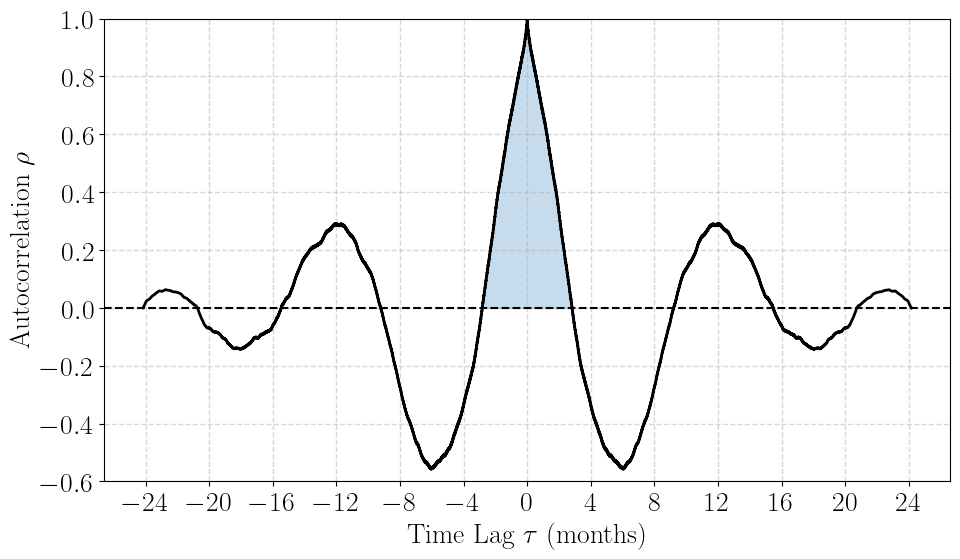

In [10]:
# Create figure
fig,ax = plt.subplots(figsize=(10,6))

# Plot the sst meridional record
ax.plot(t_lag_m[::5], coef[::5], ls='-', lw=2, marker = '', color='k')
ax.axhline(0,ls='--',lw=1.5,color='k')

# Shade region between first neg and first pos zero crossings
ax.fill_between(t[mask], y[mask], 0,
                color='tab:blue', alpha=0.25, zorder=0)

# Annotation pointing into the shaded region
# ax.annotate(f'Decorrelation scale $T$\n({Lt_mons:.1f} months)',
#             xy=(0, 1/2),      # point halfway into shaded region
#             xycoords='data',
#             xytext=(30, 30),          # offset of text
#             textcoords='offset points',
#             ha='left', color='k',
#             arrowprops=dict(arrowstyle="->", color='tab:red', lw=2))

# Set axis attributes
ax.set_xlabel(r'Time Lag $\tau$ (months)' )
ax.set_ylabel(r'Autocorrelation $\rho$')
ax.set_xticks(np.arange(-24,24+4,4))
ax.set_ylim(-0.6,1)
ax.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

# Save figure in high resolution 
figName = 'fig02_osm.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Plot **monthly mean climatology** as a function of depth for potential density, along-shelf velocity, and cross-shelf velocity along side the **time-averaged mean climatological profile** and the **time-averaged sub-month variance** to illustrate the characteristics of the **background field** 

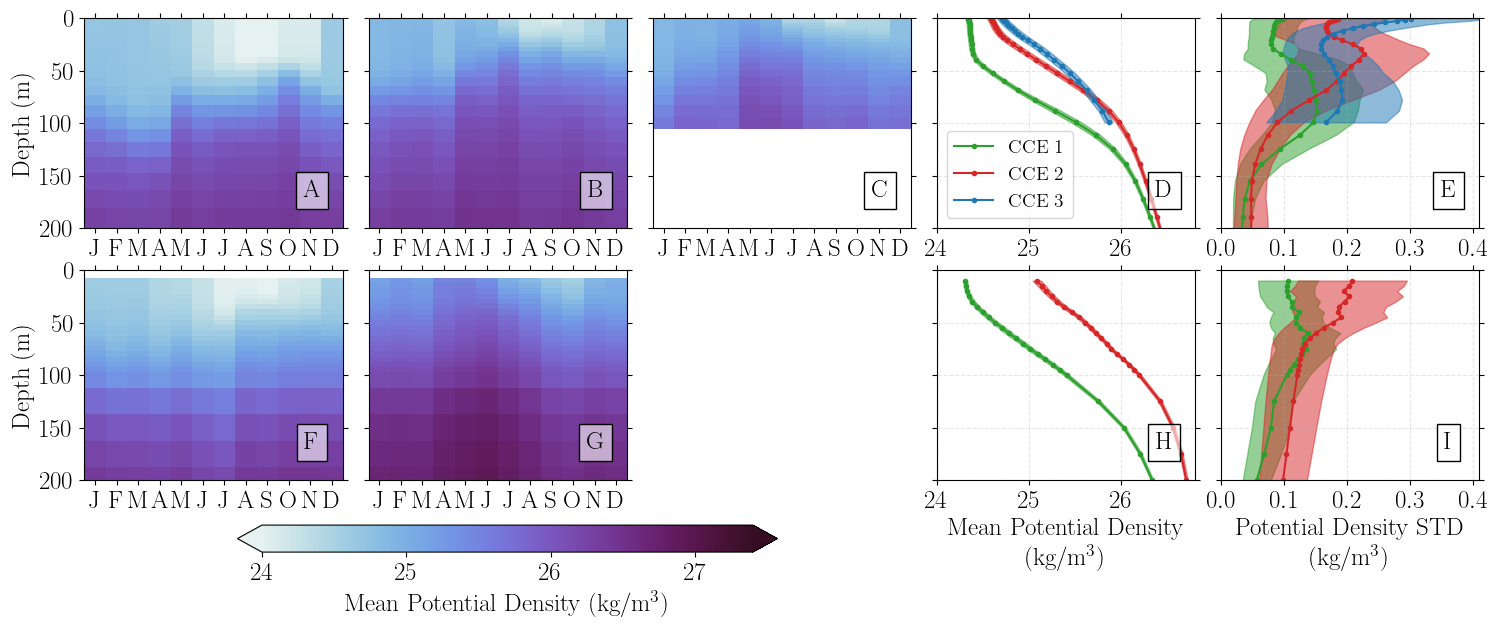

In [11]:
# Set plotting parameters
time_months = np.arange(1,13,1)
time_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
cmap_rho = cmocean.cm.dense
cmap_u   = cmocean.cm.balance
vmin_rho, vmax_rho = 24, 27.4
vmin_u, vmax_u = -0.4, 0.4
vmin_v, vmax_v = -0.25, 0.25
fontsize = 12

# Set global fontsize
fontsize = 18
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Set the frequency and depth grid for the model and observations
D_m, T_m = np.meshgrid(depth_m, time_months)
D, T = np.meshgrid(depth1, time_months)
D_vel, T_vel = np.meshgrid(depth1_adcp, time_months)

# Create figure
fig, axes = plt.subplots(2,5,figsize=(18, 6))
ax_flat = axes.flatten()

################################
#--- Subplot 1 ---#  
################################
ax = ax_flat[0]

# Plot depth averaged potential density climatology for CCE1
pc = ax.pcolormesh(T_m,D_m,meanRho_clim_m[0,:,:],cmap=cmap_rho,shading='auto',vmin=vmin_rho, vmax=vmax_rho)


# Set axis attributes
ax.set_ylabel(r'Depth (m)')
ax.set_xlim(0.5,12.5)
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_xticks(time_months)
ax.set_xticklabels(time_labels)
ax.invert_yaxis() 
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)

################################
#--- Subplot 2 ---#  
################################
ax = ax_flat[1]

# Plot depth averaged potential density climatology for CCE2
pc = ax.pcolormesh(T_m,D_m,meanRho_clim_m[1,:,:],cmap=cmap_rho,shading='auto',vmin=vmin_rho, vmax=vmax_rho)

# Set axis attributes
ax.set_xlim(0.5,12.5)
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_xticks(time_months)
ax.set_xticklabels(time_labels)
ax.set_yticklabels([])
ax.invert_yaxis() 
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)

################################
#--- Subplot 3 ---#  
################################
ax = ax_flat[2]

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax.pcolormesh(T_m,D_m,meanRho_clim_m[2,:,:],cmap=cmap_rho,shading='auto',vmin=vmin_rho, vmax=vmax_rho)

# Set axis attributes
ax.set_xlim(0.5,12.5)
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_xticks(time_months)
ax.set_xticklabels(time_labels)
ax.set_yticklabels([])
ax.invert_yaxis() 
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)

################################
#--- Subplot 4 ---#  
################################
ax = ax_flat[3]

# Plot mean profiles for each mooring
ax.plot(meanRho_clim_prof_m[0,:],abs(depth_m),'.-',color='tab:green',label='CCE 1')
ax.plot(meanRho_clim_prof_m[1,:],abs(depth_m),'.-',color='tab:red',label='CCE 2')
ax.plot(meanRho_clim_prof_m[2,:],abs(depth_m),'.-',color='tab:blue',label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth_m), meanRho_clim_prof_m[0,:] - stdmRho_clim_prof_m[0,:], meanRho_clim_prof_m[0,:] + stdmRho_clim_prof_m[0,:], color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth_m), meanRho_clim_prof_m[1,:] - stdmRho_clim_prof_m[1,:], meanRho_clim_prof_m[1,:] + stdmRho_clim_prof_m[1,:], color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth_m), meanRho_clim_prof_m[2,:] - stdmRho_clim_prof_m[2,:], meanRho_clim_prof_m[2,:] + stdmRho_clim_prof_m[2,:], color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_yticklabels([])
ax.set_xlim(24,26.8)
ax.set_ylim(0,200)
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
        direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.legend(fontsize=14)

################################
#--- Subplot 5 ---#  
################################
ax = ax_flat[4]

# Plot mean profiles for each mooring
ax.plot(np.sqrt(varRho_clim_prof_m[0,:]),abs(depth_m),'.-',color='tab:green',label='CCE 1')
ax.plot(np.sqrt(varRho_clim_prof_m[1,:]),abs(depth_m),'.-',color='tab:red',label='CCE 2')
ax.plot(np.sqrt(varRho_clim_prof_m[2,:]),abs(depth_m),'.-',color='tab:blue',label='CCE 3')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth_m), np.sqrt(varRho_clim_prof_m[0,:]) - np.sqrt(stdvRho_clim_prof_m[0,:]), np.sqrt(varRho_clim_prof_m[0,:]) + np.sqrt(stdvRho_clim_prof_m[0,:]), color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth_m), np.sqrt(varRho_clim_prof_m[1,:]) - np.sqrt(stdvRho_clim_prof_m[1,:]), np.sqrt(varRho_clim_prof_m[1,:]) + np.sqrt(stdvRho_clim_prof_m[1,:]), color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth_m), np.sqrt(varRho_clim_prof_m[2,:]) - np.sqrt(stdvRho_clim_prof_m[2,:]), np.sqrt(varRho_clim_prof_m[2,:]) + np.sqrt(stdvRho_clim_prof_m[2,:]), color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_xlim(0,0.41)
ax.set_ylim(0,200)
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4])
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
        direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

################################
#--- Subplot 6 ---#  
################################
ax = ax_flat[5]

# Plot depth averaged potential density climatology for CCE1
pc = ax.pcolormesh(T,D,meanRho1_clim,cmap=cmap_rho,shading='auto',vmin=vmin_rho, vmax=vmax_rho)

# Set axis attributes
ax.set_ylabel(r'Depth (m)')
ax.set_xlim(0.5,12.5)
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_xticks(time_months)
ax.set_xticklabels(time_labels)
ax.invert_yaxis() 
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)

################################
#--- Subplot 7 ---#  
################################
ax = ax_flat[6]

# Plot depth averaged potential density climatology for CCE1
pc = ax.pcolormesh(T,D,meanRho2_clim,cmap=cmap_rho,shading='auto',vmin=vmin_rho, vmax=vmax_rho)

# Set axis attributes
ax.set_xlim(0.5,12.5)
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_xticks(time_months)
ax.set_xticklabels(time_labels)
ax.set_yticklabels([])
ax.invert_yaxis() 
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)

################################
#--- Subplot 8 ---#  
################################
ax_flat[7].axis('off')

################################
#--- Subplot 9 ---#  
################################
ax = ax_flat[8]

# Plot mean profiles for each mooring
ax.plot(meanRho1_clim_prof,abs(depth1),'.-',color='tab:green',label='CCE 1')
ax.plot(meanRho2_clim_prof,abs(depth2),'.-',color='tab:red',label='CCE 2')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth1), meanRho1_clim_prof - stdmRho1_clim_prof, meanRho1_clim_prof + stdmRho1_clim_prof, color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth2), meanRho2_clim_prof - stdmRho2_clim_prof, meanRho2_clim_prof + stdmRho2_clim_prof, color='tab:red', alpha=0.5)

# Set axis attributes
ax.set_xlabel(f'Mean Potential Density \n(kg/m$^3$)')
ax.set_yticklabels([])
ax.set_xlim(24,26.8)
ax.set_ylim(0,200)
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
        direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

################################
#--- Subplot 10 ---#  
################################
ax = ax_flat[9]

# Plot mean profiles for each mooring
ax.plot(np.sqrt(varRho1_clim_prof),abs(depth1),'.-',color='tab:green',label='CCE 1')
ax.plot(np.sqrt(varRho2_clim_prof),abs(depth2),'.-',color='tab:red',label='CCE 2')

# Plot standard error of the mean profiles for each mooring
ax.fill_betweenx(abs(depth1), np.sqrt(varRho1_clim_prof) - np.sqrt(stdvRho1_clim_prof), np.sqrt(varRho1_clim_prof) + np.sqrt(stdvRho1_clim_prof), color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth2), np.sqrt(varRho2_clim_prof) - np.sqrt(stdvRho2_clim_prof), np.sqrt(varRho2_clim_prof) + np.sqrt(stdvRho2_clim_prof), color='tab:red', alpha=0.5)

# Set axis attributes
ax.set_xlabel(f'Potential Density STD \n(kg/m$^3$)')
ax.set_xlim(0,0.41)
ax.set_ylim(0,200)
ax.set_xticks([0, 0.1, 0.2, 0.3, 0.4])
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
        direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

# Set color bar
cax = fig.add_axes([0.21, -0.01, 0.3, 0.045])  # [left, bottom, width, height]
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'Mean Potential Density (kg/m$^3$)')

# Label each subplot
pos = [0.88, 0.18]
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10 = axes.flatten()
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)
add_corner_label(ax7, pos, 'G', fontsize = fontsize)
add_corner_label(ax9, pos, 'H', fontsize = fontsize)
add_corner_label(ax10, pos, 'I', fontsize = fontsize)

# Display figure
plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.show()

# Save with high quality
figName = 'fig02_proposal.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Plot the annually-averaged spectragrams, the depth profiles of the model and observed decorrelation scales along side the **variance of anomalies** from the mean climatological background. 

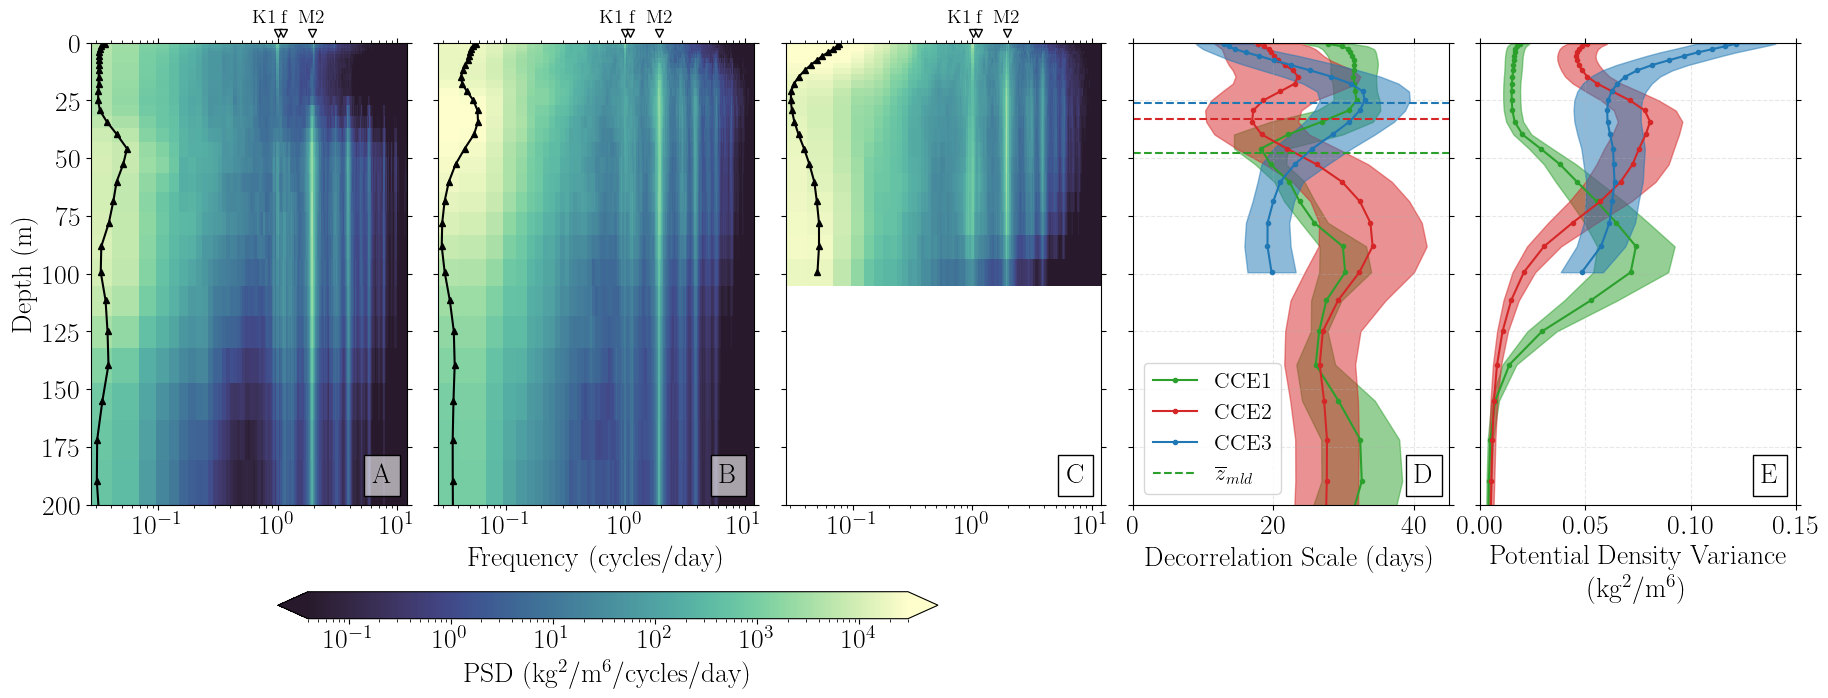

In [10]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=4e-2, vmax=3e4)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,5,figsize=(22, 6))
ax1, ax2, ax3, ax4, ax5 = axes.flatten()

#--- Subplot 1 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax1.pcolormesh(F_m,D_m,S_Rho_m[0,:,:],cmap=cmap,shading='auto',norm=norm)
ax1.plot(fd1_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set figure attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax1.set_ylim(depth_lim[0],depth_lim[1])
ax1.invert_yaxis() 
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)

#--- Subplot 2 ---#  

# Plot CCE2 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax2.pcolormesh(F_m,D_m,S_Rho_m[1,:,:],cmap=cmap,shading='auto',norm=norm)
ax2.plot(fd2_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_yticklabels([])
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

pc = ax3.pcolormesh(F_m,D_m,S_Rho_m[2,:,:],cmap=cmap,shading='auto',norm=norm)
ax3.plot(fd3_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set figure attributes
ax3.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax3.set_ylim(depth_lim[0],depth_lim[1])
ax3.invert_yaxis() 
ax3.set_yticklabels([])
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

#--- Subplot 4 ---# 

# Plot potential density decor scales
ax4.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green',label='CCE1')
ax4.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red',label='CCE2')
ax4.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax4.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)
ax4.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)
ax4.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
ax4.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
ax4.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)
ax4.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# # Plot the range of mixed layer depths (1 standard deviation)
# ax4.fill_between([0, 45], mld_mean_m[0] - mld_std_mean_m[0], mld_mean_m[0] + mld_std_mean_m[0], color='tab:green', alpha=0.3)
# ax4.fill_between([0, 45], mld_mean_m[1] - mld_std_mean_m[1], mld_mean_m[1] + mld_std_mean_m[1], color='tab:red', alpha=0.3)
# ax4.fill_between([0, 45], mld_mean_m[2] - mld_std_mean_m[2], mld_mean_m[2] + mld_std_mean_m[2], color='tab:blue', alpha=0.3)

# Set axis attributes
ax4.set_xlabel(r'Decorrelation Scale (days)')
ax4.set_xlim(0,45)
#ax4.set_ylim(0,20)
ax4.set_ylim(depth_lim[0], depth_lim[1])
ax4.invert_yaxis()
ax4.legend(fontsize=16)
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelleft=False,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 

# Plot variance anomaly  profiles for each mooring
ax5.plot(var_anom_Rho_m[0,:],abs(depth_upper_m),'.-',color='tab:green',label='CCE 1')
ax5.plot(var_anom_Rho_m[1,:],abs(depth_upper_m),'.-',color='tab:red',label='CCE 2')
ax5.plot(var_anom_Rho_m[2,:],abs(depth_upper_m),'.-',color='tab:blue',label='CCE 3')

# Plot standard error of the variance profiles for each mooring
ax5.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[0,:] - var_anom_Rho_stdv_m[0,:], var_anom_Rho_m[0,:] + var_anom_Rho_stdv_m[0,:], color='tab:green', alpha=0.5)
ax5.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[1,:] - var_anom_Rho_stdv_m[1,:], var_anom_Rho_m[1,:] + var_anom_Rho_stdv_m[1,:], color='tab:red', alpha=0.5)
ax5.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[2,:] - var_anom_Rho_stdv_m[2,:], var_anom_Rho_m[2,:] + var_anom_Rho_stdv_m[2,:], color='tab:blue', alpha=0.5)

# Set axis attributes
ax5.set_xlabel(f'Potential Density Variance \n(kg$^2$/m$^6$)')
ax5.set_yticklabels([])
ax5.set_xlim(0,0.15)
ax5.set_ylim(0,200)
ax5.invert_yaxis()
ax5.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax5.grid(True,linestyle='--',alpha=0.3)

# Set color bar
cax = fig.add_axes([0.21, -0.08, 0.3, 0.045]) 
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Label each subplot
pos = [0.89, 0.09]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)

# Plot the tidal and inertial frequencies
for ax in (ax1, ax2, ax3):
    
    # K1 label shifted slightly left
    add_freq_marker(ax, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

    # f label shifted slightly right
    add_freq_marker(ax, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

    # M2 centered
    add_freq_marker(ax, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
figName = 'fig06_proposal.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

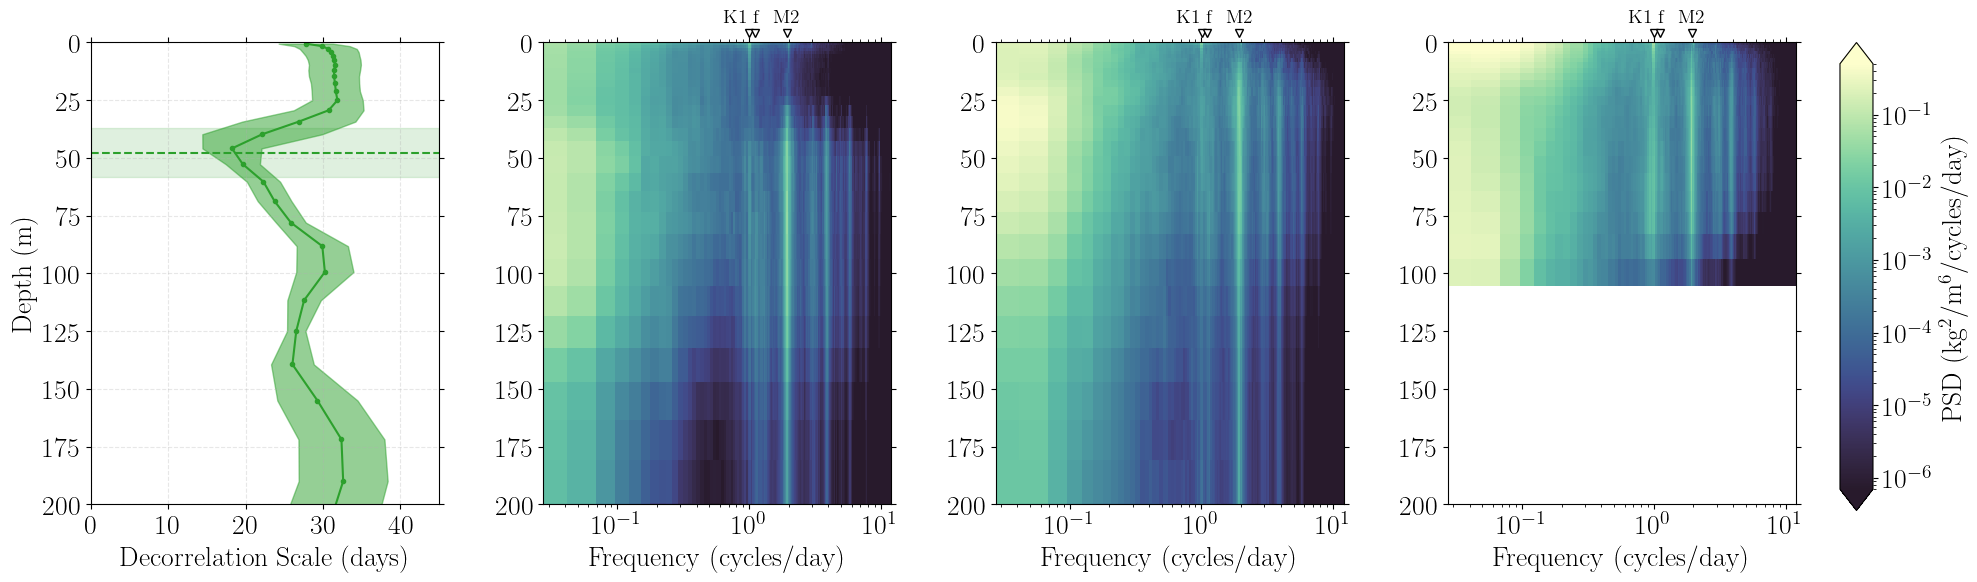

In [ ]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=5e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,4,figsize=(22, 6))
ax1, ax2, ax3, ax4 = axes.flatten()

#--- Subplot 1 ---# 

# Plot potential density decor scales
ax1.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green')
# ax1.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red')
# ax1.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue')

# Plot standard error of the mean
ax1.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)
# ax1.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)
# ax1.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
ax1.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
# ax1.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)
# ax1.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax1.fill_between([0, 45], mld_mean_m[0] - mld_std_mean_m[0], mld_mean_m[0] + mld_std_mean_m[0], color='tab:green', alpha=0.15)
# ax1.fill_between([0, 45], mld_mean_m[1] - mld_std_mean_m[1], mld_mean_m[1] + mld_std_mean_m[1], color='tab:red', alpha=0.15)
# ax1.fill_between([0, 45], mld_mean_m[2] - mld_std_mean_m[2], mld_mean_m[2] + mld_std_mean_m[2], color='tab:blue', alpha=0.15)

# Set axis attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0,45)
#ax1.set_ylim(0,20)
ax1.set_ylim(depth_lim[0], depth_lim[1])
ax1.set_xticks([0, 10, 20, 30, 40])
ax1.invert_yaxis()
#ax1.legend(fontsize=16)
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

# # Plot variance anomaly  profiles for each mooring
# ax1.plot(var_anom_Rho_m[0,:],abs(depth_upper_m),'.-',color='tab:green',label='CCE 1')
# ax1.plot(var_anom_Rho_m[1,:],abs(depth_upper_m),'.-',color='tab:red',label='CCE 2')
# ax1.plot(var_anom_Rho_m[2,:],abs(depth_upper_m),'.-',color='tab:blue',label='CCE 3')

# # Plot standard error of the variance profiles for each mooring
# ax1.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[0,:] - var_anom_Rho_stdv_m[0,:], var_anom_Rho_m[0,:] + var_anom_Rho_stdv_m[0,:], color='tab:green', alpha=0.5)
# ax1.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[1,:] - var_anom_Rho_stdv_m[1,:], var_anom_Rho_m[1,:] + var_anom_Rho_stdv_m[1,:], color='tab:red', alpha=0.5)
# ax1.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[2,:] - var_anom_Rho_stdv_m[2,:], var_anom_Rho_m[2,:] + var_anom_Rho_stdv_m[2,:], color='tab:blue', alpha=0.5)

# # Set axis attributes
# ax1.set_ylabel('Depth (m)')
# ax1.set_xlabel(f'Potential Density Variance \n(kg$^2$/m$^6$)')
# ax1.set_xlim(0,0.15)
# ax1.set_ylim(0,200)
# ax1.invert_yaxis()
# ax1.tick_params(top=True, bottom=True, left=True, right=True,
#             direction='out', length=3.5)
# ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax2.pcolormesh(F_m,D_m,S_Rho_m[0,:,:],cmap=cmap,shading='auto',norm=norm)
#ax2.plot(fd1_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE2 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax3.pcolormesh(F_m,D_m,S_Rho_m[1,:,:],cmap=cmap,shading='auto',norm=norm)
#ax3.plot(fd2_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set figure attributes
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax3.set_ylim(depth_lim[0],depth_lim[1])
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

pc = ax4.pcolormesh(F_m,D_m,S_Rho_m[2,:,:],cmap=cmap,shading='auto',norm=norm)
#ax4.plot(fd3_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set figure attributes
ax4.set_xlabel('Frequency (cycles/day)')
ax4.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax4.set_ylim(depth_lim[0],depth_lim[1])
ax4.invert_yaxis() 
ax4.set_xscale('log')
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax4.tick_params(which='major', length=3.5)
ax4.tick_params(which='minor', length=2.5)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Plot the tidal and inertial frequencies
for ax in (ax2, ax3, ax4):
    
    # K1 label shifted slightly left
    add_freq_marker(ax, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

    # f label shifted slightly right
    add_freq_marker(ax, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

    # M2 centered
    add_freq_marker(ax, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.3)
plt.show()

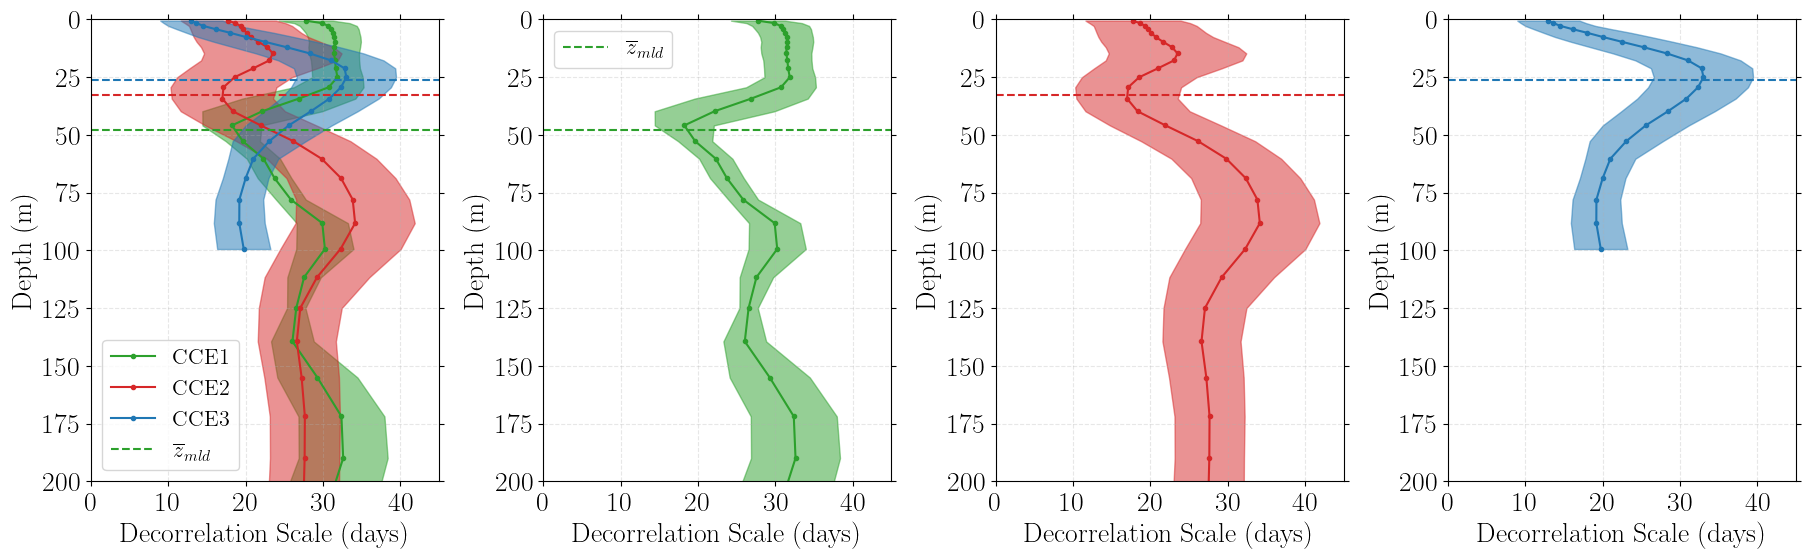

In [50]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=4e-2, vmax=3e4)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,4,figsize=(22, 6))
ax4, ax1, ax2, ax3 = axes.flatten()

#--- Subplot 1 ---# 

# Plot potential density decor scales
ax1.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green')

# Plot standard error of the mean
ax1.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)

# Plot the mean mixed layer depth 
ax1.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")

# Set axis attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0,45)
#ax1.set_ylim(0,20)
ax1.set_ylim(depth_lim[0], depth_lim[1])
ax1.set_xticks([0, 10, 20, 30, 40])
ax1.invert_yaxis()
ax1.legend(fontsize=16)
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot potential density decor scales
ax2.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red',label='CCE2')
# ax1.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax2.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)
# ax1.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
ax2.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)
# ax1.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Set axis attributes
ax2.set_ylabel('Depth (m)')
ax2.set_xlabel(r'Decorrelation Scale (days)')
ax2.set_xlim(0,45)
#ax2.set_ylim(0,20)
ax2.set_ylim(depth_lim[0], depth_lim[1])
ax2.set_xticks([0, 10, 20, 30, 40])
ax2.invert_yaxis()
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---#  

# Plot potential density decor scales
ax3.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax3.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
ax3.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Set axis attributes
ax3.set_ylabel('Depth (m)')
ax3.set_xlabel(r'Decorrelation Scale (days)')
ax3.set_xlim(0,45)
#ax3.set_ylim(0,20)
ax3.set_ylim(depth_lim[0], depth_lim[1])
ax3.set_xticks([0, 10, 20, 30, 40])
ax3.invert_yaxis()
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 

# Plot potential density decor scales
ax4.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green',label='CCE1')
ax4.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red',label='CCE2')
ax4.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax4.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)
ax4.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)
ax4.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
ax4.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
ax4.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)
ax4.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Set axis attributes
ax4.set_ylabel('Depth (m)')
ax4.set_xlabel(r'Decorrelation Scale (days)')
ax4.set_xlim(0,45)
#ax4.set_ylim(0,20)
ax4.set_ylim(depth_lim[0], depth_lim[1])
ax4.set_xticks([0, 10, 20, 30, 40])
ax4.invert_yaxis()
ax4.legend(fontsize=16)
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.3)
plt.show()


In [11]:
print(depth_upper_m[np.argmin(Lt1_rho_m)])
print(depth_upper_m[np.argmin(Lt2_rho_m)])
print(depth_upper_m[np.argmin(Lt3_rho_m)])
print('   ')

print(np.min(Lt1_rho_m))
print(np.min(Lt2_rho_m))
print(np.min(Lt3_rho_m))
print('   ')

print(Lt1_rho_m_stdm[np.argmin(Lt1_rho_m)])
print(Lt2_rho_m_stdm[np.argmin(Lt2_rho_m)])
print(Lt3_rho_m_stdm[np.argmin(Lt3_rho_m)])
print('   ')

print(np.max(Lt3_rho_m))
print(Lt3_rho_m_stdm[np.argmax(Lt3_rho_m)])


45.855
34.24
0.5
   
18.233908143317898
16.989556395469716
12.978720468686838
   
3.8198892944577154
6.552533757190583
4.01821354859264
   
33.02963371128911
6.4198925933692035


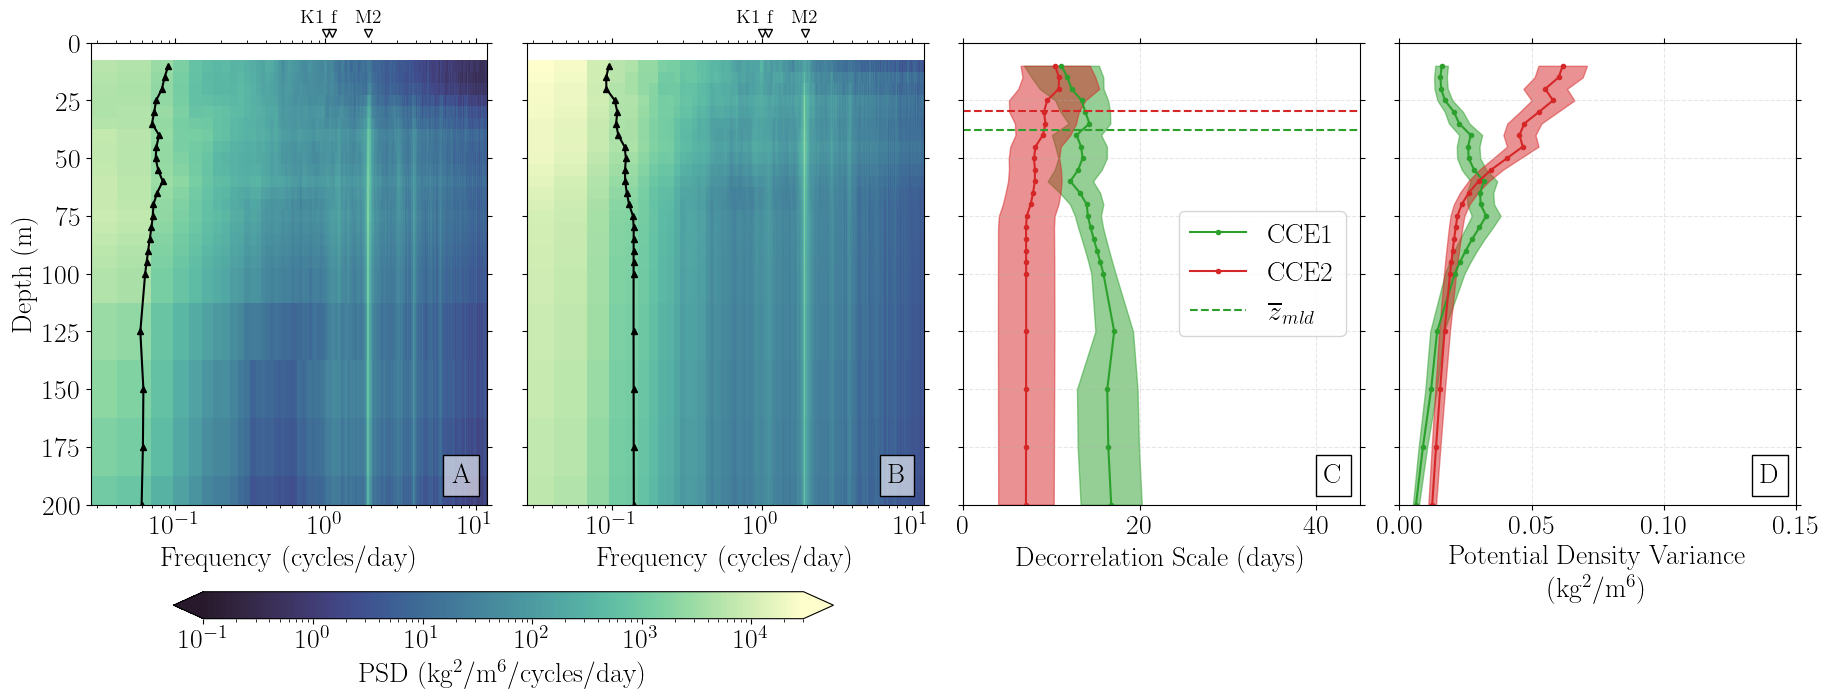

In [12]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=1e-1, vmax=3e4)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,4,figsize=(22, 6))
ax1, ax2, ax3, ax4 = axes.flatten()

#--- Subplot 1 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax1.pcolormesh(F,D,S1_rho,cmap=cmap,shading='auto', norm=norm)
ax1.plot(fd1_rho, depth1, 'k^-', markersize=4)

# Set figure attributes
ax1.set_xlabel('Frequency (cycles/day)')
ax1.set_ylabel('Depth (m)')
ax1.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax1.set_ylim(depth_lim[0],depth_lim[1])
ax1.invert_yaxis() 
ax1.set_xscale('log')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax1.tick_params(which='major', length=3.5)
ax1.tick_params(which='minor', length=2.5)

#--- Subplot 2 ---#  

# Plot CCE2 potential density spectrogram overlayed with decorrelation frequency markers
ax2.pcolormesh(F,D,S2_rho,cmap=cmap,shading='auto',norm=norm)
ax2.plot(fd2_rho, depth1, 'k^-', markersize=4)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_yticklabels([])
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot potential density decor scales
ax3.plot(Lt1_rho,depth1,'.-', color='tab:green',label='CCE1')
ax3.plot(Lt2_rho,depth2,'.-', color='tab:red',label='CCE2')

# Plot standard error of the mean
ax3.fill_betweenx(depth1, Lt1_rho - Lt1_rho_stdm, Lt1_rho + Lt1_rho_stdm, color='tab:green', alpha=0.5)
ax3.fill_betweenx(depth2, Lt2_rho - Lt2_rho_stdm, Lt2_rho + Lt2_rho_stdm, color='tab:red', alpha=0.5)

# Plot the mean mixed layer depth 
ax3.axhline(mld1_mean, ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
ax3.axhline(mld2_mean, ls='--', lw=1.5, color='tab:red', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
# ax3.fill_between([0, 45], mld1_mean - mld1_std_mean, mld1_mean + mld1_std_mean, color='tab:green', alpha=0.3)
# ax3.fill_between([0, 45], mld2_mean - mld2_std_mean, mld1_mean + mld2_std_mean, color='tab:green', alpha=0.3)

# Set axis attributes
ax3.set_xlabel(r'Decorrelation Scale (days)')
ax3.set_xlim(0,45)
ax3.set_ylim(depth_lim[0], depth_lim[1])
ax3.invert_yaxis()
ax3.legend()
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelleft=False,
         direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 

# Plot variance anomaly  profiles for each mooring
ax4.plot(var_anom_Rho1,abs(depth1),'.-',color='tab:green',label='CCE 1')
ax4.plot(var_anom_Rho2,abs(depth2),'.-',color='tab:red',label='CCE 2')

# Plot standard error of the variance profiles for each mooring
ax4.fill_betweenx(abs(depth1), var_anom_Rho1 - var_anom_Rho1_stdv, var_anom_Rho1 + var_anom_Rho1_stdv, color='tab:green', alpha=0.5)
ax4.fill_betweenx(abs(depth2), var_anom_Rho2 - var_anom_Rho2_stdv, var_anom_Rho2 + var_anom_Rho2_stdv, color='tab:red', alpha=0.5)

# Set axis attributes
ax4.set_xlabel(f'Potential Density Variance \n(kg$^2$/m$^6$)')
ax4.set_yticklabels([])
ax4.set_xlim(0,0.15)
ax4.set_ylim(0,200)
ax4.set_xticks([0, 0.05, 0.1, 0.15])
ax4.invert_yaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

# Set color bar
cax = fig.add_axes([0.1625, -0.08, 0.3, 0.045]) 
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Label each subplot
pos = [0.91, 0.09]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)

# Plot the tidal and inertial frequencies
for ax in (ax1, ax2):
    
    # K1 label shifted slightly left
    add_freq_marker(ax, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

    # f label shifted slightly right
    add_freq_marker(ax, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

    # M2 centered
    add_freq_marker(ax, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
figName = 'fig07_proposal.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

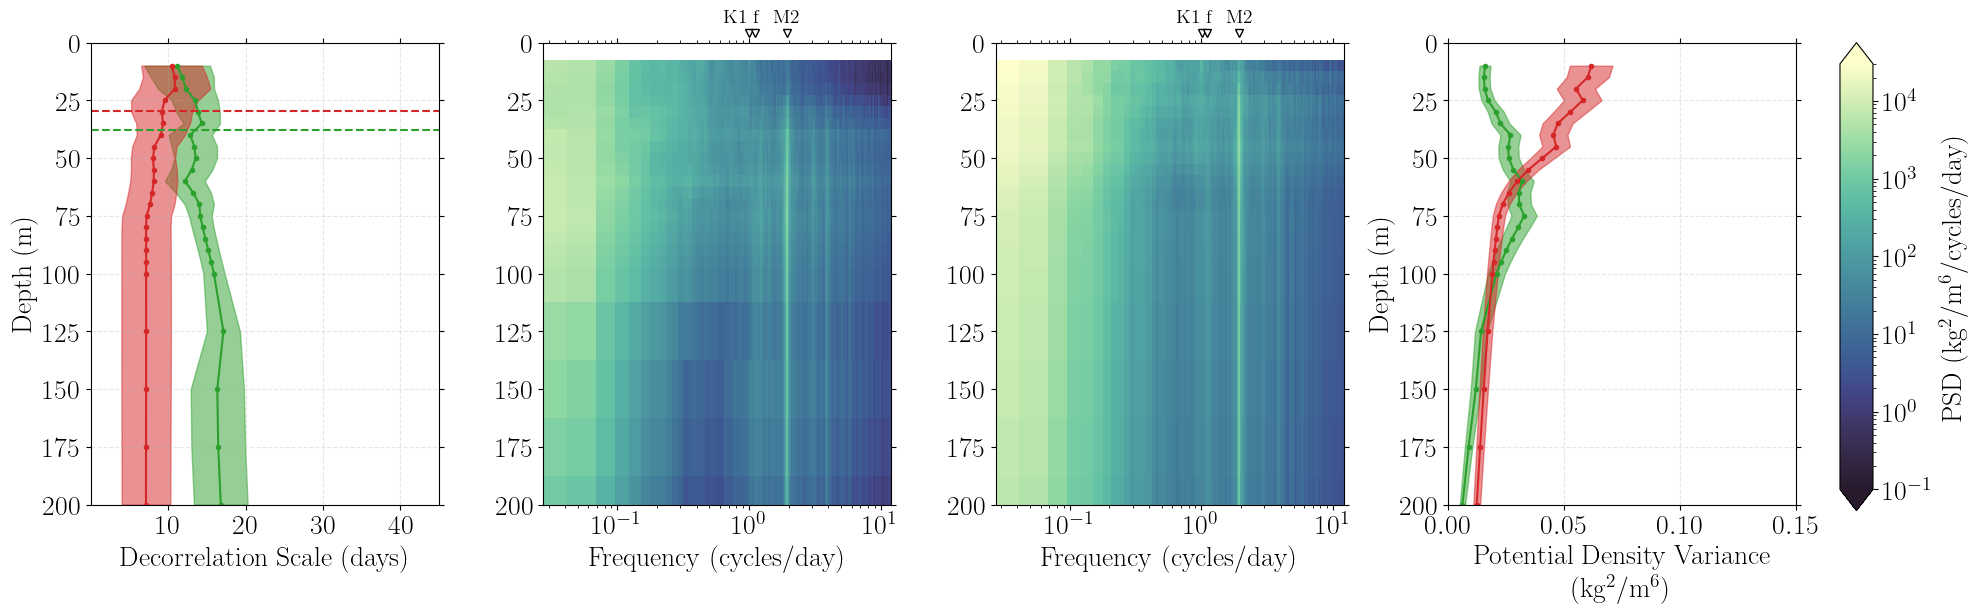

In [93]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=1e-1, vmax=3e4)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,4,figsize=(22, 6))
ax1, ax2, ax3, ax4 = axes.flatten()

#--- Subplot 1 ---#  

# Plot potential density decor scales
ax1.plot(Lt1_rho,depth1,'.-', color='tab:green')
ax1.plot(Lt2_rho,depth2,'.-', color='tab:red',label='CCE2')

# Plot standard error of the mean
ax1.fill_betweenx(depth1, Lt1_rho - Lt1_rho_stdm, Lt1_rho + Lt1_rho_stdm, color='tab:green', alpha=0.5)
ax1.fill_betweenx(depth2, Lt2_rho - Lt2_rho_stdm, Lt2_rho + Lt2_rho_stdm, color='tab:red', alpha=0.5)

# Plot the mean mixed layer depth 
ax1.axhline(mld1_mean, ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
ax1.axhline(mld2_mean, ls='--', lw=1.5, color='tab:red', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
# ax1.fill_between([0, 45], mld1_mean - mld1_std_mean, mld1_mean + mld1_std_mean, color='tab:green', alpha=0.3)
# ax1.fill_between([0, 45], mld2_mean - mld2_std_mean, mld1_mean + mld2_std_mean, color='tab:green', alpha=0.3)

# Set axis attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
ax1.set_xticks([10, 20, 30, 40])
ax1.invert_yaxis()
#ax1.legend()
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
         direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax2.pcolormesh(F,D,S1_rho,cmap=cmap,shading='auto', norm=norm)
#ax2.plot(fd1_rho, depth1, 'k^-', markersize=4)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax3.pcolormesh(F,D,S2_rho,cmap=cmap,shading='auto', norm=norm)
#ax3.plot(fd2_rho, depth2, 'k^-', markersize=4)

# Set figure attributes
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax3.set_ylim(depth_lim[0],depth_lim[1])
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

#--- Subplot 4 ---# 

# Plot variance anomaly  profiles for each mooring
ax4.plot(var_anom_Rho1,abs(depth1),'.-',color='tab:green',label='CCE 1')
ax4.plot(var_anom_Rho2,abs(depth2),'.-',color='tab:red',label='CCE 2')

# Plot standard error of the variance profiles for each mooring
ax4.fill_betweenx(abs(depth1), var_anom_Rho1 - var_anom_Rho1_stdv, var_anom_Rho1 + var_anom_Rho1_stdv, color='tab:green', alpha=0.5)
ax4.fill_betweenx(abs(depth2), var_anom_Rho2 - var_anom_Rho2_stdv, var_anom_Rho2 + var_anom_Rho2_stdv, color='tab:red', alpha=0.5)

# Set axis attributes
ax4.set_ylabel('Depth (m)')
ax4.set_xlabel(f'Potential Density Variance \n(kg$^2$/m$^6$)')
ax4.set_xlim(0,0.15)
ax4.set_ylim(0,200)
ax4.set_xticks([0, 0.05, 0.1, 0.15])
ax4.invert_yaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Plot the tidal and inertial frequencies
for ax in (ax2, ax3):
    
    # K1 label shifted slightly left
    add_freq_marker(ax, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

    # f label shifted slightly right
    add_freq_marker(ax, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

    # M2 centered
    add_freq_marker(ax, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.3)
plt.show()


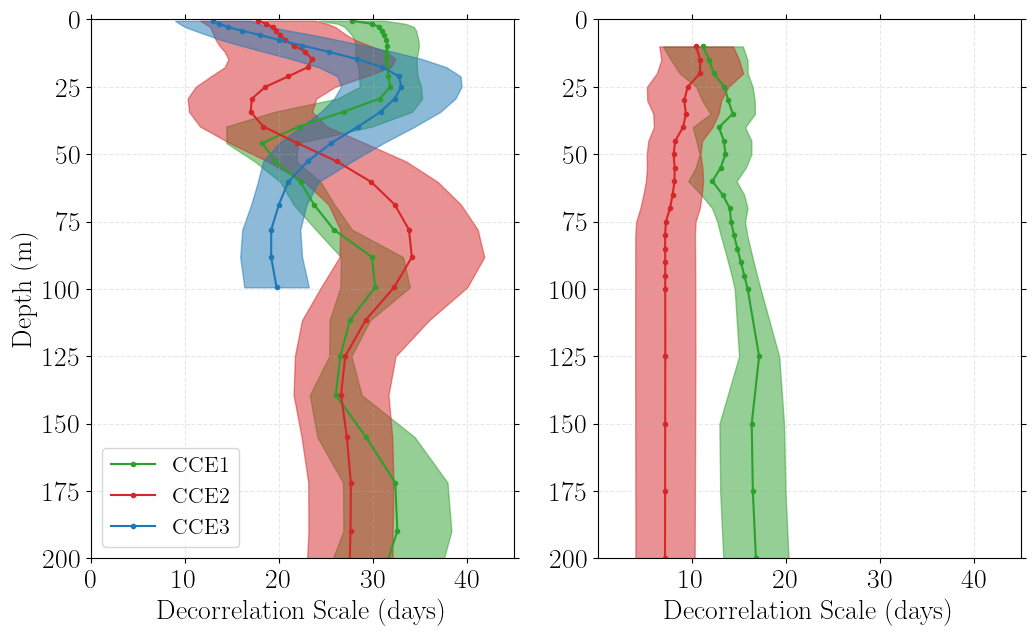

In [43]:
# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,2,figsize=(12, 7))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---#  

# Plot potential density decor scales
ax1.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green',label='CCE1')
ax1.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red',label='CCE2')
ax1.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax1.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)
ax1.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)
ax1.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
# ax1.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
# ax1.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)
# ax1.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Set axis attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0,45)
#ax1.set_ylim(0,20)
ax1.set_ylim(depth_lim[0], depth_lim[1])
ax1.set_xticks([0, 10, 20, 30, 40])
ax1.invert_yaxis()
ax1.legend(fontsize=16)
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot potential density decor scales
ax2.plot(Lt1_rho,depth1,'.-', color='tab:green')
ax2.plot(Lt2_rho,depth2,'.-', color='tab:red',label='CCE2')

# Plot standard error of the mean
ax2.fill_betweenx(depth1, Lt1_rho - Lt1_rho_stdm, Lt1_rho + Lt1_rho_stdm, color='tab:green', alpha=0.5)
ax2.fill_betweenx(depth2, Lt2_rho - Lt2_rho_stdm, Lt2_rho + Lt2_rho_stdm, color='tab:red', alpha=0.5)

# Plot the mean mixed layer depth 
# ax2.axhline(mld1_mean, ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
# ax2.axhline(mld2_mean, ls='--', lw=1.5, color='tab:red', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
# ax1.fill_between([0, 45], mld1_mean - mld1_std_mean, mld1_mean + mld1_std_mean, color='tab:green', alpha=0.3)
# ax1.fill_between([0, 45], mld2_mean - mld2_std_mean, mld1_mean + mld2_std_mean, color='tab:green', alpha=0.3)

# Set axis attributes
ax2.set_xlabel(r'Decorrelation Scale (days)')
ax2.set_xlim(0,45)
ax2.set_ylim(depth_lim[0], depth_lim[1])
ax2.set_xticks([10, 20, 30, 40])
ax2.invert_yaxis()
#ax2.legend()
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
         direction='out', length=3.5)
ax2.grid(True,linestyle='--',alpha=0.3)

# Save with high quality
figName = 'figS04.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


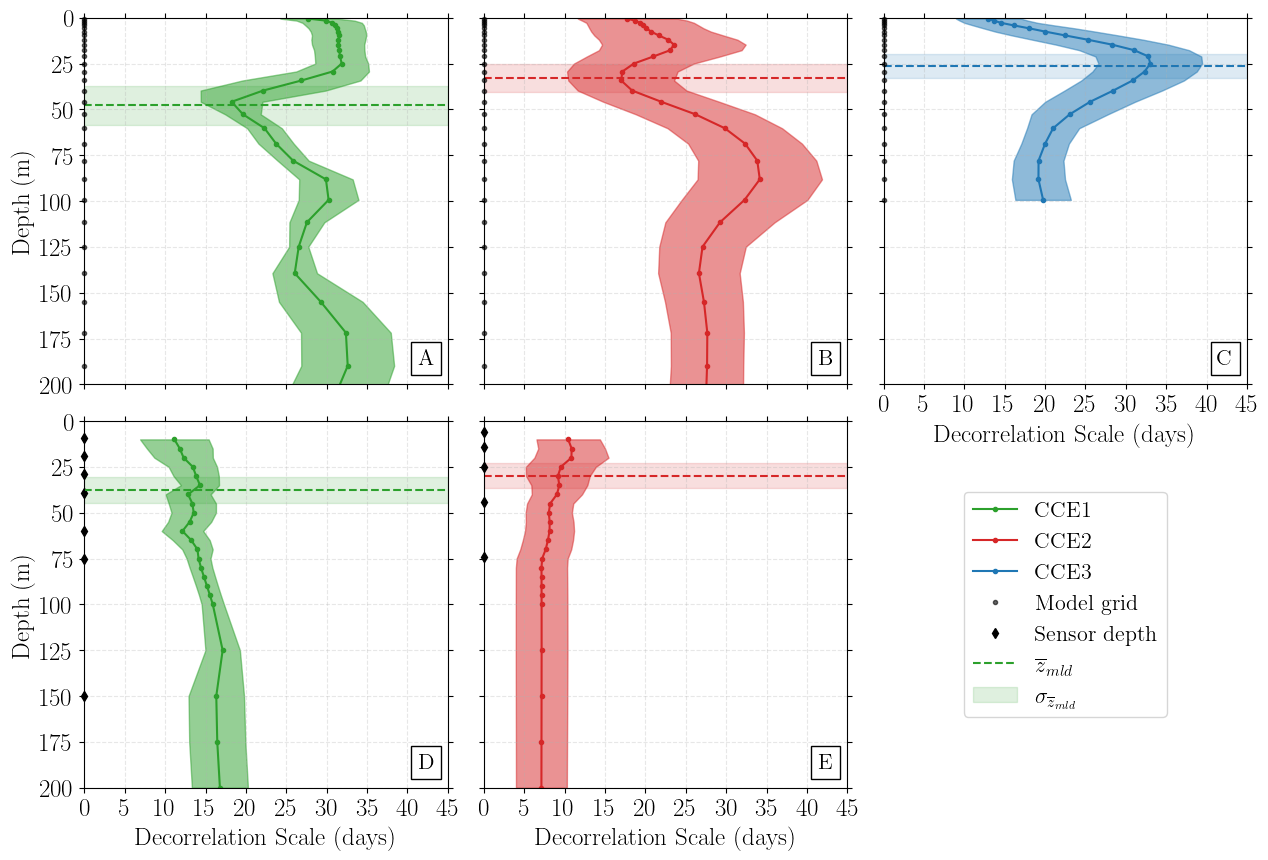

In [ ]:
# Set global fontsize
fontsize = 18
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Set plotting parameters 
cce1_sensor_depth = np.array([9, 19, 29, 39, 60, 75, 150])
cce2_sensor_depth = np.array([6, 14, 25, 44, 74])
depth_cce3 = depth_upper_m[depth_upper_m <= 100]

# Create figure
fig, axes = plt.subplots(2,3,figsize=(15, 10))
ax_flat = axes.flatten()

#--- Subplot 1 ---# 
ax = ax_flat[0]

# Plot CCE1 potential density decor scale
ax.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green', label='CCE1')

# Plot standard error of the mean
ax.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)

# Plot the mean mixed layer depth 
ax.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax.fill_between([0, 45], mld_mean_m[0] - mld_std_mean_m[0], mld_mean_m[0] + mld_std_mean_m[0], color='tab:green', alpha=0.15)

# Set left edge x-position
x_right = ax.get_xlim()[0] + 2.2  

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,45)
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_xticks(np.arange(0,45+5,5))
ax.set_yticks(np.arange(0,200+25,25))
ax.set_xticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  
ax = ax_flat[1]

# Plot potential density decor scales
ax.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red', label='CCE2')

# Plot standard error of the mean
ax.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)

# Plot the mean mixed layer depth 
ax.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax.fill_between([0, 45], mld_mean_m[1] - mld_std_mean_m[1], mld_mean_m[1] + mld_std_mean_m[1], color='tab:red', alpha=0.15)

# Set right edge x-position
x_right = ax.get_xlim()[0] + 2.2 

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set axis attributes
ax.set_xlim(0,45)
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_xticks(np.arange(0,45+5,5))
ax.set_yticks(np.arange(0,200+25,25))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---#  
ax = ax_flat[2]

# Plot potential density decor scales
ax.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue', label='CCE3')

# Plot standard error of the mean
ax.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
ax.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax.fill_between([0, 45], mld_mean_m[2] - mld_std_mean_m[2], mld_mean_m[2] + mld_std_mean_m[2], color='tab:blue', alpha=0.15)

# Set right edge x-position
x_right = ax.get_xlim()[0] + 2.25 

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_cce3, x_right),
    depth_cce3,
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False, 
    label='Model grid'
)

# Set axis attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_xlim(0,45)
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_xticks(np.arange(0,45+5,5))
ax.set_yticks(np.arange(0,200+25,25))
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 
ax = ax_flat[3]

# Plot potential density decor scales
ax.plot(Lt1_rho,depth1,'.-', color='tab:green')

# Plot standard error of the mean
ax.fill_betweenx(depth1, Lt1_rho - Lt1_rho_stdm, Lt1_rho + Lt1_rho_stdm, color='tab:green', alpha=0.5)

# Set right edge x-position (slightly inside the axis)
x_right = ax.get_xlim()[0] - 6

# Plot the sensor depths 
ax.plot(
    np.full_like(cce1_sensor_depth, x_right),
    cce1_sensor_depth,
    marker='d', linestyle='None',
    color='k', markersize=5, alpha = 1, clip_on=False,
    label='Sensor depth'  
)

# Plot the mean mixed layer depth 
ax.axhline(mld1_mean, ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")

# Plot the range of mixed layer depths (1 standard deviation)
ax.fill_between([0, 45], mld1_mean - mld1_std_mean, mld1_mean + mld1_std_mean, color='tab:green', alpha=0.15, label=r"$\sigma_{\overline{z}_{mld}}$")

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_xlim(0,45)
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_xticks(np.arange(0,45+5,5))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 
ax = ax_flat[4]

# Plot potential density decor scales
ax.plot(Lt2_rho,depth2,'.-', color='tab:red')

# Plot standard error of the mean
ax.fill_betweenx(depth2, Lt2_rho - Lt2_rho_stdm, Lt2_rho + Lt2_rho_stdm, color='tab:red', alpha=0.5)

# Plot the mean mixed layer depth 
ax.axhline(mld2_mean, ls='--', lw=1.5, color='tab:red', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax.fill_between([0, 45], mld2_mean - mld2_std_mean, mld2_mean + mld2_std_mean, color='tab:red', alpha=0.15)

# Set right edge x-position (slightly inside the axis)
x_right = ax.get_xlim()[0] + 1.5

# Plot the sensor depths 
ax.plot(
    np.full_like(cce2_sensor_depth, x_right),
    cce2_sensor_depth,
    marker='d', linestyle='None',
    color='k', markersize=5, alpha = 1, clip_on=False,
)

# Set axis attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_xlim(0,45)
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_xticks(np.arange(0,45+5,5))
ax.set_yticks(np.arange(0,200+25,25))
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 
ax = ax_flat[5]

# Turn off axis
ax.axis('off')

# Obtain the handle for the legend 
handles = []
labels = []

# Loop through axes that contain legend items
for i in [0,1,2,3]:  
    h, l = ax_flat[i].get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Display legend in the position of the 6th axis
ax.legend(handles, labels, loc='center', fontsize=16)

# Label each subplot
pos = [0.94, 0.07]
add_corner_label(ax_flat[0], pos, 'A', fontsize = 16)
add_corner_label(ax_flat[1], pos, 'B', fontsize = 16)
add_corner_label(ax_flat[2], pos, 'C', fontsize = 16)
add_corner_label(ax_flat[3], pos, 'D', fontsize = 16)
add_corner_label(ax_flat[4], pos, 'E', fontsize = 16)

# Display figure
plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

# Save with high quality
figName = 'fig04.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


Convert Spectra from variance/Hz to variance/cpd

In [25]:
S_Rho_m /= (60 * 60 * 24)
S1_rho  /= (60 * 60 * 24)
S2_rho  /= (60 * 60 * 24)

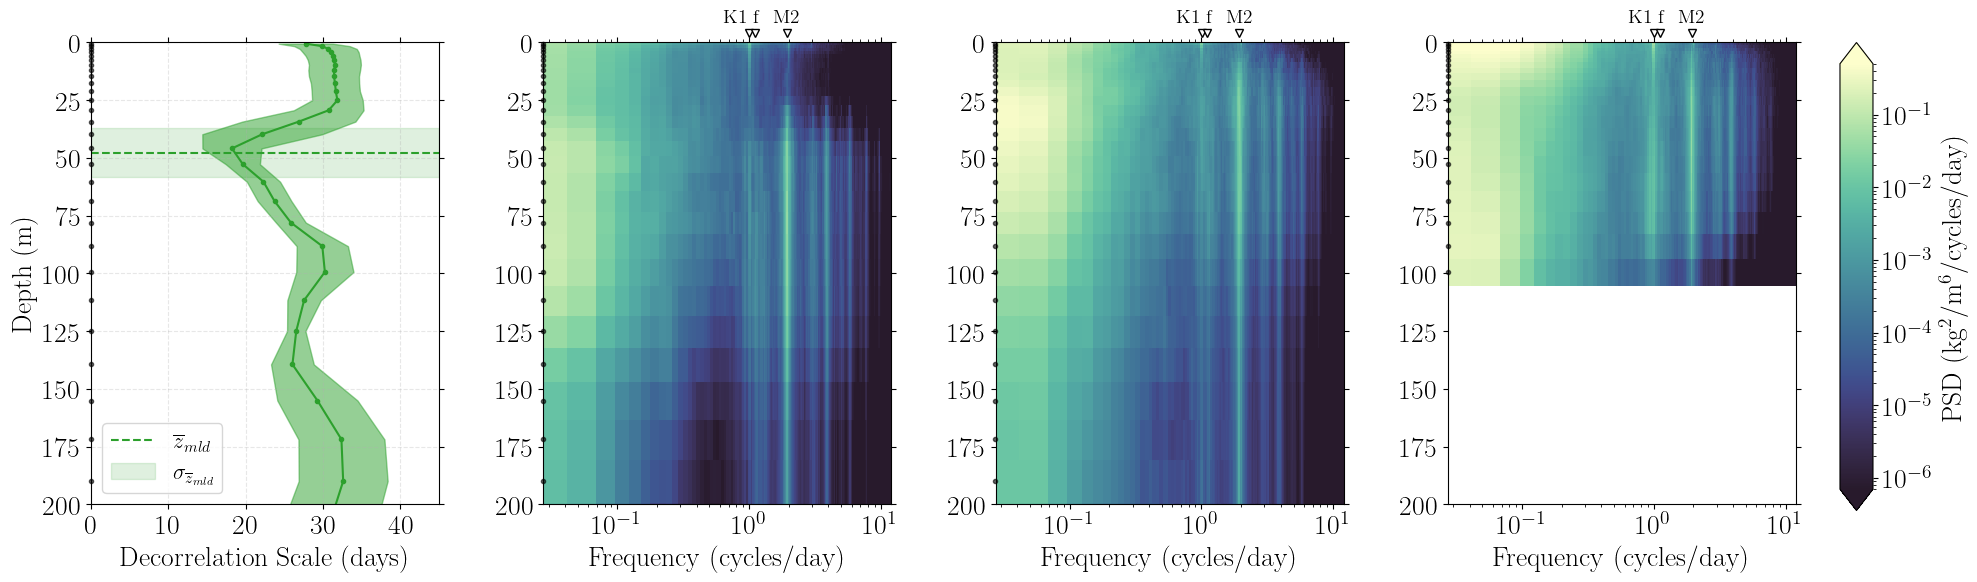

In [43]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=5e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,4,figsize=(22, 6))
ax1, ax2, ax3, ax4 = axes.flatten()

#--- Subplot 1 ---# 

# Plot potential density decor scales
ax1.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green')
# ax1.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red')
# ax1.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue')

# Plot standard error of the mean
ax1.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)
# ax1.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)
# ax1.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
ax1.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
# ax1.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)
# ax1.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax1.fill_between([0, 45], mld_mean_m[0] - mld_std_mean_m[0], mld_mean_m[0] + mld_std_mean_m[0], color='tab:green', alpha=0.15, label=r"$\sigma_{\overline{z}_{mld}}$")
# ax1.fill_between([0, 45], mld_mean_m[1] - mld_std_mean_m[1], mld_mean_m[1] + mld_std_mean_m[1], color='tab:red', alpha=0.15)
# ax1.fill_between([0, 45], mld_mean_m[2] - mld_std_mean_m[2], mld_mean_m[2] + mld_std_mean_m[2], color='tab:blue', alpha=0.15)

# Set left edge x-position
x_right = ax1.get_xlim()[0] + 2.2 

# Plot model grid depth levels
ax1.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set axis attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0,45)
ax1.set_ylim(0,200)
ax1.set_ylim(depth_lim[0], depth_lim[1])
ax1.set_xticks([0, 10, 20, 30, 40])
ax1.invert_yaxis()
ax1.legend(fontsize=16,loc='lower left')
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax2.pcolormesh(F_m,D_m,S_Rho_m[0,:,:],cmap=cmap,shading='auto',norm=norm)
#ax2.plot(fd1_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set right edge x-position
x_right = ax2.get_xlim()[0] + 0.041

# Plot model grid depth levels
ax2.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE2 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax3.pcolormesh(F_m,D_m,S_Rho_m[1,:,:],cmap=cmap,shading='auto',norm=norm)
#ax3.plot(fd2_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set right edge x-position
x_right = ax3.get_xlim()[0] + 0.041

# Plot model grid depth levels
ax3.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax3.set_ylim(depth_lim[0],depth_lim[1])
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

pc = ax4.pcolormesh(F_m,D_m,S_Rho_m[2,:,:],cmap=cmap,shading='auto',norm=norm)
#ax4.plot(fd3_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set figure attributes
ax4.set_xlabel('Frequency (cycles/day)')
ax4.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax4.set_ylim(depth_lim[0],depth_lim[1])
ax4.invert_yaxis() 
ax4.set_xscale('log')
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax4.tick_params(which='major', length=3.5)
ax4.tick_params(which='minor', length=2.5)

# Set right edge x-position
x_right = ax4.get_xlim()[0] + 0.0001 

# Plot model grid depth levels
ax4.plot(
    np.full_like(depth_cce3, x_right),
    depth_cce3,
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Plot the tidal and inertial frequencies
for ax in (ax2, ax3, ax4):
    
    # K1 label shifted slightly left
    add_freq_marker(ax, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

    # f label shifted slightly right
    add_freq_marker(ax, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

    # M2 centered
    add_freq_marker(ax, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.3)
plt.show()

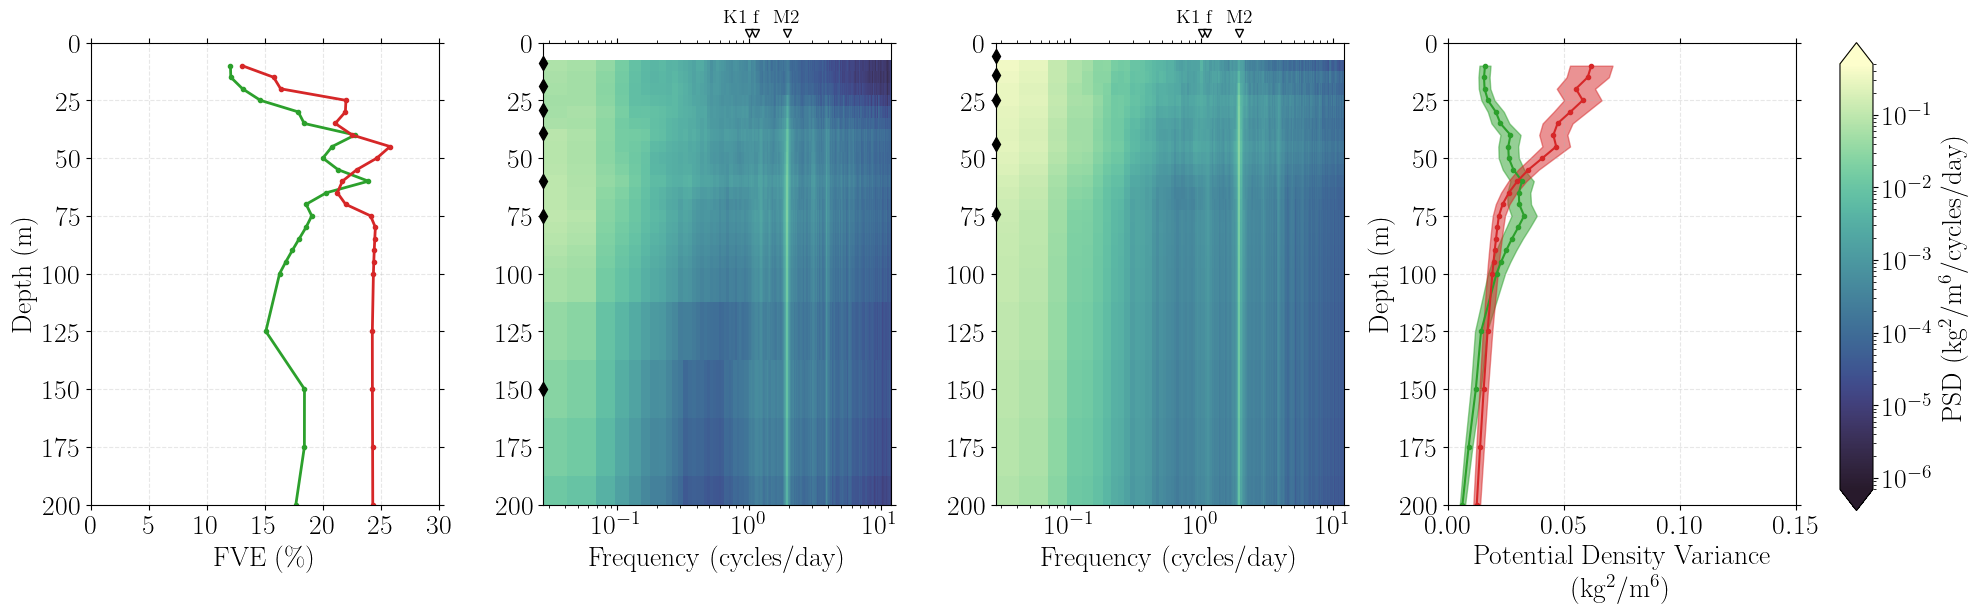

In [68]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=5e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,4,figsize=(22, 6))
ax1, ax2, ax3, ax4 = axes.flatten()

#--- Subplot 1 ---#  

# Plot potential density decor scales
#ax1.plot(Lt1_rho,depth1,'.-', color='tab:green')
#ax1.plot(Lt2_rho,depth2,'.-', color='tab:red',label='CCE2')

# Plot standard error of the mean
#ax1.fill_betweenx(depth1, Lt1_rho - Lt1_rho_stdm, Lt1_rho + Lt1_rho_stdm, color='tab:green', alpha=0.5)
#ax1.fill_betweenx(depth2, Lt2_rho - Lt2_rho_stdm, Lt2_rho + Lt2_rho_stdm, color='tab:red', alpha=0.5)

# Plot the mean mixed layer depth 
#ax1.axhline(mld1_mean, ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
#ax1.axhline(mld2_mean, ls='--', lw=1.5, color='tab:red', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
#ax1.fill_between([0, 45], mld1_mean - mld1_std_mean, mld1_mean + mld1_std_mean, color='tab:green', alpha=0.3)
#ax1.fill_between([0, 45], mld2_mean - mld2_std_mean, mld2_mean + mld2_std_mean, color='tab:red', alpha=0.3)

# Plot the sensor depths 
# ax1.plot(
#     np.zeros_like(cce2_sensor_depth),   # x = 0 → left edge in axis coords
#     cce2_sensor_depth,
#     marker='d', linestyle='None',
#     color='k', markersize=7, alpha=1,
#     transform=ax1.get_yaxis_transform(),  # KEY LINE
#     clip_on=False,
# )

# Set axis attributes
# ax1.set_ylabel('Depth (m)')
# ax1.set_xlabel(r'Decorrelation Scale (days)')
# ax1.set_xlim(0,45)
# ax1.set_ylim(depth_lim[0], depth_lim[1])
# ax1.set_xticks([10, 20, 30, 40])
# ax1.invert_yaxis()
# #ax1.legend()
# ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
#          direction='out', length=3.5)
# ax1.grid(True,linestyle='--',alpha=0.3)

# Plot the profile of fraction of variance explained by high-frequencies for each mooring
ax1.plot(FVE_cce1*100,abs(depth1),'.-',color='tab:green',label='CCE 1', lw = 2)
ax1.plot(FVE_cce2*100,abs(depth2),'.-',color='tab:red',label='CCE 2', lw = 2)

# Set axis attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'FVE ($\%$)')
ax1.set_xlim(0,30)
ax1.set_ylim(0,200)
ax1.set_xticks(np.arange(0,30+5,5))
ax1.set_yticks(np.arange(0,200+25,25))
ax1.invert_yaxis()
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax2.pcolormesh(F,D,S1_rho,cmap=cmap,shading='auto', norm=norm)
#ax2.plot(fd1_rho, depth1, 'k^-', markersize=4)

# Plot the sensor depths 
ax2.plot(
    np.zeros_like(cce1_sensor_depth),   # x = 0 → left edge in axis coords
    cce1_sensor_depth,
    marker='d', linestyle='None',
    color='k', markersize=7, alpha=1,
    transform=ax2.get_yaxis_transform(),  # KEY LINE
    clip_on=False,
)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax3.pcolormesh(F,D,S2_rho,cmap=cmap,shading='auto', norm=norm)
#ax3.plot(fd2_rho, depth2, 'k^-', markersize=4)

# Plot the sensor depths 
ax3.plot(
    np.zeros_like(cce2_sensor_depth),   # x = 0 → left edge in axis coords
    cce2_sensor_depth,
    marker='d', linestyle='None',
    color='k', markersize=7, alpha=1,
    transform=ax3.get_yaxis_transform(),  # KEY LINE
    clip_on=False,
)

# Set figure attributes
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax3.set_ylim(depth_lim[0],depth_lim[1])
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

#--- Subplot 4 ---# 

# Plot variance anomaly  profiles for each mooring
ax4.plot(var_anom_Rho1,abs(depth1),'.-',color='tab:green',label='CCE 1')
ax4.plot(var_anom_Rho2,abs(depth2),'.-',color='tab:red',label='CCE 2')

# Plot standard error of the variance profiles for each mooring
ax4.fill_betweenx(abs(depth1), var_anom_Rho1 - var_anom_Rho1_stdv, var_anom_Rho1 + var_anom_Rho1_stdv, color='tab:green', alpha=0.5)
ax4.fill_betweenx(abs(depth2), var_anom_Rho2 - var_anom_Rho2_stdv, var_anom_Rho2 + var_anom_Rho2_stdv, color='tab:red', alpha=0.5)

# Set axis attributes
ax4.set_ylabel('Depth (m)')
ax4.set_xlabel(f'Potential Density Variance \n(kg$^2$/m$^6$)')
ax4.set_xlim(0,0.15)
ax4.set_ylim(0,200)
ax4.set_xticks([0, 0.05, 0.1, 0.15])
ax4.invert_yaxis()
ax4.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax4.grid(True,linestyle='--',alpha=0.3)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Plot the tidal and inertial frequencies
for ax in (ax2, ax3):
    
    # K1 label shifted slightly left
    add_freq_marker(ax, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

    # f label shifted slightly right
    add_freq_marker(ax, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

    # M2 centered
    add_freq_marker(ax, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.3)
plt.show()


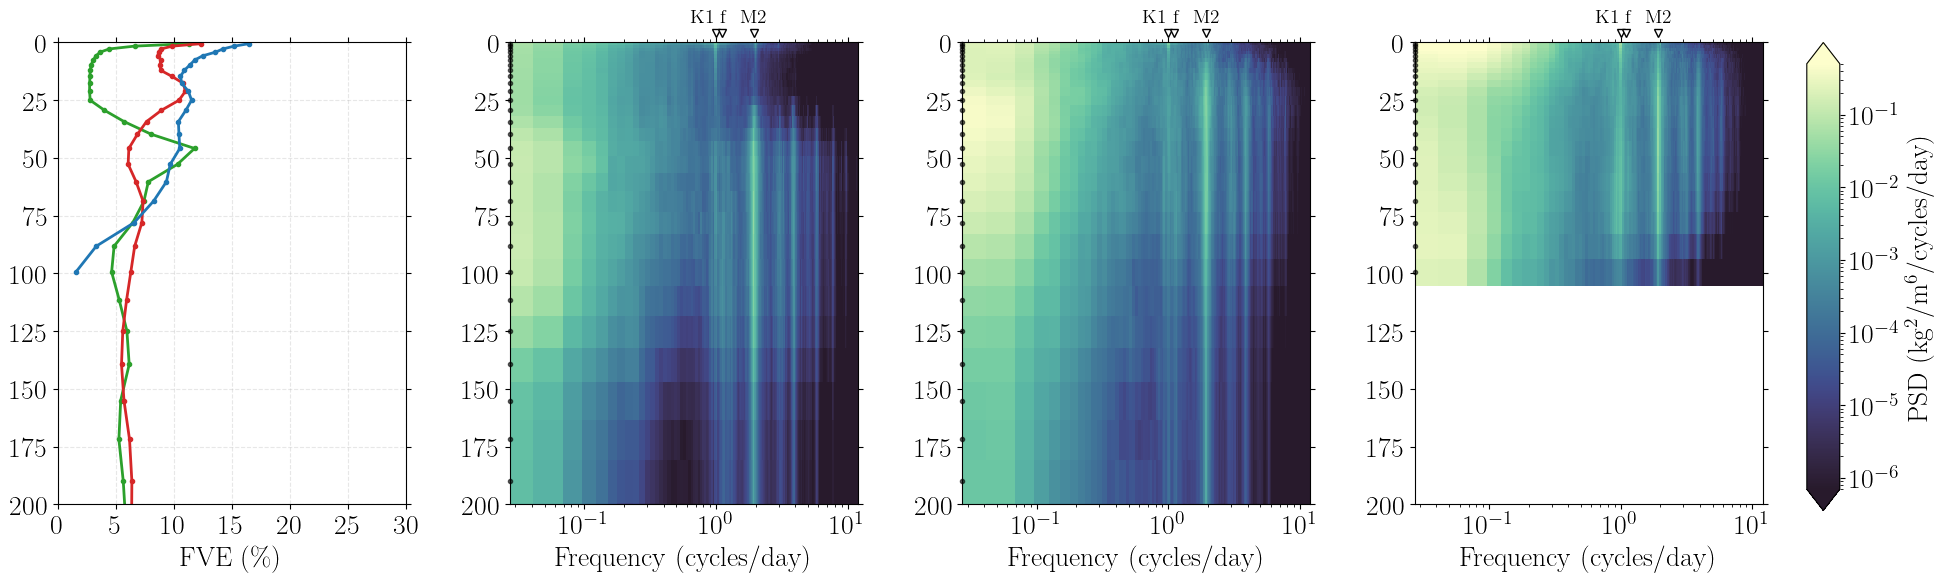

In [65]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=5e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,4,figsize=(22, 6))
ax1, ax2, ax3, ax4 = axes.flatten()

#--- Subplot 1 ---# 

# Plot potential density decor scales
# ax1.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green')
# ax1.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red')
#ax1.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue')

# Plot standard error of the mean
# ax1.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)
# ax1.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)
#ax1.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
# ax1.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
# ax1.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)
# ax1.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
# ax1.fill_between([0, 45], mld_mean_m[0] - mld_std_mean_m[0], mld_mean_m[0] + mld_std_mean_m[0], color='tab:green', alpha=0.15, label=r"$\sigma_{\overline{z}_{mld}}$")
# ax1.fill_between([0, 45], mld_mean_m[1] - mld_std_mean_m[1], mld_mean_m[1] + mld_std_mean_m[1], color='tab:red', alpha=0.15)
# ax1.fill_between([0, 45], mld_mean_m[2] - mld_std_mean_m[2], mld_mean_m[2] + mld_std_mean_m[2], color='tab:blue', alpha=0.15)

# Set right edge x-position
# x_right = ax1.get_xlim()[0] + 2.2

# # Plot model grid depth levels
# ax1.plot(
#     np.full_like(depth_cce3, x_right),
#     depth_cce3,
#     marker='.', linestyle='None',
#     color='k', markersize=6, alpha=0.6,
#     clip_on=False
# )

# Set axis attributes
# ax1.set_ylabel('Depth (m)')
# ax1.set_xlabel(r'Decorrelation Scale (days)')
# ax1.set_xlim(0,45)
# ax1.set_ylim(0,200)
# ax1.set_ylim(depth_lim[0], depth_lim[1])
# ax1.set_xticks([0, 10, 20, 30, 40])
# ax1.invert_yaxis()
# #ax1.legend(fontsize=16,loc='lower left')
# ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
#             direction='out', length=3.5)
# ax1.grid(True,linestyle='--',alpha=0.3)

# Plot the profile of fraction of variance explained by high-frequencies for each mooring
ax1.plot(FVE_cce1_m*100,abs(depth_upper_m),'.-',color='tab:green',label='CCE 1', lw = 2)
ax1.plot(FVE_cce2_m*100,abs(depth_upper_m),'.-',color='tab:red',label='CCE 2', lw = 2)
ax1.plot(FVE_cce3_m*100,abs(depth_upper_m),'.-',color='tab:blue',label='CCE 3', lw = 2)

# Set axis attributes
ax1.set_xlabel(r'FVE ($\%$)')
ax1.set_xlim(0,30)
ax1.set_ylim(0,200)
ax1.set_xticks(np.arange(0,30+5,5))
ax1.set_yticks(np.arange(0,200+25,25))
ax1.invert_yaxis()
ax1.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax2.pcolormesh(F_m,D_m,S_Rho_m[0,:,:],cmap=cmap,shading='auto',norm=norm)
#ax2.plot(fd1_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set right edge x-position
x_right = ax2.get_xlim()[0] + 0.041

# Plot model grid depth levels
ax2.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot CCE2 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax3.pcolormesh(F_m,D_m,S_Rho_m[1,:,:],cmap=cmap,shading='auto',norm=norm)
#ax3.plot(fd2_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set right edge x-position
x_right = ax3.get_xlim()[0] + 0.041

# Plot model grid depth levels
ax3.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax3.set_xlabel('Frequency (cycles/day)')
ax3.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax3.set_ylim(depth_lim[0],depth_lim[1])
ax3.invert_yaxis() 
ax3.set_xscale('log')
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax3.tick_params(which='major', length=3.5)
ax3.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

pc = ax4.pcolormesh(F_m,D_m,S_Rho_m[2,:,:],cmap=cmap,shading='auto',norm=norm)
#ax4.plot(fd3_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set figure attributes
ax4.set_xlabel('Frequency (cycles/day)')
ax4.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax4.set_ylim(depth_lim[0],depth_lim[1])
ax4.invert_yaxis() 
ax4.set_xscale('log')
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax4.tick_params(which='major', length=3.5)
ax4.tick_params(which='minor', length=2.5)

# Set right edge x-position
x_right = ax4.get_xlim()[0] + 0.0001 

# Plot model grid depth levels
ax4.plot(
    np.full_like(depth_cce3, x_right),
    depth_cce3,
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set color bar
cax = fig.add_axes([0.92, 0.1, 0.015, 0.78]) 
cbar = fig.colorbar(pc, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Plot the tidal and inertial frequencies
for ax in (ax2, ax3, ax4):
    
    # K1 label shifted slightly left
    add_freq_marker(ax, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

    # f label shifted slightly right
    add_freq_marker(ax, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

    # M2 centered
    add_freq_marker(ax, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.3)
plt.show()

Compute the bandpass variance for each mooring location 

In [60]:
# --------------------------------------------------
# Set the frequency cutoff 
# --------------------------------------------------
f_split = 1/7  # units: cpd

# Create frequency mask for high and low frequency bands
mask_low  = f_cpd_m <= f_split
mask_high = ~mask_low

# Compute frequency spacing (IMPORTANT)
df = np.gradient(f_cpd_m)

# --------------------------------------------------
# --- Model ---
# --------------------------------------------------

# Apply masks and integrate over frequency axis
var_high_m = np.sum(S_Rho_m * mask_high * df, axis=2)
var_low_m  = np.sum(S_Rho_m * mask_low  * df, axis=2)

# Total variance
var_total_m = np.sum(S_Rho_m * df, axis=2)

# --------------------------------------------------
# --- Observations ---
# --------------------------------------------------

# Apply masks and integrate over frequency axis
var1_high_obs = np.sum(S1_rho * mask_high * df, axis=1)
var1_low_obs  = np.sum(S1_rho * mask_low  * df, axis=1)
var2_high_obs = np.sum(S2_rho * mask_high * df, axis=1)
var2_low_obs  = np.sum(S2_rho * mask_low  * df, axis=1)

# Total variance
var1_total_obs = np.sum(S1_rho * df, axis=1)
var2_total_obs = np.sum(S2_rho * df, axis=1)

# --------------------------------------------------
# Optional sanity checks
# --------------------------------------------------
print("Model variance closure (mean difference):",
      np.nanmean(var_total_m - (var_high_m + var_low_m)))

print("CCE1 Obs variance closure (mean difference):",
      np.nanmean(var1_total_obs - (var1_high_obs + var1_low_obs)))

print("CCE2 Obs variance closure (mean difference):",
      np.nanmean(var2_total_obs - (var2_high_obs + var2_low_obs)))

# --------------------------------------------------
# Compute the ratio between low frequency and high frequency variance
# --------------------------------------------------
FVE_cce1_m = var_high_m[0,:]/var_anom_Rho_m[0,:]                #(var_low_m[0,:] + var_high_m[0,:])
FVE_cce2_m = var_high_m[1,:]/var_anom_Rho_m[1,:]                #(var_low_m[1,:] + var_high_m[1,:])
FVE_cce3_m = var_high_m[2,:]/var_anom_Rho_m[2,:]                # (var_low_m[2,:] + var_high_m[2,:])

FVE_cce1 = var1_high_obs/var_anom_Rho1                          # (var1_low_obs + var1_high_obs)
FVE_cce2 = var2_high_obs/var_anom_Rho2                          # (var2_low_obs + var2_high_obs)

# FVE_cce1 = (var_low_m[0,:] - var_high_m[0,:])/var_low_m[0,:]
# FVE_cce2 = (var_low_m[1,:] - var_high_m[1,:])/var_low_m[1,:]
# FVE_cce3 = (var_low_m[2,:] - var_high_m[2,:])/var_low_m[2,:]


Model variance closure (mean difference): 6.280895344053957e-19
CCE1 Obs variance closure (mean difference): -3.205467292565839e-19
CCE2 Obs variance closure (mean difference): -4.525365589504714e-19


<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_19715/2868602142.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(var_low_m[0, :], depth_upper_m, ls =(0, (3, 2)), color='tab:green', lw=2, label='f $\leq$ 0.7 cpd')


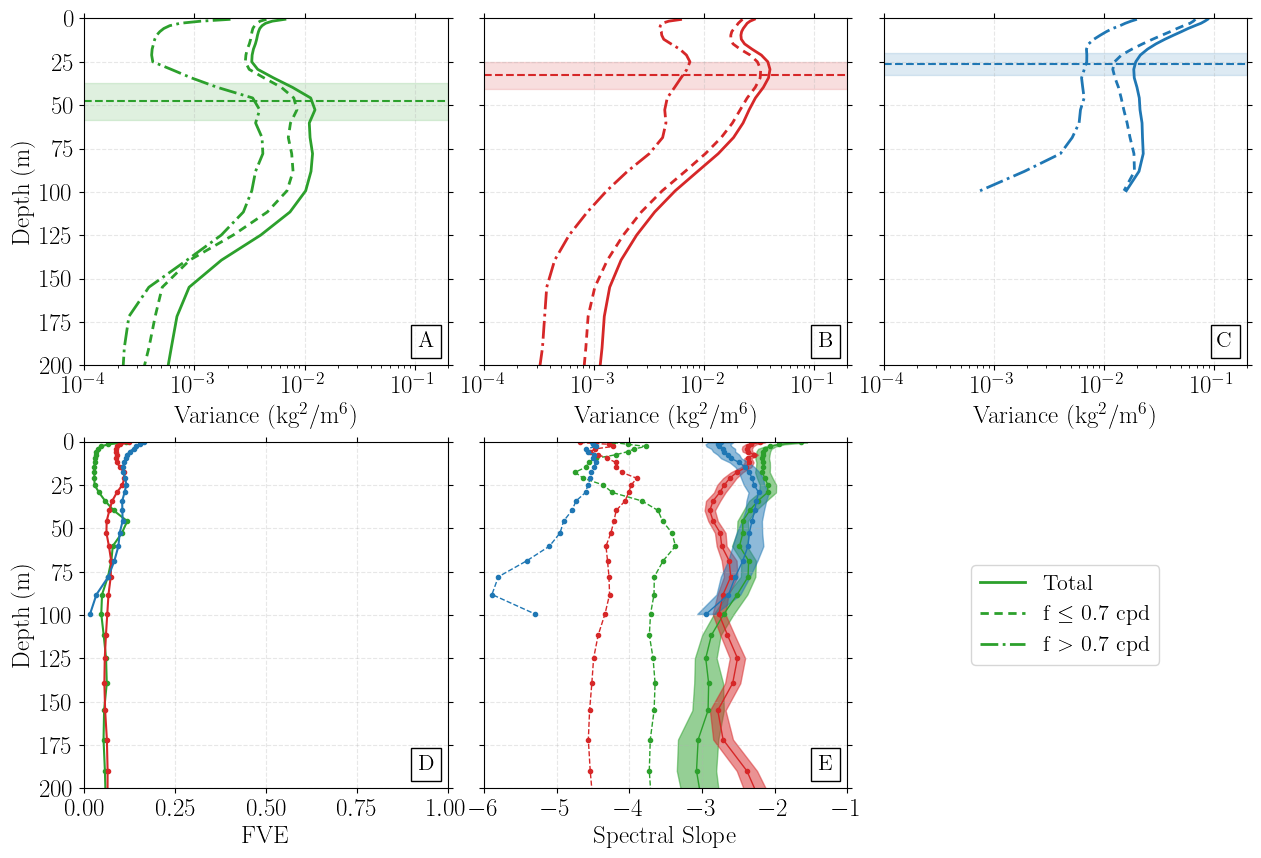

In [61]:
# Mask zero values at CCE3
var_low_m = np.ma.masked_where(var_low_m == 0, var_low_m)
var_high_m = np.ma.masked_where(var_high_m == 0, var_high_m)
var_total_m = np.ma.masked_where(var_total_m == 0, var_total_m)
FVE_cce3_m = np.ma.masked_where(FVE_cce3_m == 0, FVE_cce3_m)
spec_slope_Rho_sub_m = np.ma.masked_where(spec_slope_Rho_sub_m == 0, spec_slope_Rho_sub_m)
spec_slope_Rho_sup_m = np.ma.masked_where(spec_slope_Rho_sup_m == 0, spec_slope_Rho_sup_m)

# Set global fontsize
fontsize = 18
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(2,3,figsize=(15, 10))
ax_flat = axes.flatten()

#--- Subplot 1 ---# 
ax = ax_flat[0]

# Total variance
ax.plot(var_total_m[0, :], depth_upper_m, ls='-', color='tab:green', lw=2, label='Total')

# Low-frequency band
ax.plot(var_low_m[0, :], depth_upper_m, ls =(0, (3, 2)), color='tab:green', lw=2, label='f $\leq$ 0.7 cpd')

# High-frequency band
ax.plot(var_high_m[0, :], depth_upper_m, ls = '-.', color='tab:green', lw=2, label='f $>$ 0.7 cpd')

# Plot the mean mixed layer depth 
ax.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax.fill_between([0, 0.2], mld_mean_m[0] - mld_std_mean_m[0], mld_mean_m[0] + mld_std_mean_m[0], color='tab:green', alpha=0.15)

# Set axis attributes
ax.set_xlabel(r'Variance (kg$^2$/m$^6$)')
ax.set_ylabel('Depth (m)')
ax.set_xscale('log')
ax.set_xlim(10**(-4),2*10**(-1))
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  
ax = ax_flat[1]

# Total variance
ax.plot(var_total_m[1, :], depth_upper_m, ls='-', color='tab:red', lw=2)

# Low-frequency band
ax.plot(var_low_m[1, :], depth_upper_m, ls =(0, (3, 2)), color='tab:red', lw=2)

# High-frequency band
ax.plot(var_high_m[1, :], depth_upper_m, ls = '-.', color='tab:red', lw=2)

# Plot the mean mixed layer depth 
ax.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax.fill_between([0, 0.2], mld_mean_m[1] - mld_std_mean_m[1], mld_mean_m[1] + mld_std_mean_m[1], color='tab:red', alpha=0.15)

# Set axis attributes
ax.set_xlabel(r'Variance (kg$^2$/m$^6$)')
ax.set_xscale('log')
ax.set_xlim(10**(-4),2*10**(-1))
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 3 ---#  
ax = ax_flat[2]

# Total variance
ax.plot(var_total_m[2, :], depth_upper_m, ls='-', color='tab:blue', lw=2)

# Low-frequency band
ax.plot(var_low_m[2, :], depth_upper_m, ls =(0, (3, 2)), color='tab:blue', lw=2)

# High-frequency band
ax.plot(var_high_m[2, :], depth_upper_m, ls = '-.', color='tab:blue', lw=2)

# Plot the mean mixed layer depth 
ax.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
ax.fill_between([0, 0.2], mld_mean_m[2] - mld_std_mean_m[2], mld_mean_m[2] + mld_std_mean_m[2], color='tab:blue', alpha=0.15)

# Set axis attributes
ax.set_xlabel(r'Variance (kg$^2$/m$^6$)')
ax.set_xscale('log')
ax.set_xlim(10**(-4),2*10**(-1))
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 4 ---# 
ax = ax_flat[3]

# Plot fraction of variance explained by low frequency variability 
ax.plot(FVE_cce1_m,depth_upper_m,'.-', color='tab:green')
ax.plot(FVE_cce2_m,depth_upper_m,'.-', color='tab:red')
ax.plot(FVE_cce3_m,depth_upper_m,'.-', color='tab:blue')

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlabel('FVE')
ax.set_xlim(0,1)
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_xticks(np.arange(0,1+0.25,0.25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 
ax = ax_flat[4] 

# Plot the spectral slope in the subdiurnal range
ax.plot(spec_slope_Rho_sub_m[0,:], abs(depth_upper_m), '.-', color='tab:green', linewidth=1,label='CCE 1')
ax.plot(spec_slope_Rho_sub_m[1,:], abs(depth_upper_m), '.-', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(spec_slope_Rho_sub_m[2,:], abs(depth_upper_m), '.-', color='tab:blue', linewidth=1, label='CCE 3')

# Plot the spectral slope in the super-diurnal range
ax.plot(spec_slope_Rho_sup_m[0,:], abs(depth_upper_m), '.--', color='tab:green', linewidth=1,label='Total Variance')
ax.plot(spec_slope_Rho_sup_m[1,:], abs(depth_upper_m), '.--', color='tab:red', linewidth=1, label='CCE 2')
ax.plot(spec_slope_Rho_sup_m[2,:], abs(depth_upper_m), '.--', color='tab:blue', linewidth=1, label='CCE 3')

# Plot standard error for each mooring
ax.fill_betweenx(abs(depth_upper_m), spec_slope_Rho_sub_m[0,:] - spec_slope_Rho_sub_stdm_m[0,:], spec_slope_Rho_sub_m[0,:] + spec_slope_Rho_sub_stdm_m[0,:], color='tab:green', alpha=0.5)
ax.fill_betweenx(abs(depth_upper_m), spec_slope_Rho_sub_m[1,:] - spec_slope_Rho_sub_stdm_m[1,:], spec_slope_Rho_sub_m[1,:] + spec_slope_Rho_sub_stdm_m[1,:], color='tab:red', alpha=0.5)
ax.fill_betweenx(abs(depth_upper_m), spec_slope_Rho_sub_m[2,:] - spec_slope_Rho_sub_stdm_m[2,:], spec_slope_Rho_sub_m[2,:] + spec_slope_Rho_sub_stdm_m[2,:], color='tab:blue', alpha=0.5)

# ax.fill_betweenx(abs(depth_upper_m), spec_slope_Rho_sup_m[0,:] - spec_slope_Rho_sup_stdm_m[0,:], spec_slope_Rho_sup_m[0,:] + spec_slope_Rho_sup_stdm_m[0,:], color='tab:green', alpha=0.5)
# ax.fill_betweenx(abs(depth_upper_m), spec_slope_Rho_sup_m[1,:] - spec_slope_Rho_sup_stdm_m[1,:], spec_slope_Rho_sup_m[1,:] + spec_slope_Rho_sup_stdm_m[1,:], color='tab:red', alpha=0.5)
# ax.fill_betweenx(abs(depth_upper_m), spec_slope_Rho_sup_m[2,:] - spec_slope_Rho_sup_stdm_m[2,:], spec_slope_Rho_sup_m[2,:] + spec_slope_Rho_sup_stdm_m[2,:], color='tab:blue', alpha=0.5)

# Set axis attributes
ax.set_xlabel('Spectral Slope')
ax.set_xlim(-6,-1)
ax.set_ylim(depth_lim[0], depth_lim[1])
ax.set_xticks(np.arange(-6,-1+1,1))
ax.set_yticks(np.arange(0,200+25,25))
ax.set_yticklabels([])
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 5 ---# 
ax = ax_flat[5]

# Turn off axis
ax.axis('off')

# Obtain the handle for the legend 
handles = []
labels = []

# Loop through axes that contain legend items
for i in [0,1,2,3]:  
    h, l = ax_flat[i].get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Display legend in the position of the 6th axis
ax.legend(handles, labels, loc='center', fontsize=16)

# Label each subplot
pos = [0.94, 0.07]
add_corner_label(ax_flat[0], pos, 'A', fontsize = 16)
add_corner_label(ax_flat[1], pos, 'B', fontsize = 16)
add_corner_label(ax_flat[2], pos, 'C', fontsize = 16)
add_corner_label(ax_flat[3], pos, 'D', fontsize = 16)
add_corner_label(ax_flat[4], pos, 'E', fontsize = 16)

# Display figure
plt.subplots_adjust(hspace=0.22, wspace=0.1)
plt.show()

# Save with high quality
figName = 'figS05.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


In [28]:
depth_upper_m 

array([  0.5  ,   1.57 ,   2.79 ,   4.185,   5.78 ,   7.595,   9.66 ,
        12.01 ,  14.68 ,  17.705,  21.125,  24.99 ,  29.345,  34.24 ,
        39.725,  45.855,  52.69 ,  60.28 ,  68.685,  77.965,  88.175,
        99.37 , 111.6  , 124.915, 139.365, 154.99 , 171.825, 189.9  ,
       209.235], dtype=float32)

In [34]:
print(np.mean(spec_slope_Rho_sub_m[0,depth_upper_m < 48]))
print(np.std(spec_slope_Rho_sub_m[0,depth_upper_m < 48])/np.sqrt(np.sum(depth_upper_m < 48)))

-2.130371910896488
0.04167733659476671


In [42]:
print(np.mean(spec_slope_Rho_sup_m[0,:]))
print(np.std(spec_slope_Rho_sup_m[0,:])/np.sqrt(len(depth_upper_m)))

-3.9271921948055595
0.07212808601012571


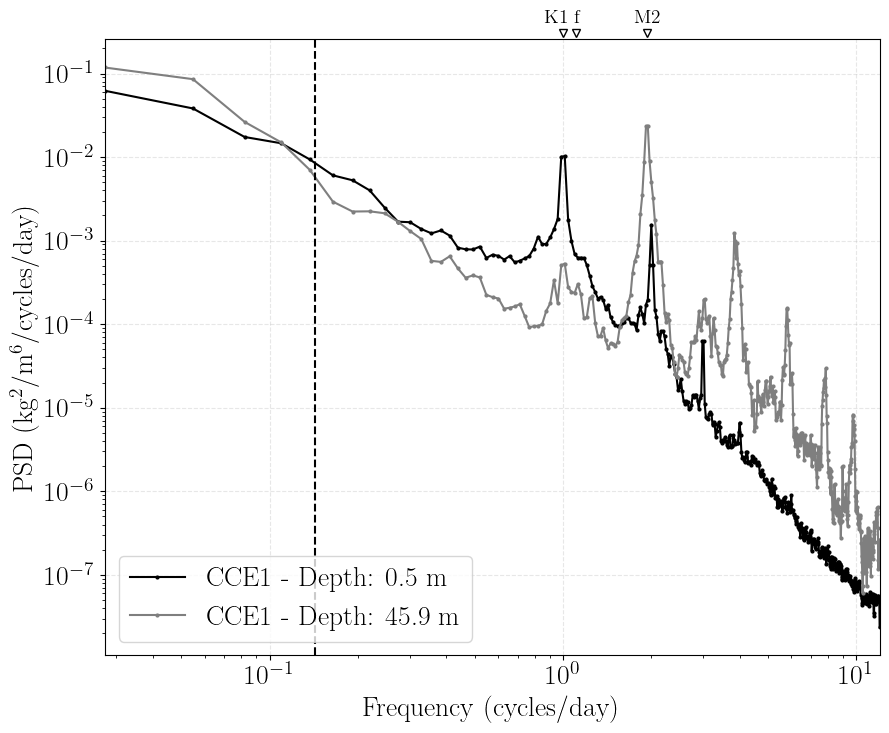

In [30]:
# set split frequency
f_split = 1/7  # units: cpd

# Create figure
fig, ax = plt.subplots(1,1,figsize=(10, 8))

# Plot model potential density spectra for CCE1 at two depths
ax.loglog(f_cpd_m, S_Rho_m[0, 0, :], label=f'CCE1 - Depth: {depth_upper_m[0]:.1f} m', color='k', linestyle='-', marker='o', markersize=2)
ax.loglog(f_cpd_m, S_Rho_m[0, 15, :], label=f'CCE1 - Depth: {depth_upper_m[15]:.1f} m', color='tab:gray', linestyle='-', marker='o', markersize=2)

# Plot the tidal and inertial frequencies
add_freq_marker(ax, f_k1, 'K1', x_text_offset_pts=-5, y_marker=1.01, y_text=1.02,fontsize=14)
add_freq_marker(ax, f1_i, 'f',  x_text_offset_pts=1, y_marker=1.01, y_text=1.02,fontsize=14)
add_freq_marker(ax, f_m2, 'M2', y_marker=1.01, y_text=1.02,fontsize=14)  

# Plot a vertical line at the frequency cutoff
ax.axvline(f_split, color='k', linestyle='--')

# Set axis attributes
ax.set_xlabel('Frequency (cycles/day)')
ax.set_ylabel(r'PSD (kg$^2$/m$^6$/cycles/day)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
#ax.set_ylim(10**(-4), 10**(0))
#ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.legend(loc='lower left')
ax.grid(True,linestyle='--',alpha=0.3)  


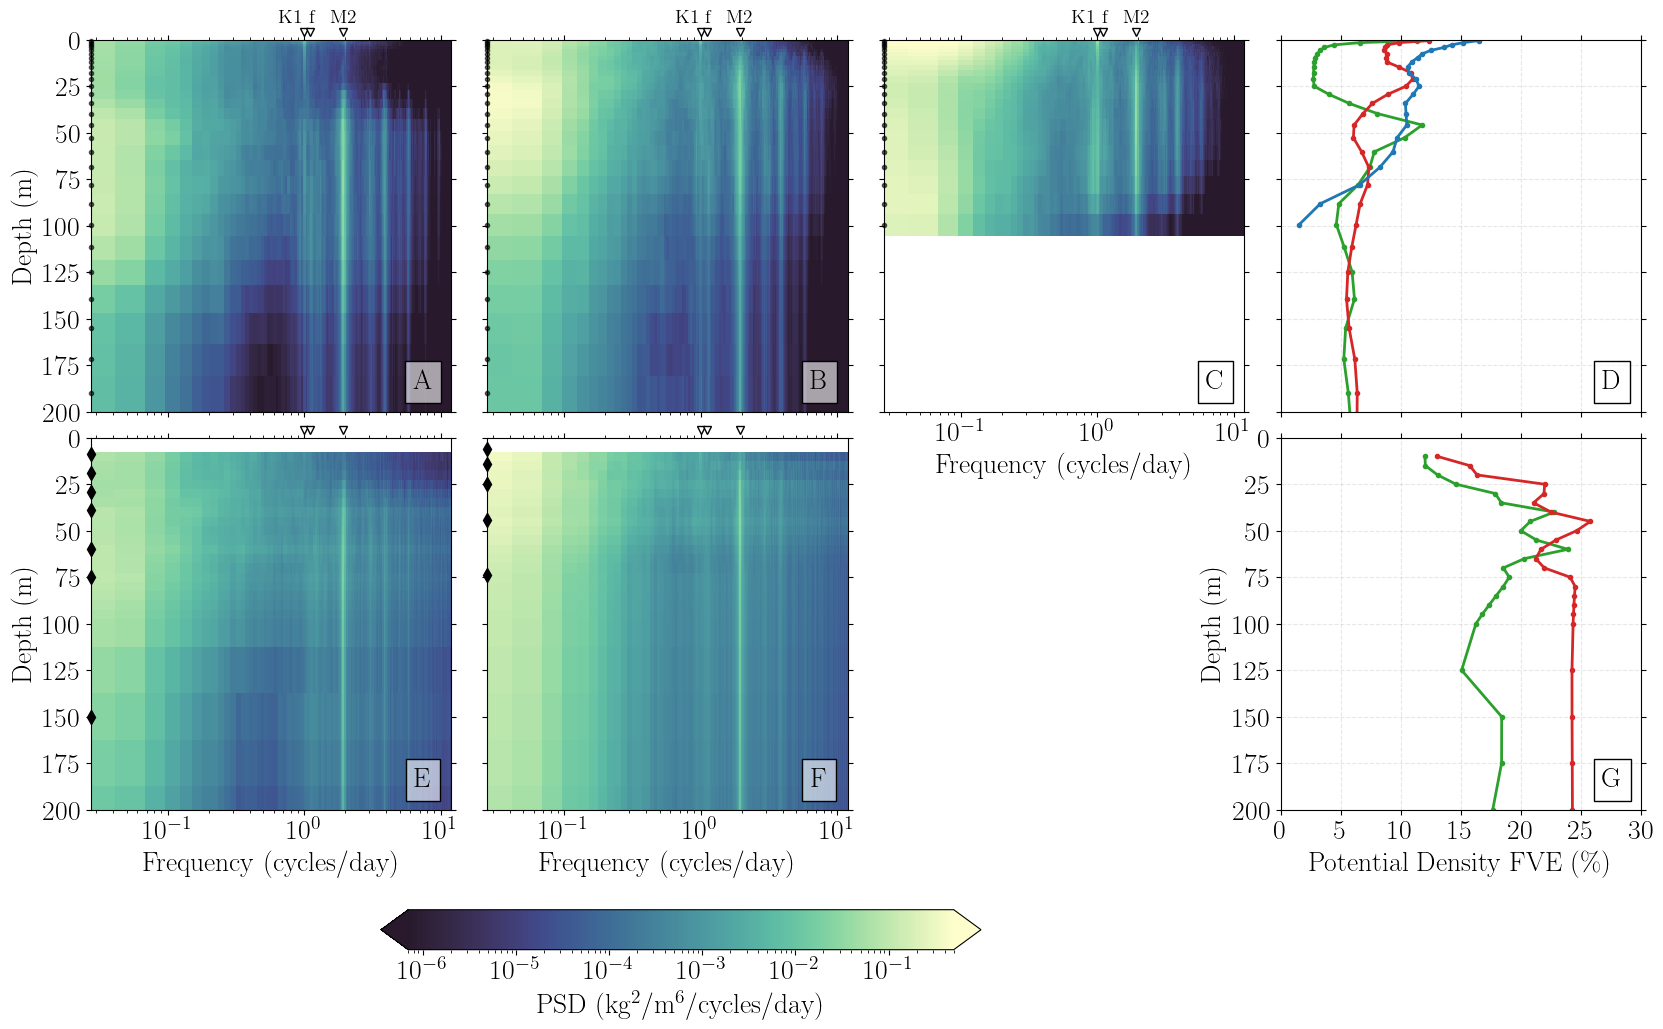

In [45]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
#norm = mcolors.LogNorm(vmin=4e-2, vmax=3e4)
norm = mcolors.LogNorm(vmin=7e-7, vmax=5e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(2,4,figsize=(20, 10))
ax_flat = axes.flatten()

#--- Subplot 1 ---#  
ax = ax_flat[0]

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax.pcolormesh(F_m,D_m,S_Rho_m[0,:,:],cmap=cmap,shading='auto',norm=norm)
#ax.plot(fd1_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set right edge x-position
x_right = ax.get_xlim()[0] + 0.041

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax.set_ylabel('Depth (m)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)
ax.set_xticklabels([])
# for i, label in enumerate(ax.get_yticklabels()):
#     if i % 2 != 0:
#         label.set_visible(False)

#--- Subplot 2 ---#  
ax = ax_flat[1]

# Plot CCE2 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax.pcolormesh(F_m,D_m,S_Rho_m[1,:,:],cmap=cmap,shading='auto',norm=norm)
#ax.plot(fd2_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set right edge x-position
x_right = ax.get_xlim()[0] + 0.041

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_upper_m[:-1], x_right),
    depth_upper_m[:-1],
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_yticklabels([])
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)
ax.set_xticklabels([])

#--- Subplot 3 ---#  
ax = ax_flat[2]

pc = ax.pcolormesh(F_m,D_m,S_Rho_m[2,:,:],cmap=cmap,shading='auto',norm=norm)
#ax.plot(fd3_rho_m, depth_upper_m, 'k^-', markersize=4)

# Set right edge x-position
x_right = ax.get_xlim()[0] + 0.041 

# Plot model grid depth levels
ax.plot(
    np.full_like(depth_cce3, x_right),
    depth_cce3,
    marker='.', linestyle='None',
    color='k', markersize=6, alpha=0.6,
    clip_on=False
)

# Set figure attributes
ax.set_xlabel('Frequency (cycles/day)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_yticklabels([])
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
        direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)

#--- Subplot 4 ---# 
ax = ax_flat[3]

# Plot the profile of fraction of variance explained by high-frequencies for each mooring
ax.plot(FVE_cce1_m*100,abs(depth_upper_m),'.-',color='tab:green',label='CCE 1', lw = 2)
ax.plot(FVE_cce2_m*100,abs(depth_upper_m),'.-',color='tab:red',label='CCE 2', lw = 2)
ax.plot(FVE_cce3_m*100,abs(depth_upper_m),'.-',color='tab:blue',label='CCE 3', lw = 2)

# Set axis attributes
ax.set_yticklabels([])
ax.set_xlim(0,30)
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,30+5,5))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)
ax.set_xticklabels([])

# # Plot variance anomaly  profiles for each mooring
# ax.plot(var_anom_Rho_m[0,:],abs(depth_upper_m),'.-',color='tab:green',label='CCE 1')
# ax.plot(var_anom_Rho_m[1,:],abs(depth_upper_m),'.-',color='tab:red',label='CCE 2')
# ax.plot(var_anom_Rho_m[2,:],abs(depth_upper_m),'.-',color='tab:blue',label='CCE 3')

# # Plot standard error of the variance profiles for each mooring
# ax.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[0,:] - var_anom_Rho_stdv_m[0,:], var_anom_Rho_m[0,:] + var_anom_Rho_stdv_m[0,:], color='tab:green', alpha=0.5)
# ax.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[1,:] - var_anom_Rho_stdv_m[1,:], var_anom_Rho_m[1,:] + var_anom_Rho_stdv_m[1,:], color='tab:red', alpha=0.5)
# ax.fill_betweenx(abs(depth_upper_m), var_anom_Rho_m[2,:] - var_anom_Rho_stdv_m[2,:], var_anom_Rho_m[2,:] + var_anom_Rho_stdv_m[2,:], color='tab:blue', alpha=0.5)

# # Set axis attributes
# ax.set_yticklabels([])
# ax.set_xscale('log')
# ax.set_xlim(2*10**(-3),2*10**(-1))
# #ax.set_xlim(0,0.15)
# ax.set_ylim(0,200)
# ax.set_yticks(np.arange(0,200+25,25))
# ax.invert_yaxis()
# ax.tick_params(top=True, bottom=True, left=True, right=True,
#             direction='out', length=3.5)
# ax.grid(True,linestyle='--',alpha=0.3)
# ax.set_xticklabels([])

#--- Subplot 5 ---# 
ax = ax_flat[4]

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax.pcolormesh(F,D,S1_rho,cmap=cmap,shading='auto', norm=norm)
#ax.plot(fd1_rho, depth1, 'k^-', markersize=4)

# Plot the sensor depths 
ax.plot(
    np.zeros_like(cce1_sensor_depth),   # x = 0 → left edge in axis coords
    cce1_sensor_depth,
    marker='d', linestyle='None',
    color='k', markersize=7, alpha=1,
    transform=ax.get_yaxis_transform(),  # KEY LINE
    clip_on=False,
)

# Set figure attributes
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Frequency (cycles/day)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)
# for i, label in enumerate(ax.get_yticklabels()):
#     if i % 2 != 0:
#         label.set_visible(False)

#--- Subplot 6 ---#  
ax = ax_flat[5]

# Plot CCE1 potential density spectrogram overlayed with decorrelation frequency markers
pc = ax.pcolormesh(F,D,S2_rho,cmap=cmap,shading='auto', norm=norm)
#ax.plot(fd2_rho, depth2, 'k^-', markersize=4)

# Set figure attributes
ax.set_xlabel('Frequency (cycles/day)')
ax.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax.set_ylim(depth_lim[0],depth_lim[1])
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis() 
ax.set_xscale('log')
ax.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax.tick_params(which='major', length=3.5)
ax.tick_params(which='minor', length=2.5)
ax.set_yticklabels([])

# Plot the sensor depths 
ax.plot(
    np.zeros_like(cce2_sensor_depth),   # x = 0 → left edge in axis coords
    cce2_sensor_depth,
    marker='d', linestyle='None',
    color='k', markersize=7, alpha=1,
    transform=ax.get_yaxis_transform(),  # KEY LINE
    clip_on=False,
)

#--- Subplot 7 ---# 
ax = ax_flat[6]

# Turn off axis
ax.axis('off')

#--- Subplot 8 ---# 
ax = ax_flat[7]

# Plot the profile of fraction of variance explained by high-frequencies for each mooring
ax.plot(FVE_cce1*100,abs(depth1),'.-',color='tab:green',label='CCE 1', lw = 2)
ax.plot(FVE_cce2*100,abs(depth2),'.-',color='tab:red',label='CCE 2', lw = 2)

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlabel(r'Potential Density FVE ($\%$)')
ax.set_xlim(0,30)
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,30+5,5))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_yaxis()
ax.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3)

# # Plot variance anomaly  profiles for each mooring
# ax.plot(var_anom_Rho1,abs(depth1),'.-',color='tab:green',label='CCE 1')
# ax.plot(var_anom_Rho2,abs(depth2),'.-',color='tab:red',label='CCE 2')

# # Plot standard error of the variance profiles for each mooring
# ax.fill_betweenx(abs(depth1), var_anom_Rho1 - var_anom_Rho1_stdv, var_anom_Rho1 + var_anom_Rho1_stdv, color='tab:green', alpha=0.5)
# ax.fill_betweenx(abs(depth2), var_anom_Rho2 - var_anom_Rho2_stdv, var_anom_Rho2 + var_anom_Rho2_stdv, color='tab:red', alpha=0.5)

# # Set axis attributes
# ax.set_ylabel('Depth (m)')
# ax.set_xlabel(f'Potential Density Variance \n(kg$^2$/m$^6$)')
# ax.set_xscale('log')
# ax.set_xlim(2*10**(-3),2*10**(-1))
# #ax.set_xlim(0,0.15)
# ax.set_ylim(0,200)
# #ax.set_xticks([0, 0.05, 0.1, 0.15])
# ax.set_yticks(np.arange(0,200+25,25))
# ax.invert_yaxis()
# ax.tick_params(top=True, bottom=True, left=True, right=True,
#             direction='out', length=3.5)
# ax.grid(True,linestyle='--',alpha=0.3)
# # for i, label in enumerate(ax.get_yticklabels()):
# #     if i % 2 != 0:
# #         label.set_visible(False)

# Set color bar
cax = fig.add_axes([0.27, -0.03, 0.3, 0.04]) 
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Label each subplot
pos = [0.92, 0.08] #[0.89, 0.09]
add_corner_label(ax_flat[0], pos, 'A', fontsize = fontsize)
add_corner_label(ax_flat[1], pos, 'B', fontsize = fontsize)
add_corner_label(ax_flat[2], pos, 'C', fontsize = fontsize)
add_corner_label(ax_flat[3], pos, 'D', fontsize = fontsize)
add_corner_label(ax_flat[4], pos, 'E', fontsize = fontsize)
add_corner_label(ax_flat[5], pos, 'F', fontsize = fontsize)
add_corner_label(ax_flat[7], pos, 'G', fontsize = fontsize)

# Plot the tidal and inertial frequencies
for i in [0,1,2,4,5]:
    
    if (i == 0) | (i == 1) | (i == 2): 

        # K1 label shifted slightly left
        add_freq_marker(ax_flat[i], f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

        # f label shifted slightly right
        add_freq_marker(ax_flat[i], f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

        # M2 centered
        add_freq_marker(ax_flat[i], f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

    else: 

        # K1 label shifted slightly left
        add_freq_marker(ax_flat[i], f_k1, '', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

        # f label shifted slightly right
        add_freq_marker(ax_flat[i], f1_i, '',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

        # M2 centered
        add_freq_marker(ax_flat[i], f_m2, '', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
figName = 'fig05.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

In [44]:
FVE_cce3_m*100

masked_array(data=[16.495971788293637, 15.211586471347587,
                   14.233709125787392, 13.591715909627252,
                   12.484788666724185, 11.802208379847904,
                   11.401399242298757, 10.916820002748581,
                   10.572441897344417, 10.696938504170635,
                   11.256159487376676, 11.534590802180645,
                   11.039996745450367, 10.39633270124212,
                   10.445966531960702, 10.51553074897449,
                   9.698536695818492, 9.363420931887854,
                   8.254999482828666, 6.581877575928857,
                   3.315529200015767, 1.558158061287131, --, --, --, --,
                   --, --, --],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False,  True,  True,
                    True,  True,  True,  True,  True],
       fill_value=1e+20)

<>:82: SyntaxWarning: invalid escape sequence '\%'
<>:82: SyntaxWarning: invalid escape sequence '\%'
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_10465/135400640.py:82: SyntaxWarning: invalid escape sequence '\%'
  ax3.set_xlabel(f'Potential Density FVE (\%)')


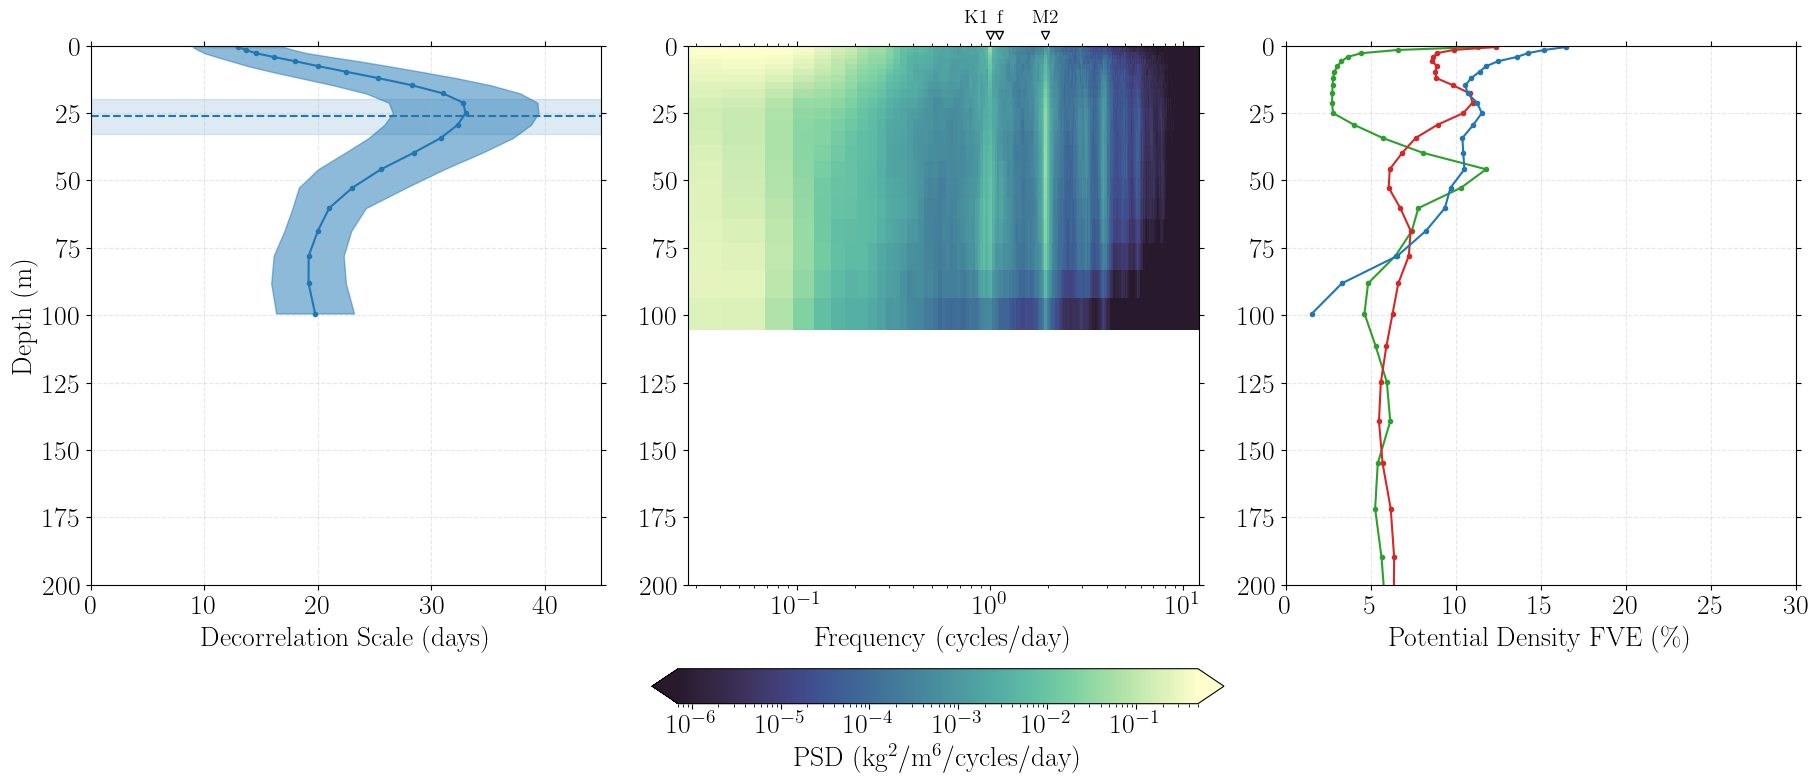

In [97]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=5e-1)

# Set the frequency and depth grid for the model and observations
F_m, D_m = np.meshgrid(f_cpd_m, depth_upper_m)
F_vel_m, D_vel_m = np.meshgrid(f_cpd_vel_m, depth_upper_m)
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,3,figsize=(22, 7))
ax1, ax2, ax3 = axes.flatten()

#--- Subplot 1 ---# 

# Plot potential density decor scales
#ax1.plot(Lt1_rho_m,depth_upper_m,'.-', color='tab:green')
# ax1.plot(Lt2_rho_m,depth_upper_m,'.-', color='tab:red')
ax1.plot(Lt3_rho_m,depth_upper_m,'.-', color='tab:blue')

# Plot standard error of the mean
# ax1.fill_betweenx(depth_upper_m, Lt1_rho_m - Lt1_rho_m_stdm, Lt1_rho_m + Lt1_rho_m_stdm, color='tab:green', alpha=0.5)
#ax1.fill_betweenx(depth_upper_m, Lt2_rho_m - Lt2_rho_m_stdm, Lt2_rho_m + Lt2_rho_m_stdm, color='tab:red', alpha=0.5)
ax1.fill_betweenx(depth_upper_m, Lt3_rho_m - Lt3_rho_m_stdm, Lt3_rho_m + Lt3_rho_m_stdm, color='tab:blue', alpha=0.5)

# Plot the mean mixed layer depth 
# ax1.axhline(mld_mean_m[0], ls='--', lw=1.5, color='tab:green', alpha=1, label=r"$\overline{z}_{mld}$")
# ax1.axhline(mld_mean_m[1], ls='--', lw=1.5, color='tab:red', alpha=1)
ax1.axhline(mld_mean_m[2], ls='--', lw=1.5, color='tab:blue', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
# ax1.fill_between([0, 45], mld_mean_m[0] - mld_std_mean_m[0], mld_mean_m[0] + mld_std_mean_m[0], color='tab:green', alpha=0.15)
# ax1.fill_between([0, 45], mld_mean_m[1] - mld_std_mean_m[1], mld_mean_m[1] + mld_std_mean_m[1], color='tab:red', alpha=0.15)
ax1.fill_between([0, 45], mld_mean_m[2] - mld_std_mean_m[2], mld_mean_m[2] + mld_std_mean_m[2], color='tab:blue', alpha=0.15)

# Set axis attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
ax1.set_xticks([0, 10, 20, 30, 40])
ax1.invert_yaxis()
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot CCE potential density spectrogram 
# pc = ax2.pcolormesh(F_m,D_m,S_Rho_m[0,:,:],cmap=cmap,shading='auto',norm=norm)
# pc = ax2.pcolormesh(F_m,D_m,S_Rho_m[1,:,:],cmap=cmap,shading='auto',norm=norm)
pc = ax2.pcolormesh(F_m,D_m,S_Rho_m[2,:,:],cmap=cmap,shading='auto',norm=norm)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot Fraction of variance explained by high-frequency variability for each mooring
ax3.plot(FVE_cce1_m*100,abs(depth_upper_m),'.-',color='tab:green',label='CCE 1')
ax3.plot(FVE_cce2_m*100,abs(depth_upper_m),'.-',color='tab:red',label='CCE 2')
ax3.plot(FVE_cce3_m*100,abs(depth_upper_m),'.-',color='tab:blue',label='CCE 3')

# Set figure attributes
ax3.set_xlabel(f'Potential Density FVE (\%)')
ax3.set_xlim(0,30)
ax3.set_ylim(0,200)
ax3.set_yticks(np.arange(0,200+25,25))
ax3.invert_yaxis()
ax3.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

# Set color bar
cax = fig.add_axes([0.38, -0.06, 0.26, 0.05]) 
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Plot the tidal and inertial frequencies

# K1 label shifted slightly left
add_freq_marker(ax2, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

# f label shifted slightly right
add_freq_marker(ax2, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

# M2 centered
add_freq_marker(ax2, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.17)
plt.show()

<>:74: SyntaxWarning: invalid escape sequence '\%'
<>:74: SyntaxWarning: invalid escape sequence '\%'
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_10465/3716435387.py:74: SyntaxWarning: invalid escape sequence '\%'
  ax3.set_xlabel(f'Potential Density FVE (\%)')


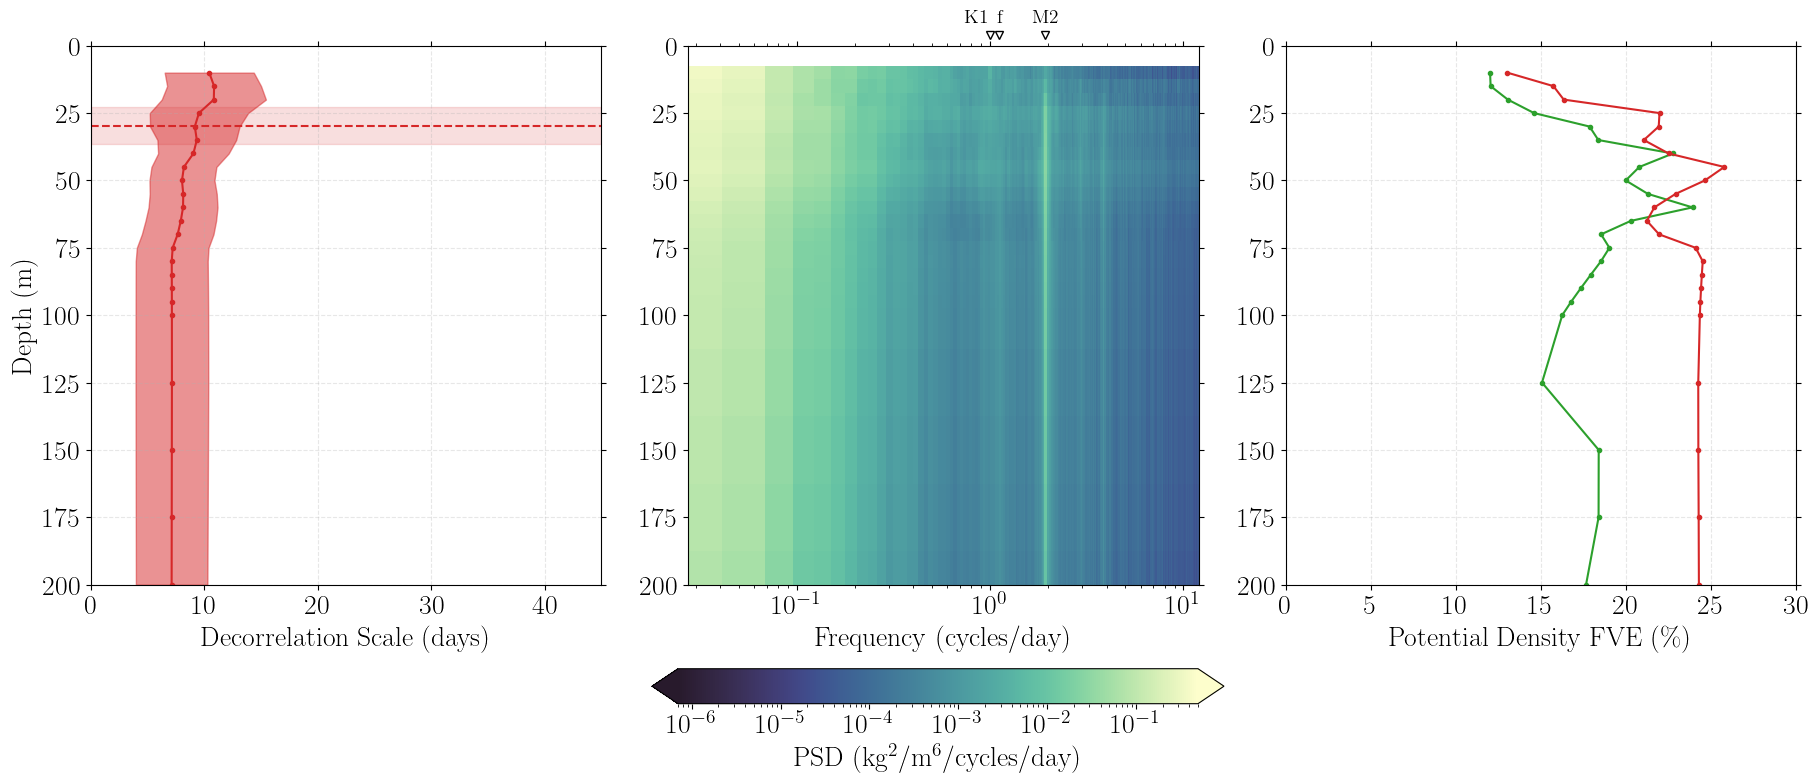

In [96]:
# Set colormap and levels
cmap = cmocean.cm.deep_r

# Define logarithmic normalization
norm = mcolors.LogNorm(vmin=7e-7, vmax=5e-1)

# Set the frequency and depth grid for the model and observations
F, D = np.meshgrid(f_cpd, depth1)
F_vel, D_vel = np.meshgrid(f_cpd_adcp, depth1_adcp)

# Set global fontsize
fontsize = 20
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,3,figsize=(22, 7))
ax1, ax2, ax3 = axes.flatten()

#--- Subplot 1 ---# 

# Plot potential density decor scales
# ax1.plot(Lt1_rho,depth1,'.-', color='tab:green')
ax1.plot(Lt2_rho,depth2,'.-', color='tab:red')

# Plot standard error of the mean
#ax1.fill_betweenx(depth1, Lt1_rho - Lt1_rho_stdm, Lt1_rho + Lt1_rho_stdm, color='tab:green', alpha=0.5)
ax1.fill_betweenx(depth2, Lt2_rho - Lt2_rho_stdm, Lt2_rho + Lt2_rho_stdm, color='tab:red', alpha=0.5)

# Plot the mean mixed layer depth 
#ax1.axhline(mld1_mean, ls='--', lw=1.5, color='tab:green', alpha=1)
ax1.axhline(mld2_mean, ls='--', lw=1.5, color='tab:red', alpha=1)

# Plot the range of mixed layer depths (1 standard deviation)
#ax1.fill_between([0, 45], mld1_mean - mld1_std_mean, mld1_mean + mld1_std_mean, color='tab:green', alpha=0.15)
ax1.fill_between([0, 45], mld2_mean - mld2_std_mean, mld2_mean + mld2_std_mean, color='tab:red', alpha=0.15)

# Set axis attributes
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0,45)
ax1.set_ylim(depth_lim[0], depth_lim[1])
ax1.set_xticks([0, 10, 20, 30, 40])
ax1.invert_yaxis()
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelleft=True,
            direction='out', length=3.5)
ax1.grid(True,linestyle='--',alpha=0.3)

#--- Subplot 2 ---#  

# Plot CCE potential density spectrogram 
#pc = ax2.pcolormesh(F,D,S1_rho,cmap=cmap,shading='auto', norm=norm)
pc = ax2.pcolormesh(F,D,S2_rho,cmap=cmap,shading='auto', norm=norm)

# Set figure attributes
ax2.set_xlabel('Frequency (cycles/day)')
ax2.set_xlim(f_cpd_m[1],f_cpd_m[-1])
ax2.set_ylim(depth_lim[0],depth_lim[1])
ax2.invert_yaxis() 
ax2.set_xscale('log')
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelbottom=True, labeltop=False,
            direction='out', which='both', length=3.5)
ax2.tick_params(which='major', length=3.5)
ax2.tick_params(which='minor', length=2.5)

#--- Subplot 3 ---#  

# Plot Fraction of variance explained by high-frequency variability for each mooring
ax3.plot(FVE_cce1*100,abs(depth1),'.-',color='tab:green',label='CCE 1')
ax3.plot(FVE_cce2*100,abs(depth2),'.-',color='tab:red',label='CCE 2')

# Set figure attributes
ax3.set_xlabel(f'Potential Density FVE (\%)')
ax3.set_xlim(0,30)
ax3.set_ylim(0,200)
ax3.set_yticks(np.arange(0,200+25,25))
ax3.invert_yaxis()
ax3.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax3.grid(True,linestyle='--',alpha=0.3)

# Set color bar
cax = fig.add_axes([0.38, -0.06, 0.26, 0.05]) 
cbar = fig.colorbar(pc, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(r'PSD (kg$^2$/m$^6$/cycles/day)')

# Plot the tidal and inertial frequencies

# K1 label shifted slightly left
add_freq_marker(ax2, f_k1, 'K1', x_text_offset_pts=-10, y_marker=1.02, y_text=1.035,fontsize=14)

# f label shifted slightly right
add_freq_marker(ax2, f1_i, 'f',  x_text_offset_pts=+1, y_marker=1.02, y_text=1.035,fontsize=14)

# M2 centered
add_freq_marker(ax2, f_m2, 'M2', y_marker=1.02, y_text=1.035,fontsize=14)

# Display figure
plt.subplots_adjust(hspace=0.07, wspace=0.17)
plt.show()

Plot the decorrelation scale as a function of duration of record

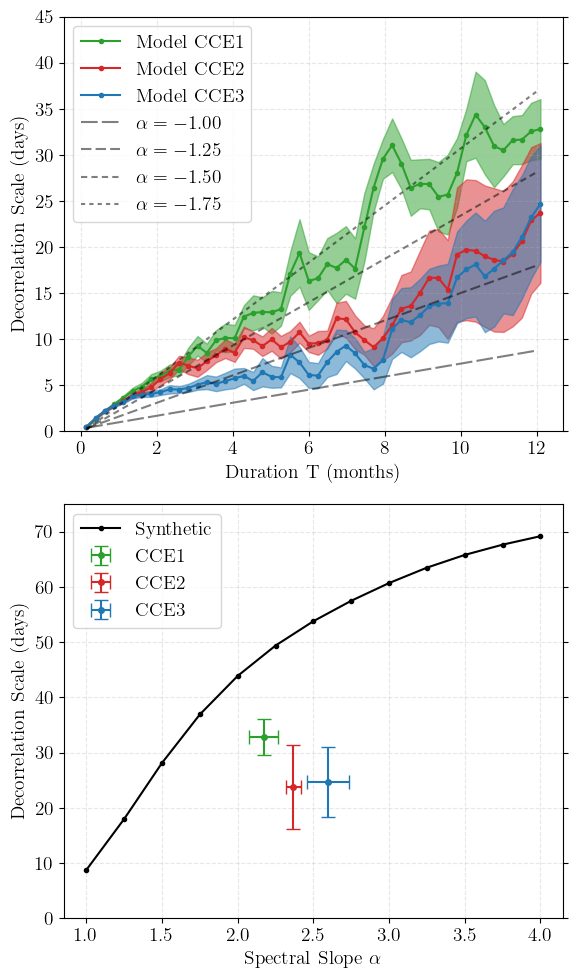

In [13]:
# Set parameters
option_data = 'model'
scale_months = scale/30.44
scale_vel_months = scale_vel/30.44

# Find the scale closest to the 12 months 
duration = 12                            # Units: months
idx_scale_m = np.argmin(abs(scale_m - duration))
idx_scale  = np.argmin(abs(scale_months - duration))
idx_scale_vel  = np.argmin(abs(scale_vel_months - duration))

# Find the depth closest to 10 meters
depth_level = 10
idx_depth_m = np.argmin(abs(depth_upper_m - depth_level))
idx_depth = np.argmin(abs(depth1 - depth_level))
idx_depth_vel = np.argmin(abs(depth1_adcp - depth_level))

# Create figure
fig, axes = plt.subplots(2,1,figsize=(6, 10))
ax_flat = axes.flatten()

##################
#-- Subplot 1 ---#
##################
ax = ax_flat[0]

if option_data == 'model': 

    # Plot potential density decor scales
    ax.plot(scale_m, Lt1_rho_ms,'.-', color='tab:green',label='Model CCE1')
    ax.plot(scale_m, Lt2_rho_ms,'.-', color='tab:red',label='Model CCE2')
    ax.plot(scale_m, Lt3_rho_ms,'.-', color='tab:blue',label='Model CCE3')

    # Plot standard error of the mean
    ax.fill_between(scale_m, Lt1_rho_ms - Lt1_rho_ms_stdm, Lt1_rho_ms + Lt1_rho_ms_stdm, color='tab:green', alpha=0.5)
    ax.fill_between(scale_m, Lt2_rho_ms - Lt2_rho_ms_stdm, Lt2_rho_ms + Lt2_rho_ms_stdm, color='tab:red', alpha=0.5)
    ax.fill_between(scale_m, Lt3_rho_ms - Lt3_rho_ms_stdm, Lt3_rho_ms + Lt3_rho_ms_stdm, color='tab:blue', alpha=0.5)
else: 

    # Plot potential density decor scales
    ax.plot(scale_months, Lt1_rho_s,'.-', color='tab:green',label='CCE1')
    ax.plot(scale_months, Lt2_rho_s,'.-', color='tab:red',label='CCE2')

    # Plot standard error of the mean
    ax.fill_between(scale_months, Lt1_rho_s - Lt1_rho_s_stdm, Lt1_rho_s + Lt1_rho_s_stdm, color='tab:green', alpha=0.5)
    ax.fill_between(scale_months, Lt2_rho_s - Lt2_rho_s_stdm, Lt2_rho_s + Lt2_rho_s_stdm, color='tab:red', alpha=0.5)

# Plot the linear fit to the decorrelation scale vs. window size relation
ax.plot(scale_sim, Lt_fit_sim[0, :], linestyle=(0, (8, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[0]))
ax.plot(scale_sim, Lt_fit_sim[1, :], linestyle=(0, (5, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[1]))
ax.plot(scale_sim, Lt_fit_sim[2, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[2]))
ax.plot(scale_sim, Lt_fit_sim[3, :], linestyle=(0, (2, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[3]))

# Set axis attributes
ax.set_xlabel("Duration T (months)")
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_ylim(0,45)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3) 
ax.legend()

##################
#-- Subplot 2 ---#
##################
ax = ax_flat[1]

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,-1], '.-', color='k', label = 'Synthetic')

if option_data == 'model': 

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(spec_slope_Rho_sub_m[0,idx_depth_m]), Lt1_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[0,idx_depth_m], yerr=Lt1_rho_ms_stdm[idx_scale_m], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
    ax.errorbar(abs(spec_slope_Rho_sub_m[1,idx_depth_m]), Lt2_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[1,idx_depth_m], yerr=Lt2_rho_ms_stdm[idx_scale_m],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
    ax.errorbar(abs(spec_slope_Rho_sub_m[2,idx_depth_m]), Lt3_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[2,idx_depth_m], yerr=Lt3_rho_ms_stdm[idx_scale_m],fmt='o', color='tab:blue', ms=4, capsize=5, label='CCE3')

else: 

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(spec_slope_Rho1_sub[idx_depth]), Lt1_rho_s[idx_scale], xerr=spec_slope_Rho1_sub_stdm[idx_depth], yerr=Lt1_rho_s_stdm[idx_scale], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
    ax.errorbar(abs(spec_slope_Rho2_sub[idx_depth]), Lt2_rho_s[idx_scale], xerr=spec_slope_Rho2_sub_stdm[idx_depth], yerr=Lt2_rho_s_stdm[idx_scale],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
    

# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_ylim(0,75)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)
ax.legend()

# Label each subplot
pos = [0.93, 0.97]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)

# Show figure
plt.tight_layout()
plt.show()

# Save with high quality
if option_data == 'model': 
    figName = 'fig10_proposal.png'
else: 
    figName = 'fig11_proposal.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

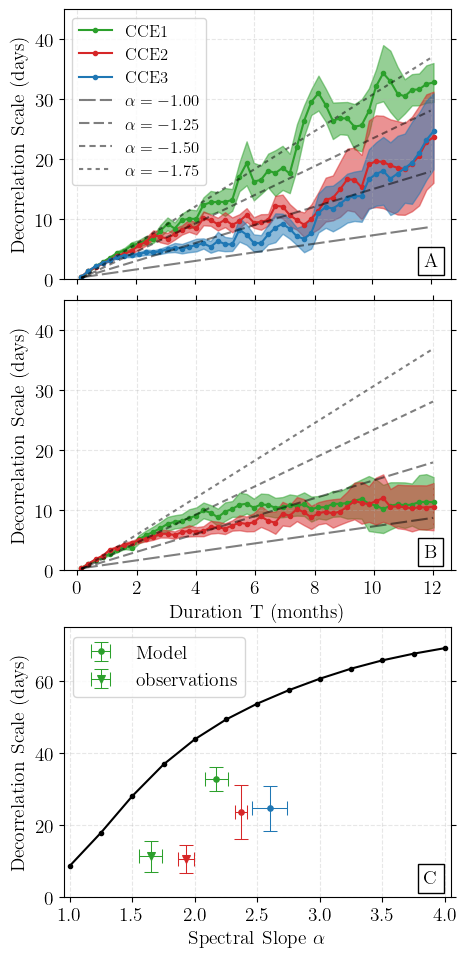

In [14]:
# Set parameters
option_data = 'model'
scale_months = scale/30.44
scale_vel_months = scale_vel/30.44

# Find the scale closest to the 12 months 
duration = 12                            # Units: months
idx_scale_m = np.argmin(abs(scale_m - duration))
idx_scale  = np.argmin(abs(scale_months - duration))
idx_scale_vel  = np.argmin(abs(scale_vel_months - duration))

# Find the depth closest to 10 meters
depth_level = 10
idx_depth_m = np.argmin(abs(depth_upper_m - depth_level))
idx_depth = np.argmin(abs(depth1 - depth_level))
idx_depth_vel = np.argmin(abs(depth1_adcp - depth_level))

# Create figure
fig, axes = plt.subplots(3,1,figsize=(5, 12)) #1,3,figsize=(12, 5)) # 3,1,figsize=(5, 12))
ax_flat = axes.flatten()

##################
#-- Subplot 1 ---#
##################
ax = ax_flat[0]

# Plot potential density decor scales
ax.plot(scale_m, Lt1_rho_ms,'.-', color='tab:green',label='CCE1')
ax.plot(scale_m, Lt2_rho_ms,'.-', color='tab:red',label='CCE2')
ax.plot(scale_m, Lt3_rho_ms,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax.fill_between(scale_m, Lt1_rho_ms - Lt1_rho_ms_stdm, Lt1_rho_ms + Lt1_rho_ms_stdm, color='tab:green', alpha=0.5)
ax.fill_between(scale_m, Lt2_rho_ms - Lt2_rho_ms_stdm, Lt2_rho_ms + Lt2_rho_ms_stdm, color='tab:red', alpha=0.5)
ax.fill_between(scale_m, Lt3_rho_ms - Lt3_rho_ms_stdm, Lt3_rho_ms + Lt3_rho_ms_stdm, color='tab:blue', alpha=0.5)

# Plot the linear fit to the decorrelation scale vs. window size relation
ax.plot(scale_sim, Lt_fit_sim[0, :], linestyle=(0, (8, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[0]))
ax.plot(scale_sim, Lt_fit_sim[1, :], linestyle=(0, (5, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[1]))
ax.plot(scale_sim, Lt_fit_sim[2, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[2]))
ax.plot(scale_sim, Lt_fit_sim[3, :], linestyle=(0, (2, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[3]))

# Set axis attributes
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
#ax.set_xlim(0.95, 12.05)
ax.set_xticklabels([])
ax.set_ylim(0,45)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3) 
ax.legend(fontsize=12)

##################
#-- Subplot 2 ---#
##################
ax = ax_flat[1]

# Plot potential density decor scales
ax.plot(scale_months, Lt1_rho_s,'.-', color='tab:green',label='CCE1')
ax.plot(scale_months, Lt2_rho_s,'.-', color='tab:red',label='CCE2')

# Plot standard error of the mean
ax.fill_between(scale_months, Lt1_rho_s - Lt1_rho_s_stdm, Lt1_rho_s + Lt1_rho_s_stdm, color='tab:green', alpha=0.5)
ax.fill_between(scale_months, Lt2_rho_s - Lt2_rho_s_stdm, Lt2_rho_s + Lt2_rho_s_stdm, color='tab:red', alpha=0.5)

# Plot the linear fit to the decorrelation scale vs. window size relation
ax.plot(scale_sim, Lt_fit_sim[0, :], linestyle=(0, (8, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[0]))
ax.plot(scale_sim, Lt_fit_sim[1, :], linestyle=(0, (5, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[1]))
ax.plot(scale_sim, Lt_fit_sim[2, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[2]))
ax.plot(scale_sim, Lt_fit_sim[3, :], linestyle=(0, (2, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[3]))

# Set axis attributes
ax.set_xlabel("Duration T (months)")
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
#ax.set_xlim(0.95, 12.05)
ax.set_ylim(0,45)
ax.tick_params(top=True, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3) 

##################
#-- Subplot 3 ---#
##################
ax = ax_flat[2]

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,-1], '.-', color='k')

# Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
ax.errorbar(abs(spec_slope_Rho_sub_m[0,idx_depth_m]), Lt1_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[0,idx_depth_m], yerr=Lt1_rho_ms_stdm[idx_scale_m], fmt='o', color='tab:green', ms=4, mew=0.75, elinewidth=0.75, capsize=5, label='Model')
ax.errorbar(abs(spec_slope_Rho_sub_m[1,idx_depth_m]), Lt2_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[1,idx_depth_m], yerr=Lt2_rho_ms_stdm[idx_scale_m],fmt='o', color='tab:red', ms=4, mew=0.75, elinewidth=0.75, capsize=5)
ax.errorbar(abs(spec_slope_Rho_sub_m[2,idx_depth_m]), Lt3_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[2,idx_depth_m], yerr=Lt3_rho_ms_stdm[idx_scale_m],fmt='o', color='tab:blue', ms=4, mew=0.75, elinewidth=0.75, capsize=5)

# Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
ax.errorbar(abs(spec_slope_Rho1_sub[idx_depth]), Lt1_rho_s[idx_scale], xerr=spec_slope_Rho1_sub_stdm[idx_depth], yerr=Lt1_rho_s_stdm[idx_scale], fmt='v', color='tab:green', ms=6, mew=0.75, elinewidth=0.75, capsize=5, label='observations')
ax.errorbar(abs(spec_slope_Rho2_sub[idx_depth]), Lt2_rho_s[idx_scale], xerr=spec_slope_Rho2_sub_stdm[idx_depth], yerr=Lt2_rho_s_stdm[idx_scale], fmt='v', color='tab:red', ms=6, mew=0.75, elinewidth=0.75, capsize=5)
    
# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xlim(0.95, 4.05)
ax.set_ylim(0,75)
ax.set_xticks(np.arange(1,4+0.5,0.5))
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)
ax.legend()

# Label each subplot
ax1, ax2, ax3 = axes.flatten()
pos = [0.93, 0.1]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)

# Adjust spacing between figure
plt.subplots_adjust(hspace=0.21, wspace=0.1)

# Now move only panel A down slightly to reduce A–B gap
posA = ax_flat[0].get_position()          # [x0, y0, width, height]
shift = 0.03                              # tweak this value as needed
ax_flat[0].set_position([posA.x0,
                         posA.y0 - shift, # move A downward
                         posA.width,
                         posA.height])

# Show figure
plt.show()

# Save with high quality
figName = 'fig12_proposal.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

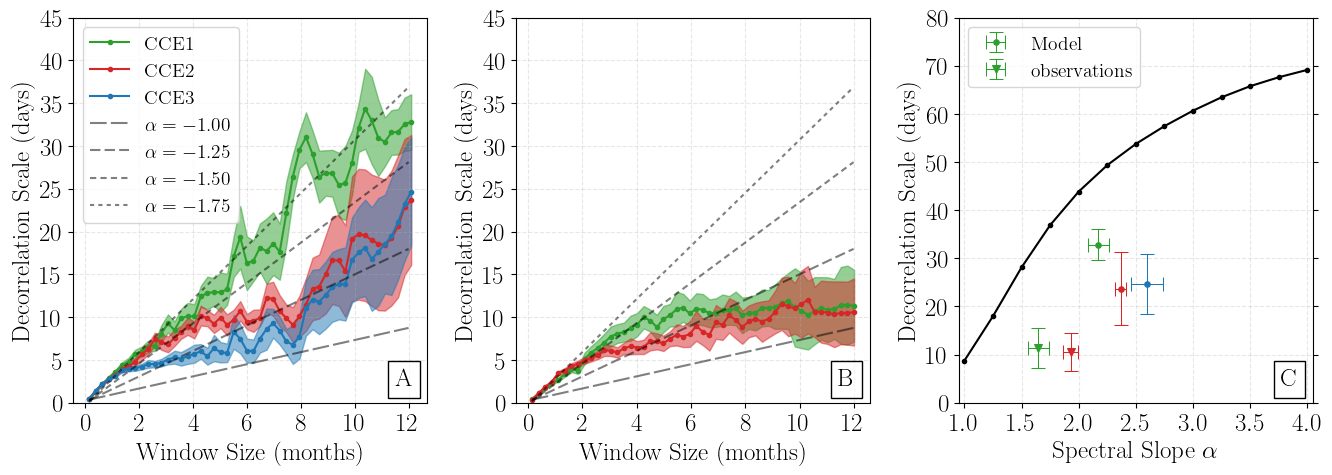

In [57]:
# Set parameters
option_data = 'model'
scale_months = scale/30.44
scale_vel_months = scale_vel/30.44

# Find the scale closest to the 12 months 
duration = 12                            # Units: months
idx_scale_m = np.argmin(abs(scale_m - duration))
idx_scale  = np.argmin(abs(scale_months - duration))
idx_scale_vel  = np.argmin(abs(scale_vel_months - duration))

# Find the depth closest to 10 meters
depth_level = 10
idx_depth_m = np.argmin(abs(depth_upper_m - depth_level))
idx_depth = np.argmin(abs(depth1 - depth_level))
idx_depth_vel = np.argmin(abs(depth1_adcp - depth_level))

# Set global fontsize
fontsize = 18
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
}) 

# Create figure
fig, axes = plt.subplots(1,3,figsize=(16, 5))
ax_flat = axes.flatten()

##################
#-- Subplot 1 ---#
##################
ax = ax_flat[0]

# Plot potential density decor scales
ax.plot(scale_m, Lt1_rho_ms,'.-', color='tab:green',label='CCE1')
ax.plot(scale_m, Lt2_rho_ms,'.-', color='tab:red',label='CCE2')
ax.plot(scale_m, Lt3_rho_ms,'.-', color='tab:blue',label='CCE3')

# Plot standard error of the mean
ax.fill_between(scale_m, Lt1_rho_ms - Lt1_rho_ms_stdm, Lt1_rho_ms + Lt1_rho_ms_stdm, color='tab:green', alpha=0.5)
ax.fill_between(scale_m, Lt2_rho_ms - Lt2_rho_ms_stdm, Lt2_rho_ms + Lt2_rho_ms_stdm, color='tab:red', alpha=0.5)
ax.fill_between(scale_m, Lt3_rho_ms - Lt3_rho_ms_stdm, Lt3_rho_ms + Lt3_rho_ms_stdm, color='tab:blue', alpha=0.5)

# Plot the linear fit to the decorrelation scale vs. window size relation
ax.plot(scale_sim, Lt_fit_sim[0, :], linestyle=(0, (8, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[0]))
ax.plot(scale_sim, Lt_fit_sim[1, :], linestyle=(0, (5, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[1]))
ax.plot(scale_sim, Lt_fit_sim[2, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[2]))
ax.plot(scale_sim, Lt_fit_sim[3, :], linestyle=(0, (2, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[3]))

# Set axis attributes
ax.set_xlabel("Window Size (months)")
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_yticks(np.arange(0,45+5,5))
ax.set_ylim(0,45)
ax.tick_params(top=False, bottom=True, left=True, right=False,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3) 
ax.legend(fontsize=14)

##################
#-- Subplot 2 ---#
##################
ax = ax_flat[1]

# Plot potential density decor scales
ax.plot(scale_months, Lt1_rho_s,'.-', color='tab:green',label='CCE1')
ax.plot(scale_months, Lt2_rho_s,'.-', color='tab:red',label='CCE2')

# Plot standard error of the mean
ax.fill_between(scale_months, Lt1_rho_s - Lt1_rho_s_stdm, Lt1_rho_s + Lt1_rho_s_stdm, color='tab:green', alpha=0.5)
ax.fill_between(scale_months, Lt2_rho_s - Lt2_rho_s_stdm, Lt2_rho_s + Lt2_rho_s_stdm, color='tab:red', alpha=0.5)

# Plot the linear fit to the decorrelation scale vs. window size relation
ax.plot(scale_sim, Lt_fit_sim[0, :], linestyle=(0, (8, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[0]))
ax.plot(scale_sim, Lt_fit_sim[1, :], linestyle=(0, (5, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[1]))
ax.plot(scale_sim, Lt_fit_sim[2, :], linestyle=(0, (3, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[2]))
ax.plot(scale_sim, Lt_fit_sim[3, :], linestyle=(0, (2, 2)), color='k', alpha=0.5,
        linewidth=1.5, label=r'$\alpha = -${:.2f}'.format(alpha_sim[3]))

# Set axis attributes
ax.set_xlabel("Window Size (months)")
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks([0, 2, 4, 6, 8, 10, 12])
ax.set_yticks(np.arange(0,45+5,5))
#ax.set_xlim(0.95, 12.05)
ax.set_ylim(0,45)
ax.tick_params(top=False, bottom=True, left=True, right=False,
            direction='out', length=3.5)
ax.grid(True,linestyle='--',alpha=0.3) 

##################
#-- Subplot 3 ---#
##################
ax = ax_flat[2]

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,-1], '.-', color='k')

# Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
ax.errorbar(abs(spec_slope_Rho_sub_m[0,idx_depth_m]), Lt1_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[0,idx_depth_m], yerr=Lt1_rho_ms_stdm[idx_scale_m], fmt='o', color='tab:green', ms=4, mew=0.75, elinewidth=0.75, capsize=5, label='Model')
ax.errorbar(abs(spec_slope_Rho_sub_m[1,idx_depth_m]), Lt2_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[1,idx_depth_m], yerr=Lt2_rho_ms_stdm[idx_scale_m],fmt='o', color='tab:red', ms=4, mew=0.75, elinewidth=0.75, capsize=5)
ax.errorbar(abs(spec_slope_Rho_sub_m[2,idx_depth_m]), Lt3_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[2,idx_depth_m], yerr=Lt3_rho_ms_stdm[idx_scale_m],fmt='o', color='tab:blue', ms=4, mew=0.75, elinewidth=0.75, capsize=5)

# Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
ax.errorbar(abs(spec_slope_Rho1_sub[idx_depth]), Lt1_rho_s[idx_scale], xerr=spec_slope_Rho1_sub_stdm[idx_depth], yerr=Lt1_rho_s_stdm[idx_scale], fmt='v', color='tab:green', ms=6, mew=0.75, elinewidth=0.75, capsize=5, label='observations')
ax.errorbar(abs(spec_slope_Rho2_sub[idx_depth]), Lt2_rho_s[idx_scale], xerr=spec_slope_Rho2_sub_stdm[idx_depth], yerr=Lt2_rho_s_stdm[idx_scale], fmt='v', color='tab:red', ms=6, mew=0.75, elinewidth=0.75, capsize=5)
    
# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xlim(0.95, 4.05)
ax.set_ylim(0,75)
ax.set_xticks(np.arange(1,4+0.5,0.5))
ax.set_yticks(np.arange(0,75+10,10))
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)
ax.legend(fontsize=14)

# Label each subplot
ax1, ax2, ax3 = axes.flatten()
pos = [0.91, 0.09]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)

# Adjust spacing between figure
plt.subplots_adjust(hspace=0.21, wspace=0.25)

# Show figure
plt.show()

# Save with high quality
figName = 'fig12_proposal.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Plot the decorrelation scale as a function of spectral slope and compare the spectral slope estimate

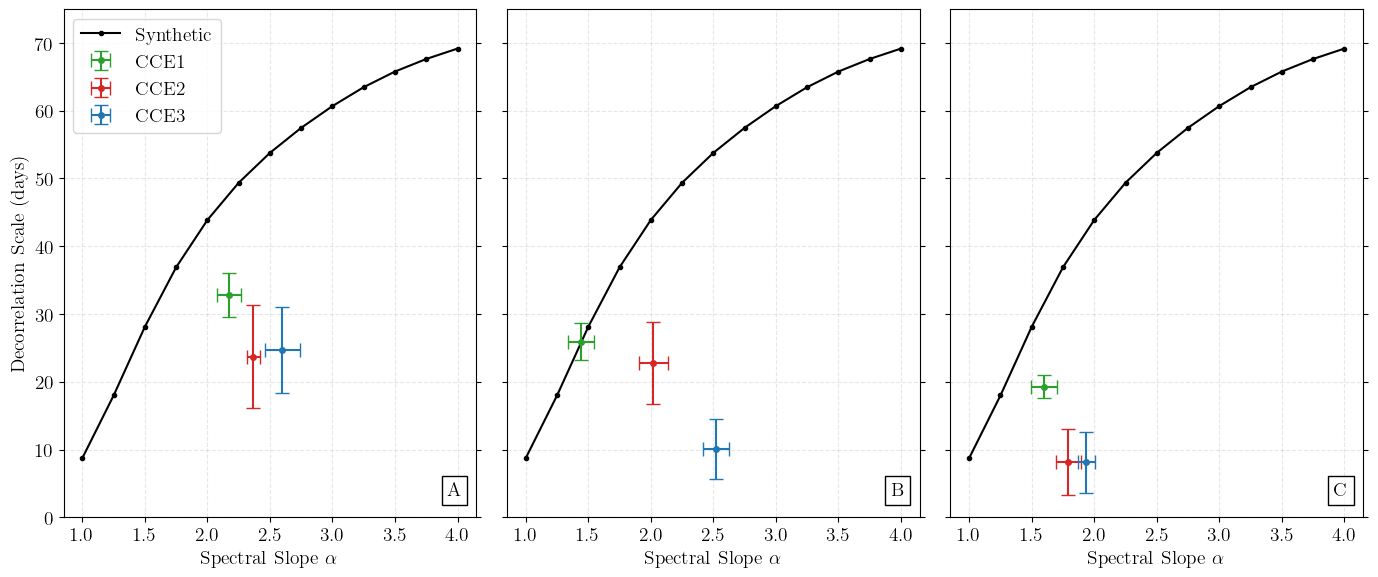

In [ ]:
# Set parameters
option_data = 'model'

# Find the scale closest to the 12 months 
duration = 12                            # Units: months
idx_scale_m = np.argmin(abs(scale_m - duration))
idx_scale  = np.argmin(abs(scale_months - duration))
idx_scale_vel  = np.argmin(abs(scale_vel_months - duration))

# Find the depth closest to 10 meters
depth_level = 10
idx_depth_m = np.argmin(abs(depth_upper_m - depth_level))
idx_depth = np.argmin(abs(depth1 - depth_level))
idx_depth_vel = np.argmin(abs(depth1_adcp - depth_level))

# Create figure and axes
fig, axes = plt.subplots(1,3,figsize=(14, 6))
ax_flat = axes.flatten()

##################
#-- Subplot 1 ---#
##################
ax = ax_flat[0]

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,-1], '.-', color='k', label = 'Synthetic')

if option_data == 'model': 

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(spec_slope_Rho_sub_m[0,idx_depth_m]), Lt1_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[0,idx_depth_m], yerr=Lt1_rho_ms_stdm[idx_scale_m], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
    ax.errorbar(abs(spec_slope_Rho_sub_m[1,idx_depth_m]), Lt2_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[1,idx_depth_m], yerr=Lt2_rho_ms_stdm[idx_scale_m],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
    ax.errorbar(abs(spec_slope_Rho_sub_m[2,idx_depth_m]), Lt3_rho_ms[idx_scale_m], xerr=spec_slope_Rho_sub_stdm_m[2,idx_depth_m], yerr=Lt3_rho_ms_stdm[idx_scale_m],fmt='o', color='tab:blue', ms=4, capsize=5, label='CCE3')

else: 

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(spec_slope_Rho1_sub[idx_depth]), Lt1_rho_s[idx_scale], xerr=spec_slope_Rho1_sub_stdm[idx_depth], yerr=Lt1_rho_s_stdm[idx_scale], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
    ax.errorbar(abs(spec_slope_Rho2_sub[idx_depth]), Lt2_rho_s[idx_scale], xerr=spec_slope_Rho2_sub_stdm[idx_depth], yerr=Lt2_rho_s_stdm[idx_scale],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
    

# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_ylim(0,75)
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)
ax.legend()

##################
#-- Subplot 2 ---#
##################
ax = ax_flat[1]

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,-1], '.-', color='k')

if option_data == 'model': 

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(spec_slope_U_sub_m[0,6]), Lt1_u_ms[-1], xerr=spec_slope_U_sub_stdm_m[0,6], yerr=Lt1_u_ms_stdm[-1], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
    ax.errorbar(abs(spec_slope_U_sub_m[1,6]), Lt2_u_ms[-1], xerr=spec_slope_U_sub_stdm_m[1,6], yerr=Lt2_u_ms_stdm[-1], fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
    ax.errorbar(abs(spec_slope_U_sub_m[2,6]), Lt3_u_ms[-1], xerr=spec_slope_U_sub_stdm_m[2,6], yerr=Lt3_u_ms_stdm[-1], fmt='o', color='tab:blue', ms=4, capsize=5, label='CCE3')

else: 

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(spec_slope_U1_sub[idx_depth]), Lt1_u_s[idx_scale], xerr=spec_slope_U1_sub_stdm[idx_depth], yerr=Lt1_u_s_stdm[idx_scale], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
    ax.errorbar(abs(spec_slope_U2_sub[idx_depth]), Lt2_u_s[idx_scale], xerr=spec_slope_U2_sub_stdm[idx_depth], yerr=Lt2_u_s_stdm[idx_scale],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
    
# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylim(0,75)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)

##################
#-- Subplot 3 ---#
##################
ax = ax_flat[2]

# Plot the decorrelation scale as a function of spectral slope for a 12 month duration 
ax.plot(alpha_sim, Lt_fit_sim[:,-1], '.-', color='k')

if option_data == 'model': 

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(spec_slope_V_sub_m[0,6]), Lt1_v_ms[-1], xerr=spec_slope_V_sub_stdm_m[0,6], yerr=Lt1_v_ms_stdm[-1], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
    ax.errorbar(abs(spec_slope_V_sub_m[1,6]), Lt2_v_ms[-1], xerr=spec_slope_V_sub_stdm_m[1,6], yerr=Lt2_v_ms_stdm[-1], fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')
    ax.errorbar(abs(spec_slope_V_sub_m[2,6]), Lt3_v_ms[-1], xerr=spec_slope_V_sub_stdm_m[2,6], yerr=Lt3_v_ms_stdm[-1], fmt='o', color='tab:blue', ms=4, capsize=5, label='CCE3')

else: 

    # Plot the decorrelation scale at the 12 month duration and its corresponding spectral slope
    ax.errorbar(abs(spec_slope_V1_sub[idx_depth]), Lt1_v_s[idx_scale], xerr=spec_slope_V1_sub_stdm[idx_depth], yerr=Lt1_v_s_stdm[idx_scale], fmt='o', color='tab:green', ms=4, capsize=5, label='CCE1')
    ax.errorbar(abs(spec_slope_V2_sub[idx_depth]), Lt2_v_s[idx_scale], xerr=spec_slope_V2_sub_stdm[idx_depth], yerr=Lt2_v_s_stdm[idx_scale],fmt='o', color='tab:red', ms=4, capsize=5, label='CCE2')

# Set axis attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylim(0,75)
ax.set_yticklabels([])
ax.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax.grid(True, ls='--', alpha=0.3)

# Label each subplot
pos = [0.93, 0.07]
ax1, ax2, ax3 = axes.flatten()
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)

# Show figure
plt.tight_layout()
plt.show()

# Save with high quality
if option_data == 'model': 
    figName = 'fig12.png'
else: 
    figName = 'fig13.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)